## Overlap between Vulnerability Disclosure Programs and CrUX

In [ ]:
import os
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))


[('programs',), ('reports',), ('users',), ('scopes',), ('bounties',), ('rules',), ('vulnerabilityTypes',), ('backups',)]
[('programs',), ('scopes',)]
[('programs',), ('scopes',)]
[('programs',), ('scopes',)]
Comparison with BBData:
 - OurData URLs: 8512
 - BBData URLs: 34478
 - Matching URLs: 7510 (88.23% overlap)

Comparison with PDData:
 - OurData URLs: 8512
 - PDData URLs: 4116
 - Matching URLs: 898 (10.55% overlap)

Comparison with FBData:
 - OurData URLs: 8512
 - FBData URLs: 4912
 - Matching URLs: 2177 (25.58% overlap)



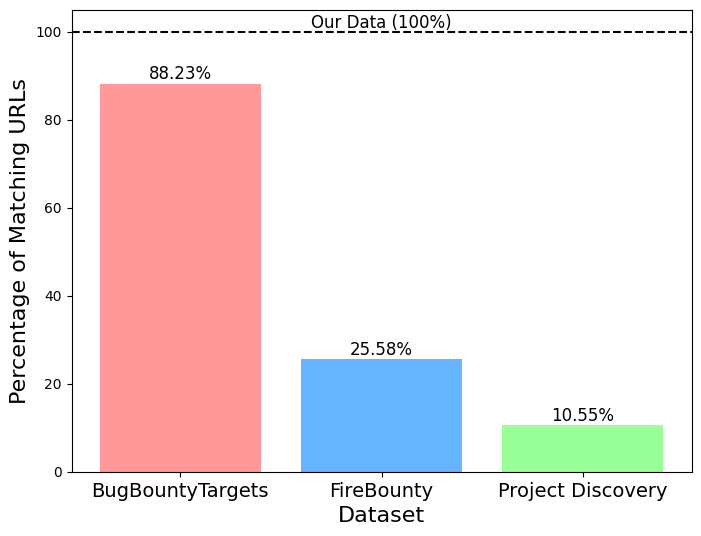

In [ ]:
import re 
from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import tldextract

# Set project root directory dynamically
project_root = os.path.abspath("..")  # Adjust path if needed
if project_root not in sys.path:
    sys.path.append(project_root)

def check_tables(database_path):
    engine = create_engine(f"sqlite:///{database_path}")
    Session = sessionmaker(bind=engine)
    session = Session()
    # Create a connection to the database
    query = "SELECT name FROM sqlite_master WHERE type='table'"
    result = session.execute(query)
    print(result.fetchall())
    session.close()


def extractBBUrls():
        # Query the database
        engine = create_engine(f'{BASE_DIR}/data/BugBountyData.sqlite')
        Session = sessionmaker(bind=engine)
        session = Session()
        query = "SELECT * FROM scopes WHERE inScope='1'"
        # Execute the query and fetch results
        result = session.execute(query)
        df = pd.DataFrame(result.fetchall(), columns=result.keys())
        session.close()

        filtered_urls = []
        for _ , row in df.iterrows():
            filtered_urls.extend(filterUrls(row))
            
        # Print the valid URLs
        return filtered_urls

def extractFBUrls():
    # Query the database
    engine = create_engine(f'{BASE_DIR}/data/FireBountyData.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractPDUrls():
    # Query the database

    engine = create_engine(f'{BASE_DIR}/data/ProjectDiscoveryData.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractBBTUrls():
    # Query the database

    engine = create_engine(f'{BASE_DIR}/data/BugBountyTargets.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def filterUrls(row):
        filtered_urls = []

        try:
            # Regular expression to match URLs 
            url_pattern = re.compile(
                r'(?i)\b(?:https?://|http://|www\.|\*\.)?'  # Matches http, https, www, or *.
                r'(?:[a-z0-9-]+\.)*\*?'                    # Matches subdomains and optional wildcard (*).
                r'[a-z0-9-]+'                              # Matches the main domain.
                r'(\.\*|(?:\.[a-z0-9-]+)+)'                # Matches TLDs like .com, .*, or wildcards in middle segments like shop.*.be.
                r'(:\d+)?'                                 # Matches optional port numbers.
                r'(/.*)?'                                  # Matches paths, including wildcards like /*.
            )

            valid_urls = []
            scope_entry = row.scope
            # Find all URLs in the entry
            urls = [match.group() for match in url_pattern.finditer(scope_entry)]
            valid_urls.extend(urls)

            # Add filtering for apps and github: 
            for url in valid_urls:
                if "github.com" in url:
                    continue

                if "play.google.com/store/" in url:
                    continue
                
                if "apps.apple.com/" in url:
                    continue

                if "marketplace.atlassian" in url:
                    continue

                # check for schemes
                crafted_url = url
                if not "http://" in url and not "https://" in url:
                    crafted_url = "http://" + url

                # check for wildcards
                if "*." in crafted_url:
                    filtered_urls.append([crafted_url, row.programHandle])
                    crafted_url = crafted_url.replace("*.", "").strip()
                        
                filtered_urls.append([crafted_url, row.programHandle])
            
            return filtered_urls
        
        except Exception as e:
            print(f"[!] Exception during filtering/extracting URLs of colleted entries: {e}")
            return filtered_urls


check_tables(f'{BASE_DIR}/data/BugBountyData.sqlite')
check_tables(f'{BASE_DIR}/data/BugBountyTargets.sqlite')
check_tables(f'{BASE_DIR}/data/ProjectDiscoveryData.sqlite')
check_tables(f'{BASE_DIR}/data/FireBountyData.sqlite')

OurData = extractBBUrls()
BBData = extractBBTUrls()
PDData = extractPDUrls()
FBData = extractFBUrls()


def normalize(url):
    url = url.replace("https://", "")
    url = url.replace("http://", "")
    url = url.replace("www.", "")

    extracted = tldextract.extract(url)
    return f"{extracted.subdomain}{extracted.domain}.{extracted.suffix}"
    

def compare_urls(our_data, other_data, other_name):
    # Convert to set for fast lookup
    our_urls = set([normalize(x[0]) for x in our_data])
    other_urls = set([normalize(x[0]) for x in other_data])


    # Find intersections
    common_urls = our_urls.intersection(other_urls)

    # Print results
    print(f"Comparison with {other_name}:")
    print(f" - OurData URLs: {len(our_urls)}")
    print(f" - {other_name} URLs: {len(other_urls)}")
    print(f" - Matching URLs: {len(common_urls)} ({len(common_urls) / len(our_urls) * 100:.2f}% overlap)\n")

    '''
    labels = ["Contained in Our and Their Dataset", "URLs only in our Dataset"]
    colors = ["#ff9999", "#66b3ff"]
    unique_urls = len(our_urls) - len(common_urls) 
    sizes = [len(common_urls), unique_urls]    
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
    plt.title("URL Overlap Analysis")
    plt.show()
    '''

    return len(common_urls), len(our_urls), len(other_urls)

# Perform comparisons

# BBTarget collects from all Source we have + More
res = compare_urls(OurData, BBData, "BBData")
first_bar = res[0] / res[1] * 100

# PD  - Does not list the sources
res = compare_urls(OurData, PDData, "PDData")
sec_bar = res[0] / res[1] * 100

# FB  - Does not list the sources
res = compare_urls(OurData, FBData, "FBData")
third_bar = res[0] / res[1] * 100

labels = ["BugBountyTargets", "FireBounty", "Project Discovery"]
sizes = [first_bar, third_bar, sec_bar]
colors = ["#ff9999", "#66b3ff"]
plt.figure(figsize=(8,6))
bars = plt.bar(labels, sizes, color=["#ff9999", "#66b3ff", "#99ff99"])

# Add percentages on top of bars
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f"{size:.2f}%", ha='center', fontsize=12)

plt.bar(labels, sizes, color=["#ff9999", "#66b3ff", "#99ff99"])
plt.axhline(y=100, color="black", linestyle="dashed", linewidth=1.5)
plt.text(1, 101, "Our Data (100%)", ha="center", fontsize=12)
plt.xlabel("Dataset", fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel("Percentage of Matching URLs", fontsize=16)
#plt.title("Comparison of URL Overlaps with our Collected Data")
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/other_datasets_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

VDP - Anzahl eindeutiger Domains + Suffix: 4669
VDP - Anzahl eindeutiger Domains: 3738
-----------
Based on domain+suffix, 137 URLs of the Crux list (TOP 1000) have a potential disclosure program!
---> Equals 13.700000000000001%
Based on domain, 177 URLs of the Crux list (TOP 1000) have a potential disclosure program!
---> Equals 17.7%
-----------
Based on domain+suffix, 528 URLs of the Crux list (TOP 10000) have a potential disclosure program!
---> Equals 5.28%
Based on domain, 744 URLs of the Crux list (TOP 10000) have a potential disclosure program!
---> Equals 7.4399999999999995%
-----------
Based on domain+suffix, 1349 URLs of the Crux list (TOP 50000) have a potential disclosure program!
---> Equals 2.698%
Based on domain, 2031 URLs of the Crux list (TOP 50000) have a potential disclosure program!
---> Equals 4.062%
-----------
Based on domain+suffix, 2068 URLs of the Crux list (TOP 100000) have a potential disclosure program!
---> Equals 2.068%
Based on domain, 3266 URLs of the 

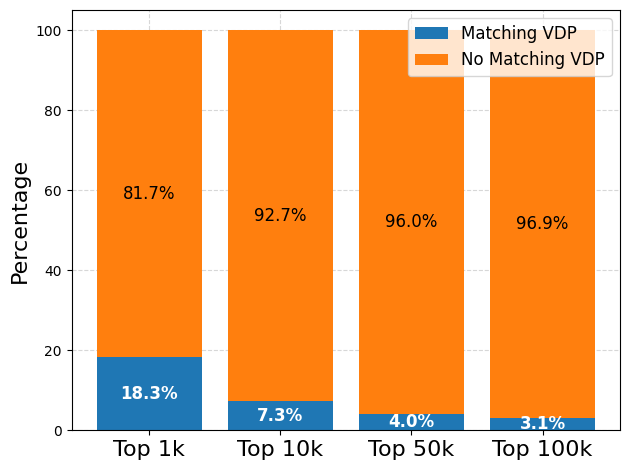

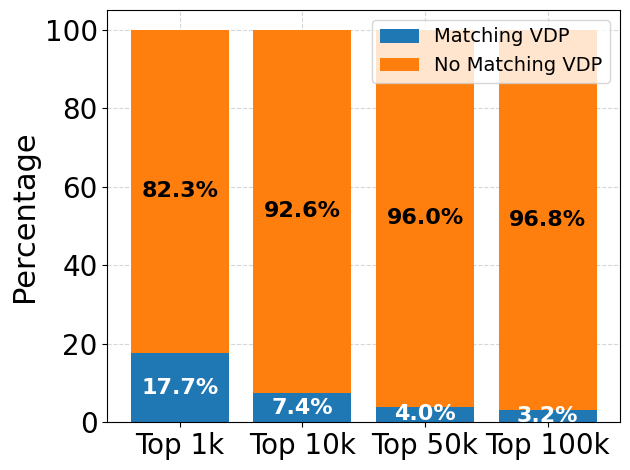

In [ ]:
import re 
from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import tldextract

# Set project root directory dynamically
project_root = os.path.abspath("..")  # Adjust path if needed
if project_root not in sys.path:
    sys.path.append(project_root)

def check_tables(database_path):
    engine = create_engine(f"sqlite:///{database_path}")
    Session = sessionmaker(bind=engine)
    session = Session()
    # Create a connection to the database
    query = "SELECT name FROM sqlite_master WHERE type='table'"
    result = session.execute(query)
    print(result.fetchall())
    session.close()


def extractBBUrls():
        # Query the database
        engine = create_engine(f'sqlite:////{BASE_DIR}/data/BugBountyData.sqlite')
        Session = sessionmaker(bind=engine)
        session = Session()
        query = "SELECT * FROM scopes WHERE inScope='1'"
        # Execute the query and fetch results
        result = session.execute(query)
        df = pd.DataFrame(result.fetchall(), columns=result.keys())
        session.close()

        filtered_urls = []
        for _ , row in df.iterrows():
            filtered_urls.extend(filterUrls(row))
            
        # Print the valid URLs
        return filtered_urls

def extractFBUrls():
    # Query the database
    engine = create_engine(f'sqlite:////{BASE_DIR}/data/FireBountyData.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractPDUrls():
    # Query the database

    engine = create_engine(f'sqlite:////{BASE_DIR}/BugBountyTargets.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractBBTUrls():
    # Query the database

    engine = create_engine(f'sqlite:////{BASE_DIR}/BugBountyTargets.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def filterUrls(row):
        filtered_urls = []

        try:
            # Regular expression to match URLs 
            url_pattern = re.compile(
                r'(?i)\b(?:https?://|http://|www\.|\*\.)?'  # Matches http, https, www, or *.
                r'(?:[a-z0-9-]+\.)*\*?'                    # Matches subdomains and optional wildcard (*).
                r'[a-z0-9-]+'                              # Matches the main domain.
                r'(\.\*|(?:\.[a-z0-9-]+)+)'                # Matches TLDs like .com, .*, or wildcards in middle segments like shop.*.be.
                r'(:\d+)?'                                 # Matches optional port numbers.
                r'(/.*)?'                                  # Matches paths, including wildcards like /*.
            )

            valid_urls = []
            scope_entry = row.scope
            # Find all URLs in the entry
            urls = [match.group() for match in url_pattern.finditer(scope_entry)]
            valid_urls.extend(urls)

            # Add filtering for apps and github: 
            for url in valid_urls:
                if "github.com" in url:
                    continue

                if "play.google.com/store/" in url:
                    continue
                
                if "apps.apple.com/" in url:
                    continue

                if "marketplace.atlassian" in url:
                    continue

                # check for schemes
                crafted_url = url
                if not "http://" in url and not "https://" in url:
                    crafted_url = "http://" + url

                # check for wildcards
                if "*." in crafted_url:
                    filtered_urls.append([crafted_url, row.programHandle])
                    crafted_url = crafted_url.replace("*.", "").strip()
                        
                filtered_urls.append([crafted_url, row.programHandle])
            
            return filtered_urls
        
        except Exception as e:
            print(f"[!] Exception during filtering/extracting URLs of colleted entries: {e}")
            return filtered_urls

OurData = extractBBUrls()
BBData = extractBBTUrls()
PDData = extractPDUrls()
FBData = extractFBUrls()

def get_domain_suffix(url):
    try:
        ext = tldextract.extract(url)
        return f"{ext.domain}.{ext.suffix}"
    except Exception as e:
        print(f"Fehler bei der Verarbeitung der URL '{url}': {e}")
        return None
    
def get_domain(url):
    try:
        ext = tldextract.extract(url)
        return f"{ext.domain}"
    except Exception as e:
        # Behandle mögliche Fehler, z.B. wenn die URL ungültig ist
        print(f"Fehler bei der Verarbeitung der URL '{url}': {e}")
        return None


def check_matches(domain_list, domain_suffix_list, rank):
    csv_file_path = "/home/Redacted_author/MasterThesis/code/data/crux-20501.csv"
    crux_df = pd.read_csv(csv_file_path)
    crux_df = crux_df[crux_df['rank'] <= rank]

    # ---------- MATCHING BASED OF DOMAIN + SUFFIX
    i = 0
    for _, row in crux_df.iterrows():
        domain_suffix = get_domain_suffix(row['origin'])
        if domain_suffix in domain_suffix_list:
            i = i + 1

    print(f'Based on domain+suffix, {i} URLs of the Crux list (TOP {rank}) have a potential disclosure program!')
    print(f'---> Equals {(i/rank) * 100}%')

    # ---------- MATCHING BASED ON DOMAIN ONLY
    i = 0
    for _, row in crux_df.iterrows():
        domain = get_domain(row['origin'])
        if domain in domain_list:
            i = i + 1

    print(f'Based on domain, {i} URLs of the Crux list (TOP {rank}) have a potential disclosure program!')
    print(f'---> Equals {(i/rank) * 100}%')



# All kind of Vulnerabilty Disclosure Programs 
OurData = extractBBUrls()
BBData = extractBBTUrls()
PDData = extractPDUrls()
FBData = extractFBUrls()
all_data = OurData 
unique_domain_suffix = set(get_domain_suffix(website) for website, _ in all_data)
print(f"VDP - Anzahl eindeutiger Domains + Suffix: {len(unique_domain_suffix)}")
unique_domains = set(get_domain(website) for website, _ in all_data)
print(f"VDP - Anzahl eindeutiger Domains: {len(unique_domains)}")


print("-----------")
check_matches(unique_domains, unique_domain_suffix, 1000)
print("-----------")
check_matches(unique_domains, unique_domain_suffix, 10000)
print("-----------")
check_matches(unique_domains, unique_domain_suffix, 50000)
print("-----------")
check_matches(unique_domains, unique_domain_suffix, 100000)
print("-----------")

import matplotlib.pyplot as plt

# -----------BASED ON DOMAIN + SUFFIX --------------

labels = ['Top 1k', 'Top 10k', 'Top 50k', 'Top 100k']
with_program = [18.3, 7.31, 3.98, 3.09]     # Based on domain + suffix
without_program = [100 - val for val in with_program]
x = range(len(labels))
fig, ax = plt.subplots()

bar1 = ax.bar(x, with_program, label='Matching VDP', color='tab:blue', zorder=2)
bar2 = ax.bar(x, without_program, bottom=with_program, label='No Matching VDP', color='tab:orange', zorder=2)

ax.set_ylabel('Percentage', fontsize=16)
#ax.set_title('Matches Domain+Suffix Based')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=12)

for i in range(len(labels)):
    ax.text(i, with_program[i]/2, f"{with_program[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    ax.text(i, with_program[i] + without_program[i]/2, f"{without_program[i]:.1f}%", ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/crux_vdp_match_domain_suffix.pdf', format='pdf', bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.show()


# ------- BASED ON DOMAINS ------

labels = ['Top 1k', 'Top 10k', 'Top 50k', 'Top 100k']
with_program = [23.2, 10.36, 6.12, 4.992]     # Based on domain
with_program = [17.7, 7.44, 4.01, 3.23]     # Based on domain
without_program = [100 - val for val in with_program]
x = range(len(labels))
fig, ax = plt.subplots()

bar1 = ax.bar(x, with_program, label='Matching VDP', color='tab:blue', zorder=2)
bar2 = ax.bar(x, without_program, bottom=with_program, label='No Matching VDP', color='tab:orange', zorder=2)

ax.set_ylabel('Percentage', fontsize=22)
#ax.set_title('Matches Domain Based')
ax.set_xticks(x)
ax.tick_params(axis='y', labelsize=20)
ax.set_xticklabels(labels, fontsize=20)
ax.legend(fontsize=14)

for i in range(len(labels)):
    ax.text(i, with_program[i]/2, f"{with_program[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=16)
    ax.text(i, with_program[i] + without_program[i]/2, f"{without_program[i]:.1f}%", ha='center', va='center', color='black', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/crux_vdp_match_domain.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Results - Overview of Collected Dataset

## Results - Vulnerability Extraction

In [ ]:
import pandas as pd
import tldextract
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import statistics
import openai
import numpy as np
import concurrent
import random
import re
import time
from collections import Counter, defaultdict


# Only based on extracted by LLM:
file_path = f'{BASE_DIR}/data/extractor/vulnTypes.json'
with open(file_path, "r") as file:
    vuln_json = json.load(file)

print("BASED ON RAW EXTRACTED NOT NORMALIZED:")
inscope_counter = Counter()
oos_counter = Counter()
processed_keys = 0 
for key, data in vuln_json.items():
    processed_keys =+ 1
    for vuln_type in data['inScope']:
        if isinstance(vuln_type, dict):
            if "type" in vuln_type.keys():
                inscope_counter[vuln_type['type'].lower()] += 1
            elif "vulnerability" in vuln_type.keys():
                inscope_counter[vuln_type['vulnerability'].lower()] += 1
            elif "name" in vuln_type.keys():
                inscope_counter[vuln_type['name'].lower()] += 1
            else:
                inscope_counter[list(vuln_type.keys())[0].lower()] += 1
                #print(vuln_type)
        else:
            inscope_counter[vuln_type.lower()] += 1

    for vuln_type in data['outOfScope']:
        if isinstance(vuln_type, dict):
            if "type" in vuln_type.keys():
                oos_counter[vuln_type['type'].lower()] += 1
            elif "vulnerability" in vuln_type.keys():
                oos_counter[vuln_type['vulnerability'].lower()] += 1
            elif "name" in vuln_type.keys():
                oos_counter[vuln_type['name'].lower()] += 1
            else:
                oos_counter[list(vuln_type.keys())[0].lower()] += 1
                #print(vuln_type)
        else:
            oos_counter[vuln_type.lower()] += 1

'''
# THIS IS ONLY BASED ON EXTRACTED NOT CATEGORIZED/NORMALIZES ENTRIES
# **Sort and print the top 10 entries**
print("[*] Top 25 In-Scope Vulnerabilities:")
for vuln, count in inscope_counter.most_common(25):  # Get top 10 most common
    print(f"{vuln}: {count}")

print(" Top 25 Out-of-Scope Vulnerabilities:")
for vuln, count in oos_counter.most_common(25):  # Get top 10 most common
    print(f"{vuln}: {count}")
'''


print(f"[*] Total unique In-Scope vulnerabilities: {len(inscope_counter)}")
print(f"[*] Total unique Out-of-Scope vulnerabilities: {len(oos_counter)}\n")


# Create one big JSON
easy_extraction_results = {
    'in-scope': inscope_counter,
    'out-of-scope': oos_counter
}


file_path = "/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_2.json"
with open(file_path, "w") as f:
        json.dump(easy_extraction_results, f, indent=4)




# LLM STUFF
import openai 
client = openai.OpenAI(api_key="Redacted_OPENAI_API_KEY")
'''
assistant = client.beta.assistants.create(
    name="Text Processor",
    instructions="""
    ### Task: Merge and Normalize Extracted Vulnerability Statistics
        - Your response must be a valid JSON object.
        - You will receive one JSON object
        - Strictly Normalize similar vulnerability types (e.g., XSS, Cross Site Scripting → XSS) (RCE on computer, Remote Code Execution on Server -> RCE). Summarize vulnerabilities of the same typ if only the target differs.
        - Ensure that all entries are properly counted and deduplicated.
        - Return a JSON object with the updated and normalized statistics.

    ### Example Input:
    ```json
        {
        "in-scope": {
            {
            "XSS": 3, 
            "SQLi": 5
            }
        },
        "out-Of-Scope": {
            {
            "Social Engineering": 2, 
            "DoS": 7, 
            "Phishing": 1,
            "Denial-Of-Service" : 3
            }
        }
    ```

    ### Output Example:
    ```json
            {
            "in-scope": {
                "XSS": 3, 
                "SQLi": 5
            },
            "out-Of-Scope": {
                "Social Engineering": 2, 
                "DoS": 10, 
                "Phishing": 1
            }
        ```

    ### Additional Requirements:
        - Maintain high efficiency to handle large datasets without performance issues.
        - Ensure consistent formatting and case-insensitive normalization of vulnerabilities.
        - If a vulnerability appears under different names, map it to a standardized term (e.g., "Cross Site Scripting" → "XSS").
    """,
    tools=[{"type": "code_interpreter"}],
    model="gpt-4o-mini"
)
'''
'''
assistant = client.beta.assistants.create(
    name="Text Processor",
    instructions="""
    ### Task: Merge and Normalize Extracted Vulnerability Statistics
        - Your response must be a valid JSON object.
        - You will receive one JSON object
        - Strictly categorize similar vulnerability types (e.g., XSS, Cross Site Scripting → XSS) (RCE on computer, Remote Code Execution on Server -> RCE). Summarize vulnerabilities of the same typ if only the target differs.
        - For every category of Vulnerabilities sort the strings into the right one
        - Return a JSON object with the updated and normalized statistics.

    ### Example Input:
    ```json
        {
        "in-scope": {
            ["xss", "sqli", "Cross-Site-Scripting"]
        },
        "out-Of-Scope": {
            ["Social Engineering", "DoS", "Phishing", "Denial-Of-Service"]
        }
        }
    ```

    ### Output Example:
    ```json
            {
            "in-scope": {
                "XSS": ['xss', 'Cross-Site-Scripting'] 
                "SQLi": ['sqli']
            },
            "out-Of-Scope": {
                "DoS": ['DOS', 'DenialOfService'], 
                "Phishing": ['Phising']
            }
        ```

    ### Additional Requirements:
        - Maintain high efficiency to handle large datasets without performance issues.
        - Ensure consistent formatting and case-sensitive
        - Make sure every original key appears under one of the types
        - If a vulnerability appears under different names, map it to a standardized term (e.g., "Cross Site Scripting" → "XSS").
    """,
    tools=[{"type": "code_interpreter"}],
    model="gpt-4o-mini"
)
'''

entry = 0

print(list(set(easy_extraction_results["out-of-scope"].keys())))
keys = list(set(easy_extraction_results["out-of-scope"].keys()))
num_chunks = 40
chunk_size = len(keys) // num_chunks + (1 if len(keys) % num_chunks > 0 else 0)
split_keys = [keys[i:i + chunk_size] for i in range(0, len(keys), chunk_size)]
'''
for idx, chunk in enumerate(split_keys):
    entry += 1
    print(f"List {idx + 1}: {chunk}")

    print("Starting the extraction and generating of categories....")
    #                "in-scope": list(easy_extraction_results["in-scope"].keys()),
    #                "out-of-scope": list(easy_extraction_results["out-of-scope"].keys())[:3500],

    try:
        thread = client.beta.threads.create()
        client.beta.threads.messages.create(
            thread_id=thread.id,
            role="user",
            content=json.dumps(
                {
                    "data": chunk,
                }
            )
        )

        run = client.beta.threads.runs.create(
            thread_id=thread.id,
            assistant_id=assistant.id,
        )

        while True:
            print("Loop of Messaging API")
            time.sleep(5)  
            run_status = client.beta.threads.runs.retrieve(
                thread_id=thread.id,
                run_id=run.id
            )
            if run_status.status == 'completed':
                messages = client.beta.threads.messages.list(thread_id=thread.id)
                for msg in messages.data:
                    if msg.role.capitalize() == "Assistant":
                        content = msg.content[0].text.value
                        print(f"[✓] Response: {content}")
                        json_str_clean = re.sub(r'^```json\s*', '', content)
                        result = re.sub(r'```$', '', json_str_clean)
                        # Logging
                        json_results =  json.loads(result)
                        with open(f"/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_part_oos_{entry}.json", "w") as file:
                            json.dump(json_results, file)
                break

    except Exception as e:
        print(f"[!] Error processing chunk {entry}: {e}")
        print(key, None)
'''

all_keys = []
for x in range(1, num_chunks + 1):
    print(f"Reading {x} JSON")
    with open(ff"{BASE_DIR}/data/extractor/vulnTypesSummarized_part_oos_{x}.json", "r") as file:
        content = file.read()
        content = content.strip()  # Removing extra whitespace or BOM
    
        # Try to load JSON
        try:
            data = json.loads(content)
            keys = data.keys()
            all_keys.extend(keys)
            # Process the data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")
            

print(len(set(all_keys)))
print(set(all_keys))
if False:
    try:
        thread = client.beta.threads.create()
        client.beta.threads.messages.create(
            thread_id=thread.id,
            role="user",
            content=json.dumps(
                {
                    "data": list(set(all_keys)),
                }
            )
        )

        run = client.beta.threads.runs.create(
            thread_id=thread.id,
            assistant_id=assistant.id,
        )

        while True:
            print("Loop of Messaging API")
            time.sleep(5)  
            run_status = client.beta.threads.runs.retrieve(
                thread_id=thread.id,
                run_id=run.id
            )
            if run_status.status == 'completed':
                messages = client.beta.threads.messages.list(thread_id=thread.id)
                for msg in messages.data:
                    if msg.role.capitalize() == "Assistant":
                        content = msg.content[0].text.value
                        print(f"[✓] Response: {content}")
                        json_str_clean = re.sub(r'^```json\s*', '', content)
                        result = re.sub(r'```$', '', json_str_clean)
                        # Logging
                        json_results =  json.loads(result)
                        with open(ff"{BASE_DIR}/data/extractor/vulnTypesSummarized_oos_part_overall.json", "w") as file:
                            json.dump(json_results, file)
                break

    except Exception as e:
        print(f"[!] Error processing chunk {entry}: {e}")
        print(key, None)


    print("Reading Final JSON containing summarized Keys...")


if True:
    with open(ff"{BASE_DIR}/data/extractor/vulnTypesSummarized_oos_part_overall.json", "r") as file:
            content = file.read()
            content = content.strip()  # Removing extra whitespace or BOM
            # Try to load JSON
            try:
                category_mapping = json.loads(content)
                # Process the data
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON: {e}")

    def categorize_keys(vuln_key, category_mapping):
        for group, aliases in category_mapping.items():
            if vuln_key in aliases:
                #print(f"'{vuln_key}' is categorized under: '{group}'")
                return group
        #print(f"'{vuln_key}' does not match any known category.")
        return None

    matches = 0
    fail = 0
    for key in list(set(all_keys)):
        res = categorize_keys(key, category_mapping)
        if res is None:
            print(key)
            fail += 1
        else:
            matches += 1

    print(fail)
    print(matches)

# ------ NOW MATCH ALL CATEGORIZATION TO UPPER CATS -----------
overall_matching_cats = defaultdict(set)
all_keys = []
for x in range(1, num_chunks + 1):
    #print(f"Reading {x} JSON")
    with open(ff"{BASE_DIR}/data/extractor/vulnTypesSummarized_part_oos_{x}.json", "r") as file:
        content = file.read()
        content = content.strip()  # Removing extra whitespace or BOM
    
        # Try to load JSON
        try:
            data = json.loads(content)
            keys = data.keys()
            for key, list_extr in data.items():
                cat = categorize_keys(key, category_mapping)
                for list_entry in list_extr:
                    overall_matching_cats[cat].add(list_entry)
                
            # Process the data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")

with open(f"/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_os_final_dict.json", "w") as file:
    json.dump({k: list(v) for k, v in overall_matching_cats.items()}, file, indent=2)


<>:197: SyntaxWarning: invalid escape sequence '\s'
<>:197: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1557446/2195900312.py:197: SyntaxWarning: invalid escape sequence '\s'
  '''


BASED ON RAW EXTRACTED NOT NORMALIZED:
[*] Total unique In-Scope vulnerabilities: 2530
[*] Total unique Out-of-Scope vulnerabilities: 7941

['csrf - cross-site request forgery on unauthenticated forms.', 'missing security flags', 'host header injection - injecting headers lacking business significance.', 'spam and phishing related vulnerabilities', 'clickjacking - tricks users into clicking on elements hidden behind a malicious interface.', 'perceived security weaknesses without evidence', 'ssl issues - any attacks related to ssl, insecure cipher suites, etc.', 'non-sensitive data disclosure - exposing data without severity, such as server versions.', 'vulnerabilities requiring unlikely user interaction', 'open redirect: redirects that lack security implications.', 'reported vulnerability was already known', 'unauthorized account interaction: engaging with accounts not owned by the researcher.', 'malware', 'remote scanning or automated tools', 'social engineering - techniques that mani

/tmp/ipykernel_1557446/2195900312.py:197: SyntaxWarning: invalid escape sequence '\s'
  '''


NameError: name 'category_mapping' is not defined

In [ ]:
# Matching via prepared JSON Categorization dicts

import pandas as pd
import tldextract
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import statistics
import openai
import numpy as np
import concurrent
import random
import re
import time
from collections import Counter, defaultdict


file_path = f'{BASE_DIR}/data/extractor/vulnTypes.json'
with open(file_path, "r") as file:
    vuln_json = json.load(file)

print("BASED ON RAW EXTRACTED NOT NORMALIZED:")
inscope_counter = defaultdict(set)
oos_counter = defaultdict(set)
processed_keys = 0 
for key, data in vuln_json.items():
    processed_keys =+ 1
    for vuln_type in data['inScope']:
        if isinstance(vuln_type, dict):
            if "type" in vuln_type.keys():
                inscope_counter[vuln_type['type'].lower()].add(key)
            elif "vulnerability" in vuln_type.keys():
                inscope_counter[vuln_type['vulnerability'].lower()].add(key)
            elif "name" in vuln_type.keys():
                inscope_counter[vuln_type['name'].lower()].add(key)
            else:
                inscope_counter[list(vuln_type.keys())[0].lower()].add(key)
                #print(vuln_type)
        else:
            inscope_counter[vuln_type.lower()].add(key)

    for vuln_type in data['outOfScope']:
        if isinstance(vuln_type, dict):
            if "type" in vuln_type.keys():
                oos_counter[vuln_type['type'].lower()].add(key)
            elif "vulnerability" in vuln_type.keys():
                oos_counter[vuln_type['vulnerability'].lower()].add(key)
            elif "name" in vuln_type.keys():
                oos_counter[vuln_type['name'].lower()].add(key)
            else:
                oos_counter[list(vuln_type.keys())[0].lower()].add(key)
                #print(vuln_type)
        else:
            oos_counter[vuln_type.lower()].add(key)

print("BASED ON RAW EXTRACTED AND NORMALIZED/CATEGORIZED ENTRIES:")
# Function to categorize vulnerabilities
def categorize_vulnerabilities(raw_counts, categories):
    category_counter = defaultdict(set)
    for vuln, program_list in raw_counts.items():
        matched_category = None
        for category, descriptions in categories.items():
            if any(vuln.lower() in desc.lower() for desc in descriptions):
                matched_category = category
                break
        if matched_category:
            category_counter[matched_category].update(program_list)
        else:
            category_counter[vuln].update(program_list)  # Keep uncategorized ones
    return category_counter




overall_matching_cats_is = {}
with open(f"{BASE_DIR}/data/extractor/vulnTypesSummarized_is_final_dict_cleaned.json", "r") as file:
    overall_matching_cats_is = json.load(file)


overall_matching_cats_oos = {}
with open(f"{BASE_DIR}/data/extractor/vulnTypesSummarized_os_final_dict_cleaned.json", "r") as file:
    overall_matching_cats_oos = json.load(file)

# Categorize and aggregate counts
inscope_counter = categorize_vulnerabilities(inscope_counter, overall_matching_cats_is)
oos_counter = categorize_vulnerabilities(oos_counter, overall_matching_cats_oos)


# **Sort and print the top 10 entries**
print("[*] Top 25 In-Scope Vulnerabilities:")
sorted_inscope = sorted(inscope_counter.items(), key=lambda x: len(x[1]), reverse=True)
for vuln, program_list in sorted_inscope[:25]:
    print(f"{vuln}: {len(program_list)}")


print("[*] Top 25 Out-Of-Scope Vulnerabilities:")
sorted_outofscope = sorted(oos_counter.items(), key=lambda x: len(x[1]), reverse=True)
for vuln, program_list in sorted_outofscope[:25]:
    print(f"{vuln}: {len(program_list)}")


BASED ON RAW EXTRACTED NOT NORMALIZED:
BASED ON RAW EXTRACTED AND NORMALIZED/CATEGORIZED ENTRIES:
[*] Top 25 In-Scope Vulnerabilities:
Access Control/Authentication: 386
Uncategorized: 345
RCE: 316
XSS: 253
Information Disclosure: 215
SQLi: 127
CSRF: 112
SSRF: 73
Redirects: 60
Configuration Issues: 47
Business Logic: 32
XXE: 31
Privilege Escalation: 28
Injection: 28
Content Spoofing/Injection: 22
Data Leakage: 20
Subdomain Takeover: 17
DoS: 17
Automated Vulnerabilities: 13
File Upload/Inclusion Vulnerabilities: 11
Server-Side Vulnerabilities: 11
cross-site requests forgery (csrf) with real security impact: 9
broken authentication & session management: 9
cross instance data leakage/access: 6
stored cross-site scripting (xss): 5
[*] Top 25 Out-Of-Scope Vulnerabilities:
Uncategorized: 694
Information Disclosure: 523
DoS: 484
Vulnerable Components: 425
Social Engineering: 422
Automated Vulnerabilities: 372
Clickjacking: 336
Security Best Practices: 312
Content Spoofing/Injection: 309
Confi

------------------------------

# Results Measurements

## Results - Subpage Discovery

In [ ]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter


def analyse_subpage_discover(source):
     print(f'[*] Analyzing subpage collection for {source}')

     db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
     query = f"SELECT * FROM urls WHERE source='{source}'"
     conn = sqlite3.connect(db_path)
     chunksize = 2500

     base_counter = Counter()
     for df in pd.read_sql_query(query, conn, chunksize=chunksize):
          base_counter.update(df['base_url'])

     overall_orginal =  base_counter[None]
     del base_counter[None]

     # get number of discovered subpages + number of pages the subpages origniate from
     counts = list(base_counter.values())
     average_count = sum(counts) / len(counts) if counts else 0 
     median_count = statistics.median(counts) if counts else 0

     # Get overall num of original entries
     query = f"SELECT * FROM urls WHERE source='{source}' and base=0"
     conn = sqlite3.connect(db_path)
     chunksize = 2500

     base_counter = Counter()
     for df in pd.read_sql_query(query, conn, chunksize=chunksize):
          base_counter.update(df['base_url'])

     print(f" [*] Overall - Collected {sum(counts)} additional webpages originated from {len(counts)} websites out of {overall_orginal} websites")
     print(f" [*] Overall - Average Number of webpages per website: {average_count}")
     print(f" [*] Overall - Median Number of webpages per website: {median_count}")
     print()


# FROM THE LOGS:
'''
945 (from 3448) - 27.41% - duplicates for Vulnerability Disclosure Programs
1824 (from 9423) - 19.36% - duplicates for Crux
'''

analyse_subpage_discover("BB")
print("-------")
analyse_subpage_discover("CRUX")

[*] Analyzing subpage collection for BB
 [*] Overall - Collected 11029 additional webpages originated from 1544 websites out of 3448 websites
 [*] Overall - Average Number of webpages per website: 7.143134715025907
 [*] Overall - Average Number of webpages per website: 10.0

-------
[*] Analyzing subpage collection for CRUX
 [*] Overall - Collected 72279 additional webpages originated from 7916 websites out of 9423 websites
 [*] Overall - Average Number of webpages per website: 9.130747852450734
 [*] Overall - Average Number of webpages per website: 10.0



## Results - HTTP Headers

In [ ]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter
import json
import re

print("[*] Analysis of Headers starting...")

def clean_exception_message(message):
    cleaned_message = re.sub(r"host='[^']+'", "host='<removed>'", message)  
    cleaned_message = re.sub(r"url: /.*\)", "url: <removed>)", cleaned_message)  
    cleaned_message = re.sub(r"<urllib3\.connection\.[^>]+>", "<urllib3.connection>", cleaned_message)  
    cleaned_message = re.sub(r"\(connect timeout=[0-9]+\)", "(connect timeout=<removed>)", cleaned_message) 
    cleaned_message = re.sub(r"\(read timeout=[0-9]+\)", "(read timeout=<removed>)", cleaned_message)  
    return cleaned_message


def analyzeHeaderErrors(source):
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE headers IS NOT NULL AND source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    error_counter = Counter()
    base_counter = Counter()
    count_succ = 0
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        for entry in df["headers"]:
            try:
                data = json.loads(entry)            
                if 'error' in data.keys() and data['error'] is not None:
                    if "Read timed out. (read timeout=30)" in data['error']:
                        error_counter["Timeout"] += 1

                    elif "StatusCode: 30" in data['error']:
                        error_counter["Redirection"] += 1

                    elif "Download is starting" in data['error']:
                        error_counter["Downloading File"] += 1

                    elif "Caused by ProxyError" in data['error']:
                        error_counter["ProxyError"] += 1
                        
                    elif True:
                        error_counter[data['error']] += 1
                        #print(data['errror'])

                else:
                    count_succ += 1
            except json.JSONDecodeError:
                print("No valid JSON")
                continue


    print(f" [!] {source} - Error Counts:")
    overall_errors = 0
    for error, count in error_counter.items():
        print(f" - {error}: {count}")
        overall_errors = overall_errors + count

    print(f' [*] {source} - Number Erros during header collection: {overall_errors}')
    print(f' [*] {source} - Successful header collection: {count_succ}')
    print(f' [*] --> Error Rate: {overall_errors/(count_succ + overall_errors)*100}%')
    print()

analyzeHeaderErrors("BB")
print("-------")
analyzeHeaderErrors("CRUX")

[*] Analysis of Headers starting...
 [!] BB - Error Counts:
 - ProxyError: 47
 - Redirection: 590
 - StatusCode: 502: 9
 - StatusCode: 403: 323
 - StatusCode: 503: 7
 - Timeout: 48
 - StatusCode: 401: 9
 - StatusCode: 404: 5
 - StatusCode: 422: 1
 - StatusCode: 429: 15
 - StatusCode: 500: 5
 - Exception: ('Connection aborted.', HTTPException('got more than 100 headers')): 1
 [*] BB - Number Erros during header collection: 1060
 [*] BB - Successful header collection: 13264
 [*] --> Error Rate: 7.400167550963419%

-------
 [!] CRUX - Error Counts:
 - StatusCode: 403: 2363
 - Redirection: 2908
 - StatusCode: 502: 240
 - StatusCode: 520: 2
 - Timeout: 525
 - StatusCode: 409: 19
 - StatusCode: 507: 12
 - StatusCode: 404: 225
 - StatusCode: 400: 40
 - StatusCode: 405: 2
 - StatusCode: 522: 4
 - StatusCode: 500: 27
 - StatusCode: 503: 53
 - StatusCode: 525: 2
 - StatusCode: 410: 13
 - StatusCode: 429: 31
 - ProxyError: 75
 - StatusCode: 406: 178
 - Exception: ('Connection aborted.', HTTPExcep

In [2]:
import json
import sqlite3
import pandas as pd
from collections import Counter
import json
import re
import tldextract

# Check the number of most observed Headers + Number of the security relevant headers
def analyzeHeaders(source):
    interesting_header = [
        'content-security-policy',
        'x-frame-options',
        'strict-transport-security',
        'referrer-policy',
        'permissions-policy',
        'cross-origin-opener-policy',
        'cross-origin-resource-policy',
        'cross-origin-embedder-policy'
    ]

    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    if source != None:
        query = f"SELECT * FROM urls WHERE headers IS NOT NULL AND source='{source}'"
    else:
        query = f"SELECT * FROM urls WHERE headers IS NOT NULL"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    header_counter = Counter()
    count_succ = 0
    domain_set = set()
    header_domains = {}
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        for _, row in df.iterrows():
            try:
                subdomain =  tldextract.extract(row['url']).subdomain
                base_domain = tldextract.extract(row['url']).domain
                suffix = tldextract.extract(row['url']).suffix
                domain = f'{subdomain}.{base_domain}.{suffix}'
                data = json.loads(row["headers"])            
                if 'error' in data.keys() and data['error'] is not None:
                    pass
                else:
                    domain_set.add(domain)
                    count_succ += 1
                    headers = data['data']

                    for header_key, header_value in headers.items():
                        header_key_lower = header_key.lower()
                        if header_key_lower in header_domains:
                            header_domains[header_key_lower].add(domain)
                        else:
                            header_domains[header_key_lower] = {domain}

                        # Count the occurrence of each header
                        header_counter[header_key_lower] += 1

            except json.JSONDecodeError:
                print("No valid JSON")
                continue

    top_results_all = sorted(header_counter.items(), key=lambda item: item[1], reverse=True)
    top_results = top_results_all[:25]

    print("[*] Security Related Headers - Number of websites")
    for x, y  in header_counter.items():
        if x.lower() in interesting_header:
            print(f" - {x}: {y} - {y / count_succ * 100}")


    print("[*] Top Results in Headers: ")
    for x, y in top_results:
        print(f" - {x}: {y}")


    print("-------- DOMAIN ---------")

    print("[*] Security Related Headers - Number of domains")
    # Now we will sort the headers by the number of unique domains and calculate the percentage
    header_domain_counts = [(header, len(domains)) for header, domains in header_domains.items()]
    header_domain_counts.sort(key=lambda x: x[1], reverse=True)  # Sort by number of domains

    # Print the top 15 headers with the most unique domains
    top_15_headers = header_domain_counts[:15]

    # Calculate total number of domains for percentage calculation
    total_domains = len(domain_set)

    print(f"Total unique domains: {total_domains}")

    # Print the top 15 headers
    print("\nTop 15 Headers with Most Unique Domains:")
    for header, num_domains in header_domain_counts:
        if header.lower() in interesting_header:
            percentage = (num_domains / total_domains) * 100
            print(f"{header}: {num_domains} domains, {percentage:.4f}% of total domains")


print("------- Overall --------")
analyzeHeaders(None)
print()
print("------- VDP --------")
analyzeHeaders("BB")
print()
print(" ------- CRUX --------")
analyzeHeaders("CRUX")



------- Overall --------
[*] Security Related Headers - Number of websites
 - referrer-policy: 16018 - 18.246645250951175
 - x-frame-options: 34444 - 39.23632469869911
 - strict-transport-security: 37795 - 43.05356207140091
 - permissions-policy: 4952 - 5.64099059075479
 - content-security-policy: 21024 - 23.949149067049415
 - cross-origin-opener-policy: 1904 - 2.1689107602579
 - cross-origin-resource-policy: 993 - 1.1311598660378648
 - cross-origin-embedder-policy: 430 - 0.4898275351422778
[*] Top Results in Headers: 
 - date: 86640
 - content-type: 84213
 - connection: 78316
 - server: 72570
 - vary: 68801
 - content-encoding: 68737
 - cache-control: 59569
 - transfer-encoding: 57851
 - set-cookie: 43148
 - strict-transport-security: 37795
 - x-frame-options: 34444
 - x-content-type-options: 33532
 - cf-ray: 31273
 - expires: 31057
 - content-length: 29678
 - alt-svc: 29211
 - cf-cache-status: 28164
 - x-xss-protection: 24985
 - server-timing: 22276
 - content-security-policy: 21024


Analysis similar to archive paper:

[*] Starting analysis of header data from BB...
Starting with chunk...
Starting with chunk...
Starting with chunk...
Starting with chunk...
Starting with chunk...
Starting with chunk...

[*] Processed 14324 records. Successful: 13264, Failed: 1060

=== Insecure Headers Found ===
 - referrer-policy: 783 times - 5.9031966224366705%
 - x-frame-options: 437 times - 3.294632086851629%
 - cross-origin-resource-policy: 61 times - 0.459891435464415%
 - cross-origin-opener-policy: 12 times - 0.09047044632086852%
 - cross-origin-embedder-policy: 18 times - 0.13570566948130278%

=== Secure Headers Found ===
 - referrer-policy: 3205 times - 24.163148371531967%
 - x-frame-options: 6209 times - 46.81091676718939%
 - strict-transport-security: 7754 times - 58.458986731001204%
 - content-security-policy: 4627 times - 34.883896260554884%
 - permissions-policy: 1310 times - 9.876357056694813%
 - cross-origin-opener-policy: 480 times - 3.618817852834741%
 - cross-origi

/tmp/ipykernel_59196/4291827405.py:693: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=14)


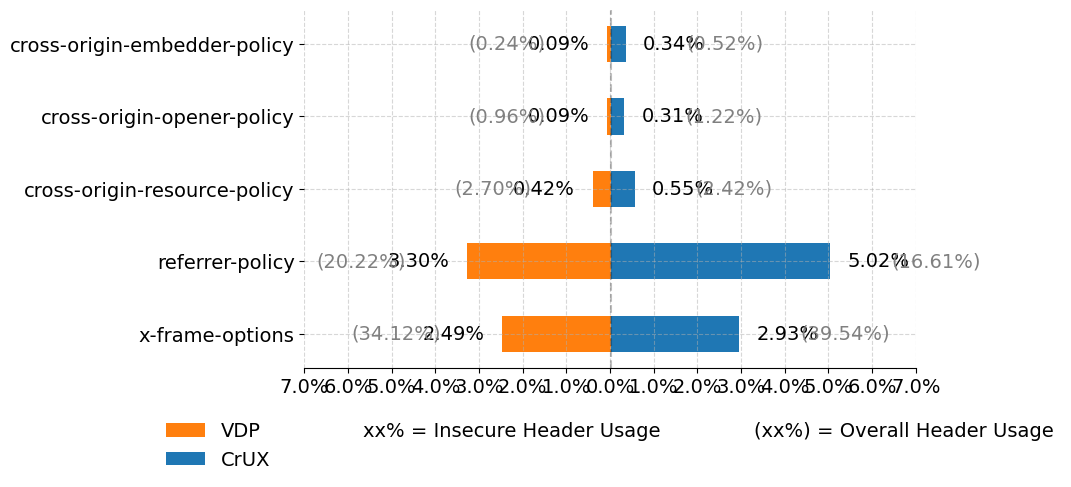

In [1]:
import json
import sqlite3
import pandas as pd
from collections import Counter

import json
import re

from enum import Enum


class FA(Enum):
    MISSING = -1
    UNSAFE = 0
    CONSTRAINED = 1
    SELF = 2
    NONE = 3


class XSS(Enum):
    MISSING = -1
    UNSAFE = 0
    SAFE = 1


class TLS(Enum):
    MISSING = -1
    UNSAFE = 0
    ENABLED = 1


class XFO(Enum):
    UNSAFE = 0
    SELF = 1
    NONE = 2


class HSTSAge(Enum):
    DISABLE = -1
    UNSAFE = 0
    LOW = 1
    BIG = 2


class HSTSSub(Enum):
    UNSAFE = 0
    SAFE = 1


class CookieSecure(Enum):
    UNSAFE = 0
    SAFE = 1


class CookieHttpOnly(Enum):
    UNSAFE = 0
    SAFE = 1


class CookieSameSite(Enum):
    NONE = 0
    LAX = 1
    STRICT = 2

HEADER_ABBREVIATION = {
    'content-security-policy': 'CSP',
    'x-frame-options': 'XFO',
    'strict-transport-security': 'HSTS',
    'referrer-policy': 'RP',
    'permissions-policy': 'PP',
    'cross-origin-opener-policy': 'COOP',
    'cross-origin-resource-policy': 'CORP',
    'cross-origin-embedder-policy': 'COEP'
}

INSECURE = {
    'content-security-policy': {'FA': FA.UNSAFE.value, 'XSS': XSS.UNSAFE.value, 'TLS': TLS.UNSAFE.value},
    'x-frame-options': 0,
    'strict-transport-security': (0, 0, 0),
    'referrer-policy': False,
    'permissions-policy': '',
    'cross-origin-opener-policy': False,
    'cross-origin-resource-policy': False,
    'cross-origin-embedder-policy': False
}


def normalize_headers(headers: dict):
    res = {}
    if 'content-security-policy' in headers:
        res['content-security-policy'] = normalize_csp(headers['content-security-policy'])
    if 'x-frame-options' in headers:
        res['x-frame-options'] = normalize_xfo(headers['x-frame-options'])
    if 'strict-transport-security' in headers:
        res['strict-transport-security'] = normalize_hsts(headers['strict-transport-security'])
    if 'referrer-policy' in headers:
        res['referrer-policy'] = normalize_referrer_policy(headers['referrer-policy'])
    if 'permissions-policy' in headers:
        res['permissions-policy'] = normalize_permissions_policy(headers['permissions-policy'])
    if 'cross-origin-opener-policy' in headers:
        res['cross-origin-opener-policy'] = normalize_coop(headers['cross-origin-opener-policy'])
    if 'cross-origin-resource-policy' in headers:
        res['cross-origin-resource-policy'] = normalize_corp(headers['cross-origin-resource-policy'])
    if 'cross-origin-embedder-policy' in headers:
        res['cross-origin-embedder-policy'] = normalize_coep(headers['cross-origin-embedder-policy'])
    return res


def classify_headers(headers, origin='https://dummy.de'):
    res = {}
    if 'content-security-policy' in headers:
        res['content-security-policy'] = json.dumps(parse_csp(origin, headers['content-security-policy']),
                                                    sort_keys=True)
    if 'x-frame-options' in headers:
        res['x-frame-options'] = get_level_xfo(headers['x-frame-options'])
    if 'strict-transport-security' in headers:
        res['strict-transport-security'] = get_level_hsts(headers['strict-transport-security'])
    if 'referrer-policy' in headers:
        res['referrer-policy'] = classify_referrer_policy(headers['referrer-policy'])
    if 'permissions-policy' in headers:
        res['permissions-policy'] = classify_permissions_policy(headers['permissions-policy'])
    if 'cross-origin-opener-policy' in headers:
        res['cross-origin-opener-policy'] = classify_coop(headers['cross-origin-opener-policy'])
    if 'cross-origin-resource-policy' in headers:
        res['cross-origin-resource-policy'] = classify_corp(headers['cross-origin-resource-policy'])
    if 'cross-origin-embedder-policy' in headers:
        res['cross-origin-embedder-policy'] = classify_coep(headers['cross-origin-embedder-policy'])
    return res


### Functions for XFO

# normalize XFO headers: convert to lower case, split over comma, sort and join over comma
def normalize_xfo(value):
    value = value.lower()
    toks = [x.strip() for x in value.split(',')]
    toks.sort()
    return ','.join(toks)


# we assume modern browsers not supporting ALLOW-FROM, so only SAMEORIGIN and DENY are considered
def get_level_xfo(value):
    value = normalize_xfo(value)
    if value == 'sameorigin':
        return 1
    if value == 'deny':
        return 2
    else:
        return 0


# comparison operator for XFO headers
def leq_xfo(v1, v2):
    return get_level_xfo(v1) <= get_level_xfo(v2)


### Functions for HSTS

# normalize HSTS headers: convert to lower case, split over semicolon, sort and join over semicolon
# note that only the first HSTS header is considered, according to RFC 6797
def normalize_hsts(value):
    value = value.lower()
    value = value.split(',')[0]
    toks = [x.strip() for x in value.split(';')]
    toks.sort()
    return ';'.join(toks)


# transforms an HSTS into an equivalent dictionary to simplify later checks
def parse_hsts(value):
    h = {}
    value = normalize_hsts(value)
    toks = value.split(';')

    for t in toks:
        if t == 'preload':
            h['preload'] = True
        if t == 'includesubdomains':
            h['isd'] = True
        if t.startswith('max-age='):
            try:
                h['max-age'] = int(t.split('=')[1])
            except ValueError:  # this handles malformed headers like max-age=1234 includesubheaders (missing ; )
                return None

    if 'preload' not in h:
        h['preload'] = False

    if 'isd' not in h:
        h['isd'] = False

    # lack of max-age implies that there is no HSTS protection
    if 'max-age' not in h:
        return None

    return h


def get_level_hsts(value):
    parsed = parse_hsts(value)
    if parsed is not None:
        return (get_level_hsts_age(parsed),
                int(parsed['isd']),
                int(parsed['preload'] and parsed['isd'] and get_level_hsts_age(parsed) == 3))
    else:
        return (get_level_hsts_age(parsed),
                0,
                0)


# auxiliary function for comparing HSTS classes, only used by leq_hsts
def get_level_hsts_age(value):
    if value is None:
        return 1
    if value['max-age'] <= 0:
        return 0
    if value['max-age'] < 31536000:
        return 2
    if value['max-age'] < 63072000:
        return 4
    else:
        return 3


# comparison operator for HSTS headers, cf. the definition in the security lottery paper
def leq_hsts(v1, v2):
    v1 = parse_hsts(v1)
    v2 = parse_hsts(v2)

    c1 = get_level_hsts_age(v1)
    c2 = get_level_hsts_age(v2)

    if v1 is None:
        return v2 is None

    if v2 is None:
        return v1 is None or c1 == 0

    if v1['isd'] and not v2['isd']:
        return False

    if v1['preload'] and not v2['preload']:
        return False

    return c1 <= c2


### Functions for CSP

# normalize CSP headers: convert to lower case, split over comma (headers), semicolon (directives) and spaces (source expressions), sort everything and join again
# note: we sort in reversed order to simplify the safety check over CSP, because script-src comes before default-src
def normalize_csp(value):
    value = value.lower()
    csps = [c.strip() for c in value.split(',')]
    value_new = []

    for csp in csps:
        dirs = [d.strip() for d in csp.split(';')]
        dirs_new = []

        for d in dirs:
            toks = [t.strip() for t in d.split(' ')]
            toks_new = []

            if toks[0] in ['report-uri', 'report-to']:
                for _ in toks[1:]:
                    toks_new.append('URI')
            else:
                for tok in toks[1:]:
                    if tok.startswith("'nonce-"):
                        toks_new.append("'nonce-'")
                    else:
                        toks_new.append(tok)
            toks_new.sort()
            dirs_new.append(toks[0] + ' ' + ' '.join(toks_new))

        dirs_new.sort(reverse=True)
        value_new.append(';'.join(dirs_new))

    value_new.sort()
    return ','.join(value_new)


def is_unsafe_inline_active(sources: set) -> bool:
    allow_all_inline = False
    for source in sources:
        r = r"^('NONCE'|'nonce-[A-Za-z0-9+/\-_]+={0,2}'|'sha(256|384|512)-[A-Za-z0-9+/\-_]+={0,2}'|'strict-dynamic')$"
        if re.search(r, source, re.IGNORECASE):
            return False
        if re.match(r"^'unsafe-inline'$", source, re.IGNORECASE):
            allow_all_inline = True
    return allow_all_inline


# Paper Definition 3
def is_safe_csp(csp: dict) -> bool:
    unsafe_expressions = {'*', 'http:', 'http://', 'http://*', 'https:', 'https://', 'https://*', 'data:'}
    effective_source = csp['script-src'] if "script-src" in csp else csp.get('default-src', None)
    if effective_source is None or is_unsafe_inline_active(effective_source):
        return False
    if "'strict-dynamic'" not in effective_source and effective_source & unsafe_expressions:
        return False
    return True


def classify_framing(origin: str, sources: set) -> int:
    if sources == {"'none'"} or len(sources) == 0:
        return FA.NONE.value
    https_origin = origin.replace('http://', 'https://')
    domain_origin = origin.replace('http://', '').replace('https://', '')
    if len(sources) > 0 and len(sources - {"'self'", origin, https_origin, domain_origin}) == 0:
        return FA.SELF.value
    unsafe_expressions = {'*', 'http:', 'http://', 'http://*', 'https:', 'https://', 'https://*'}
    if sources.intersection(unsafe_expressions):
        return FA.UNSAFE.value
    return FA.CONSTRAINED.value


def classify_csp(origin: str, parsed_csp: dict) -> dict:
    classes = {'FA': FA.MISSING.value, 'XSS': XSS.MISSING.value, 'TLS': TLS.MISSING.value}
    if 'script-src' in parsed_csp or 'default-src' in parsed_csp:
        classes['XSS'] = XSS.UNSAFE.value
    if is_safe_csp(parsed_csp):
        classes['XSS'] = XSS.SAFE.value
    if 'upgrade-insecure-requests' in parsed_csp or 'block-all-mixed-content' in parsed_csp:
        if 'block-all-mixed-content' in parsed_csp:
            classes['TLS'] = 5
        if 'upgrade-insecure-requests' in parsed_csp:
            classes['TLS'] = 4
        if 'upgrade-insecure-requests' in parsed_csp and 'block-all-mixed-content' in parsed_csp:
            classes['TLS'] = 9
    if 'frame-ancestors' in parsed_csp:
        classes['FA'] = classify_framing(origin, parsed_csp['frame-ancestors'])
    return classes


# checks whether a list of source expression is safe with respect to XSS mitigation
def parse_csp(origin, raw_csp):
    if raw_csp is None:
        return {'FA': FA.UNSAFE.value, 'XSS': XSS.UNSAFE.value, 'TLS': TLS.UNSAFE.value}
    # Normalize Random Values
    policy_str = raw_csp
    nonce_regex = r"'nonce-[^']*'"
    policy_str = re.sub(nonce_regex, "'NONCE'", policy_str)
    report_regex = r"report-uri [^; ]*"
    policy_str = re.sub(report_regex, 'report-uri REPORT_URI;', policy_str)
    report_to = r"report-to [^; ]*"
    policy_str = re.sub(report_to, 'report-to REPORT_URI;', policy_str)
    # Let policy be a new policy with an empty directive set
    complete_policy = dict()
    # For each token returned by splitting list on commas
    for policy_string in policy_str.encode().lower().split(b','):
        # Let policy be a new policy with an empty directive set
        policy = dict()
        # For each token returned by strictly splitting serialized on the U+003B SEMICOLON character (;):
        tokens = policy_string.split(b';')
        for token in tokens:
            # Strip all leading and trailing ASCII whitespace from token.
            data = token.strip().split()
            # If token is an empty string, continue.
            if len(data) == 0:
                continue
            # Let directive name be the result of collecting a sequence of code points from
            # token which are not ASCII whitespace.
            while data[0] == ' ':
                data = data[1:]
                if len(data) == 0:
                    break
            # If token is an empty string, continue.
            if len(data) == 0:
                continue
            # Set directive name to be the result of running ASCII lowercase on directive name.
            directive_name = data[0]
            # If policy's directive set contains a directive whose name is directive name, continue.
            if directive_name in policy:
                continue
            # Let directive value be the result of splitting token on ASCII whitespace.
            directive_set = set()
            for d in data[1:]:
                if d.strip() != '':
                    directive_set.add(d.decode())
            # Append directive to policy’s directive set.
            policy[directive_name.decode()] = directive_set
        csp_classes = classify_csp(origin, policy)
        for use_case in csp_classes:
            if use_case in complete_policy:
                complete_policy[use_case] = max(complete_policy[use_case], csp_classes[use_case])
            else:
                complete_policy[use_case] = csp_classes[use_case]
    # Return policy dict
    return complete_policy


# Additional headers

def normalize_referrer_policy(value):
    return value.lower().strip()


def classify_referrer_policy(value):
    return normalize_referrer_policy(value) not in ('no-referrer-when-downgrade', 'unsafe-url')


def normalize_permissions_policy(value):
    value = value.lower()
    toks = [x.strip() for x in value.split(',')]
    toks.sort()
    return ','.join(toks)


def classify_permissions_policy(value):
    return normalize_permissions_policy(value)


def normalize_coop(value):
    return value.lower().strip()


def classify_coop(value):
    return normalize_coop(value) not in ('unsafe-none', '')


def normalize_corp(value):
    return value.lower().strip()


def classify_corp(value):
    return normalize_corp(value) not in ('cross-origin', '')


def normalize_coep(value):
    return value.lower().strip()


def classify_coep(value):
    return normalize_coep(value) not in ('unsafe-none', '')

import json
import sqlite3
import pandas as pd
from collections import Counter
import json
import sqlite3
import pandas as pd
from collections import Counter, defaultdict
from urllib.parse import urlparse
import tldextract
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch


def extractOrigin(url):
    try:
        parsed_url = urlparse(url)
        return f"{parsed_url.scheme}://{parsed_url.netloc}"
    except Exception as e:
        print(f"[!] Error extracting origin from {url}: {e}")
        return None  # Return None if URL is malformed

def analyseHeaders(source):
    print(f"\n[*] Starting analysis of header data from {source}...")

    # Database connection
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE headers IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)

    chunksize = 2500
    secure_counter= Counter()
    insecure_counter = Counter()
    insecure_counter_domain = defaultdict(set)
    permissionPolicyWebsites = defaultdict(set)
    permissionPolicyDomains = defaultdict(set)
    hstsWebsites = defaultdict(set)
    hstsDomains = defaultdict(set)
    cspWebsites = defaultdict(set)
    cspDomains = defaultdict(set)
    domainFrameingRating = defaultdict(list)
    count_succ = 0
    count_fail = 0
    domain_set = set()
    i = 0 

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        print("Starting with chunk...")
        df['origin'] = df['url'].apply(extractOrigin)
        for _, row in df.iterrows():
            try:
                headers = {k.lower(): v for k, v in json.loads(row['headers']).items()}
                # Skip rows with errors
                if 'error' in headers.keys() and headers['error'] is not None:
                    count_fail += 1
                    continue

                headers_json = json.loads(row['headers']) if isinstance(row['headers'], str) else row['headers']
                headers_data = {k.lower(): v for k, v in headers_json.get('data', {}).items()}
                # Normalize and classify headers
                classified_headers = classify_headers(headers_data, row['origin'])

                # Check for insecure headers
                extraction =  tldextract.extract(row['url'])
                domain = f'{extraction.subdomain}.{extraction.domain}.{extraction.suffix}'      
                domain_set.add(domain)          
                for header, classification in classified_headers.items():
                    # Make a statistic about most commonly set permissions for the websites/domains
                    if header == "permissions-policy":
                        set_permissions = classification.split(",")
                        # avoid duplicated adding
                        for permission in list(set(set_permissions)):
                            permissionPolicyWebsites[permission].add(row['url'])
                            permissionPolicyDomains[permission].add(domain)
                        exit(1)

                    # Make a statistic about most commonly observed security implications by HSTS for the websites/domains
                    if header == "strict-transport-security":
                        hstsWebsites[classification].add(row['url'])
                        hstsDomains[classification].add(domain)

                    # Make a statistic about most commonly observed security implications by CSP for the websites/domains - SIMPLE MODE -> CSP Evalutor can do this better
                    if header == "content-security-policy":
                        cspWebsites[classification].add(row['url'])
                        cspDomains[classification].add(domain)

                        # Framing
                        domainFrameingRating[domain].append(json.loads(classification)['FA'])


                    if isinstance(classification, dict):
                        # If classification is a dict (e.g., CSP), check values
                        if any(v == 0 or v == "unsafe" for v in classification.values()):
                            insecure_counter[header] += 1
                            insecure_counter_domain[header].add(domain)
                        else:
                            secure_counter[header] += 1
                    else:
                        # If classification is a single value, check directly
                        if classification == 0 or classification == "unsafe":
                            insecure_counter[header] += 1
                            insecure_counter_domain[header].add(domain)
                        else:
                            secure_counter[header] += 1

                count_succ += 1
            
            except Exception as e:
                print(f"[!] Error processing row {i}: {e}")
                count_fail += 1
            i += 1

    # Print Summary
    print(f"\n[*] Processed {count_succ + count_fail} records. Successful: {count_succ}, Failed: {count_fail}")
    
    print("\n=== Insecure Headers Found ===")
    for header, count in insecure_counter.items():
        print(f" - {header}: {count} times - {count/count_succ * 100}%")

    print("\n=== Secure Headers Found ===")
    for header, count in secure_counter.items():
        print(f" - {header}: {count} times - {count/count_succ * 100}%")

    print("\n=== Insecure Headers Domain Breakdown ===")
    for header, domains in insecure_counter_domain.items():
        print(f" - {header}: Found in {len(domains)} unique domains - {len(domains)/len(domain_set) * 100}%")

    print("\n=== Permission Policies Per Webpages Breakdown ===")
    top_results_all = sorted(permissionPolicyWebsites.items(), key=lambda item: len(item[1]), reverse=True)
    top_results = top_results_all[:10]
    top_results_enabling = {
        permission: websites
        for permission, websites in permissionPolicyWebsites.items()
        if "()" not in permission
    }
    top_results_enabling = sorted(top_results_enabling.items(), key=lambda item: len(item[1]), reverse=True)

    for permission, websites in top_results:
        print(f" - {permission}: Found in {len(websites)} unique websites - {len(websites)/count_succ * 100}%")

    print("Non forbidding Policies")
    for permission, domains in top_results_enabling:
        print(f" - {permission}: Found in {len(websites)} unique websites - {len(websites)/count_succ * 100}%")

    print("\n=== Permission Policies Per Domains Breakdown ===")
    top_results_all = sorted(permissionPolicyDomains.items(), key=lambda item: len(item[1]), reverse=True)
    top_results = top_results_all[:10]
    top_results_enabling = {
        permission: domains
        for permission, domains in permissionPolicyDomains.items()
        if "()" not in permission
    }
    top_results_enabling = sorted(top_results_enabling.items(), key=lambda item: len(item[1]), reverse=True)

    top_results = top_results[:10]
    for permission, domains in top_results:
        print(f" - {permission}: Found in {len(domains)} unique domains - {len(domains)/len(domain_set) * 100}%")

    print("Non forbidding Policies")
    top_results_enabling = top_results_enabling[:10]
    for permission, domains in top_results_enabling:
        print(f" - {permission}: Found in {len(domains)} unique domains - {len(domains)/len(domain_set) * 100}%")

    print("\n=== HSTS Per Webpages Breakdown ===")
    for permission, websites in hstsWebsites.items():
        print(f" - {permission}: Found in {len(websites)} unique websites - {len(websites)/count_succ * 100}%")
              
    print("\n=== HSTS Per Domains Breakdown ===")
    for permission, domains in hstsDomains.items():
        print(f" - {permission}: Found in {len(domains)} unique domains - {len(domains)/len(domain_set) * 100}%")

    print("\n=== CSP Per Webpages Breakdown ===")
    for permission, websites in cspWebsites.items():
        print(f" - {permission}: Found in {len(websites)} unique websites - {len(websites)/count_succ * 100}%")
              
    print("\n=== CSP Per Domains Breakdown ===")
    for permission, domains in cspDomains.items():
        print(f" - {permission}: Found in {len(domains)} unique domains - {len(domains)/len(domain_set) * 100}%")

    print("\n=== CSP-Frameing Per Domains Breakdown ===")
    domains_only_insecure = set()
    domains_always_missing_or_none = set()
    domains_with_some_insecure = set()
    domains_only_self = set()
    domains_only_constrained = set()

    for domain, fa_results in domainFrameingRating.items():
        fa_values = set(fa_results)

        # Check if only FA.MISSING (-1) or FA.NONE (3)
        if fa_values.issubset({-1, 3}):
            domains_always_missing_or_none.add(domain)

        # Check if at least once FA.UNSAFE (0)
        if 0 in fa_values:
            domains_with_some_insecure.add(domain)

        # Check if all values are FA.UNSAFE (0)
        if fa_values == {0}:
            domains_only_insecure.add(domain)
            
        if fa_values == {2}:
            domains_only_self.add(domain)    
    
        if fa_values == {1}:
            domains_only_constrained.add(domain)    

    print("=== Framing Policy Summary ===")
    print(f"Domains always insecure (only FA.UNSAFE): {len(domains_only_insecure)} - {len(domains_only_insecure)/len(domain_set) * 100}%")
    print(f"Domains always secure (only FA.SELF): {len(domains_only_self)} - {len(domains_only_insecure)/len(domain_set) * 100}%")
    print(f"Domains always constrained (only FA.CONSTRAINED): {len(domains_only_constrained)} - {len(domains_only_constrained)/len(domain_set) * 100}%")
    print(f"Domains always missing or 'none' (only FA.MISSING or FA.NONE): {len(domains_always_missing_or_none)} - {len(domains_always_missing_or_none)/len(domain_set) * 100}%")
    print(f"Domains with at least one insecure value (FA.UNSAFE present): {len(domains_with_some_insecure)} - {len(domains_with_some_insecure)/len(domain_set) * 100}%")
    print(f"Overall Domains {len(domain_set)}")
    print("")
    

    return insecure_counter, insecure_counter_domain, domain_set

print("Analysis similar to archive paper:")
_, insecure_counter_domain_vdp, vdp_domain_set = analyseHeaders('BB')
print("------------")
_, insecure_counter_domain_crux, crux_domain_set = analyseHeaders('CRUX')


# Ergebnisse berechnen
results = {}
all_headers = sorted(set(insecure_counter_domain_vdp.keys()) | set(insecure_counter_domain_crux.keys()))

for header in all_headers:
    vdp_pct = len(insecure_counter_domain_vdp.get(header, set())) / len(vdp_domain_set) * 100
    crux_pct = len(insecure_counter_domain_crux.get(header, set())) / len(crux_domain_set) * 100
    results[header] = [vdp_pct, crux_pct]

    
# Plot-Funktion
def create_plot(results, category_names):
    labels = list(results.keys())
    data = np.array(list(results.values()))

    max_val = np.max(np.abs(data)) + 1
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(labels, -data[:, 0], height=0.5, label=category_names[0], color='C1')
    ax.barh(labels, data[:, 1], height=0.5, label=category_names[1], color='C0')
    
    ax.axvline(0, linestyle='--', color='black', alpha=.25)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-max_val - 1, max_val)
    ax.set_xticks(np.arange(-max_val - 1 , max_val + 1, 1.0))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{abs(x):.1f}%" if x != 0 else "0%"))
    ax.invert_yaxis()
    
    ax.tick_params(axis='both', labelsize=14)
    ax.set_yticklabels(labels, fontsize=14)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    legend_elements = [
        Patch(facecolor='C1', label='VDP'),    # Orange
        Patch(facecolor='C0', label='CrUX'),   # Blau
        Patch(facecolor='none', edgecolor='none', label='xx% = Insecure Header Usage'),
        Patch(facecolor='none', edgecolor='none', label='(xx%) = Overall Header Usage')
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.10),
        ncol=3,
        fontsize=14,
        frameon=False
    )
    fig.set_facecolor('#FFFFFF')

    # Beschriftung der Balken
    overall_vdp = [0.24, 0.96, 2.70, 20.22, 34.12]
    overall_crux = [0.52, 1.22, 2.42, 16.61 , 39.54]
    for i, label in enumerate(labels):
        bb_pct = data[i, 0]
        crux_pct = data[i, 1]
        bb_overall = overall_vdp[i]
        crux_overall = overall_crux[i]
        bb_offset = max(0.25, len(f'{bb_pct:.2f}') * 0.1)
        crux_offset = max(0.25, len(f'{crux_pct:.2f}') * 0.1)
        
        ax.text(-bb_pct - bb_offset, i, f'{bb_pct:.2f}%', va='center', ha='right', fontsize=14, color='black')
        ax.text(-bb_pct - bb_offset - 1, i, f'({bb_overall:.2f}%)',
                va='center', ha='right', fontsize=14, color='gray')

        ax.text(crux_pct + crux_offset, i, f'{crux_pct:.2f}%', va='center', ha='left', fontsize=14, color='black')
        ax.text(crux_pct + crux_offset + 1, i, f'({crux_overall:.2f}%)',
                va='center', ha='left', fontsize=14, color='gray')

    return fig, ax

# Plot erzeugen
category_names = ['VDP', 'CrUX']
fig, ax = create_plot(results, category_names)
#plt.title("Prevalence of Insecure Headers")
plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/insecure_headers_domains.pdf', format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_67180/3006670181.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=18)


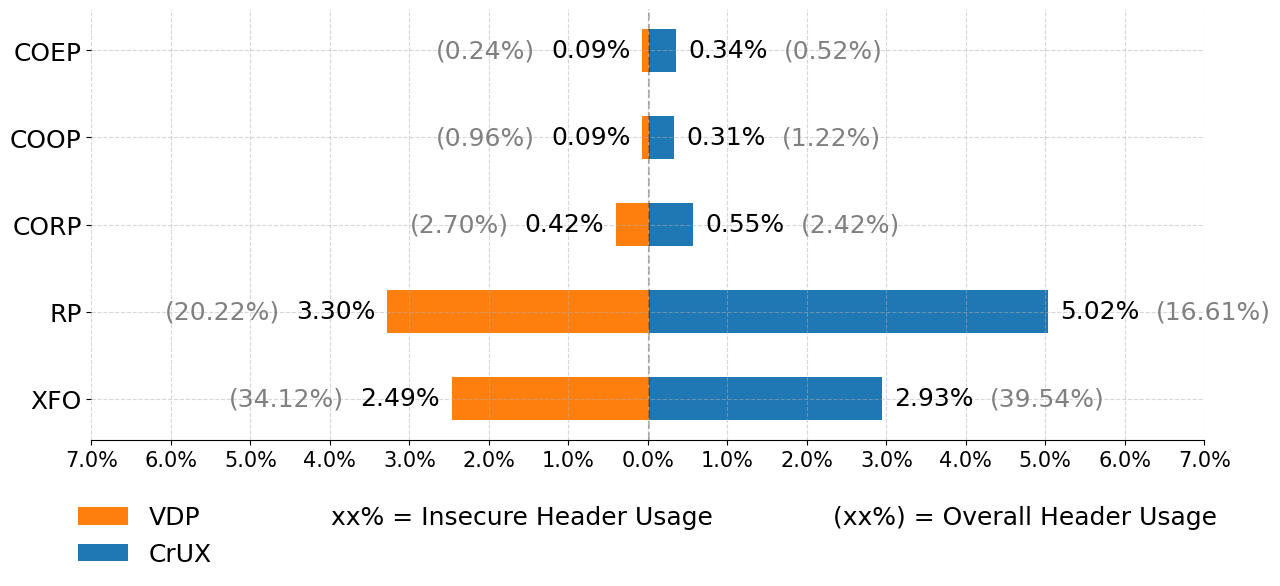

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Beispiel-Daten aus dem PDF
results = {
    "COEP": [0.09, 0.34],
    "COOP": [0.09, 0.31],
    "CORP": [0.42, 0.55],
    "RP": [3.30, 5.02],
    "XFO": [2.49, 2.93],
}

# Gesamtverwendung (für die grauen Werte in Klammern)
overall_vdp = [0.24, 0.96, 2.70, 20.22, 34.12]
overall_crux = [0.52, 1.22, 2.42, 16.61 , 39.54]

# Plot-Funktion
def create_plot(results, category_names):
    labels = list(results.keys())
    data = np.array(list(results.values()))

    max_val = np.max(np.abs(data)) + 1
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.barh(labels, -data[:, 0], height=0.5, label=category_names[0], color='C1')
    ax.barh(labels, data[:, 1], height=0.5, label=category_names[1], color='C0')
    
    ax.axvline(0, linestyle='--', color='black', alpha=.25)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-max_val - 1, max_val)
    ax.set_xticks(np.arange(-max_val - 1 , max_val + 1, 1.0))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{abs(x):.1f}%" if x != 0 else "0%"))
    ax.invert_yaxis()
    
    ax.tick_params(axis='both', labelsize=15)
    ax.set_yticklabels(labels, fontsize=18)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    legend_elements = [
        Patch(facecolor='C1', label='VDP'),
        Patch(facecolor='C0', label='CrUX'),
        Patch(facecolor='none', edgecolor='none', label='xx% = Insecure Header Usage'),
        Patch(facecolor='none', edgecolor='none', label='(xx%) = Overall Header Usage')
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.10),
        ncol=3,
        fontsize=18,
        frameon=False
    )
    fig.set_facecolor('#FFFFFF')

    for i, label in enumerate(labels):
        bb_pct = data[i, 0]
        crux_pct = data[i, 1]
        bb_overall = overall_vdp[i]
        crux_overall = overall_crux[i]
        bb_offset = max(0.15, len(f'{bb_pct:.2f}') * 0.01)
        crux_offset = max(0.15, len(f'{crux_pct:.2f}') * 0.01)
        
        ax.text(-bb_pct - bb_offset, i, f'{bb_pct:.2f}%', va='center', ha='right', fontsize=18, color='black')
        ax.text(-bb_pct - bb_offset - 1.2, i, f'({bb_overall:.2f}%)', va='center', ha='right', fontsize=18, color='gray')
        ax.text(crux_pct + crux_offset, i, f'{crux_pct:.2f}%', va='center', ha='left', fontsize=18, color='black')
        ax.text(crux_pct + crux_offset + 1.2, i, f'({crux_overall:.2f}%)', va='center', ha='left', fontsize=18, color='gray')

    return fig, ax

# Plot erzeugen
category_names = ['VDP', 'CrUX']
fig, ax = create_plot(results, category_names)
plt.tight_layout()
plt.savefig('insecure_headers_domains.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [17]:
# CSP
# Analysis of CSP

###########
# BB

def eval_csp(source):
    error_counter = Counter()
    reviews_done = 0
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE csp_rating IS NOT NULL and source ='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['csp_formated'] = df['csp_rating'].apply(json.loads)
        for entry in df['csp_formated']:
            if entry['error'] != "null" and entry['error'] is not None:
                if 'Read timed out' in entry['error']:
                    error_counter['Readtimeout (30 Seconds Exceeded)'] += 1
                elif 'No Content-Security-Policy found' in entry['error']:
                    reviews_done += 1
                else:
                    error_counter[entry['error']] += 1
            else:
                if entry['error'] is None:
                    reviews_done += 1
                

    error_count = 0
    for key, num in error_counter.items():
        if key != "No Content-Security-Policy found":
            print(f"  - {key} : {num}")
            error_count += num
    print(f" [*] {source} - Number of Errors - {error_count}")
    print(f" [*] {source} - Number of CSP Reviews done - {reviews_done}")
    print()

eval_csp("BB")
print("---------")
eval_csp("CRUX")

  - Exception: HTTPConnectionPool(host='127.0.0.1', port=9091): Max retries exceeded with url: http://karweioutletstore.nl/ (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f79eb37c410>: Failed to establish a new connection: [Errno 111] Connection refused'))) : 1
  - Exception: HTTPConnectionPool(host='127.0.0.1', port=9092): Max retries exceeded with url: http://developer.ifood.com.br/ (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f79eb37c500>: Failed to establish a new connection: [Errno 111] Connection refused'))) : 1
  - Exception: HTTPConnectionPool(host='127.0.0.1', port=9092): Max retries exceeded with url: http://theunioncard.com/ (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f79eb37e6f0>: Failed to establish a new connection: [Errno 111] Connection refused'))) :

In [8]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter, defaultdict
import json
import re
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np
import tldextract


def eval_csp(source):
    print(f"[*] {source} - Further Analysis of CSPEvaluation Results...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE csp_rating IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    csp_results = Counter()
    website_dict = defaultdict(set)
    no_problem_urls = set()
    overall_urls = set()

    domain_dict = defaultdict(set)
    no_problems_domains = set()
    overall_domains = set()
    overall_domains_with_results = set()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['csp_rating_json'] = df['csp_rating'].apply(json.loads)
        entries =+ 1
        for _, row in df.iterrows():
            extraction =  tldextract.extract(row['url'])
            domain = f'{extraction.subdomain}.{extraction.domain}.{extraction.suffix}' 
            overall_domains.add(domain)  
            if row['csp_rating_json']['analysis'] is not None:
                overall_domains_with_results.add(domain)
                overall_urls.add(row['url'])
                for list_entry in row['csp_rating_json']['analysis']:
                    if isinstance(list_entry, dict) and "type" in list_entry.keys():
                        key = f"{list_entry['type']} - {list_entry['description']} - {list_entry['directive']} - {list_entry['severity']}"
                        csp_results[key] += 1
                        website_dict[key].add(row['url'])
                        domain_dict[key].add(domain)

                if len(row['csp_rating_json']['analysis']) <= 1:
                    if any("No bypass found; make sure that this URL doesn't serve JSONP replies or Angular libraries." in x['description'] for x in row['csp_rating_json']['analysis']):
                        no_problem_urls.add(row['url'])
                        no_problems_domains.add(domain)
                        print("-------")
                        print(f"No Problem found for: {row['url']}")
                        print(f"Error: {row['csp_rating_json']['error']}")
                        print("-------")

    print(len(overall_domains_with_results))
    print(len(overall_domains))
    print(f"{len(overall_domains_with_results)/len(overall_domains) * 100}%")

    print()
    print()

    print("\n=== CSP Advisories Per Domain ===")
    top_results_all = sorted(domain_dict.items(), key=lambda item: len(item[1]), reverse=True)
    top_results = top_results_all[:25]
    print(f"No Errors found in {len(no_problems_domains)} Domains")
    for advise, domains in top_results:
        print(f" - {advise}: Found in {len(domains)} unique domains - {len(domains)/len(overall_domains) * 100}%")



    return top_results_all, domain_dict, overall_domains

csp_eval_BB, domain_dict_bb, overall_domains_bb = eval_csp("BB")
csp_eval_CRUX, domain_dict_crux, overall_domains_crux = eval_csp("CRUX")


# -------- Zusammen addieren ---------
added_percentages = {}

# VDP-Daten hinzufügen
for header, domains in domain_dict_bb.items():
    percent = len(domains) / len(overall_domains_bb) * 100
    added_percentages[header] = added_percentages.get(header, 0) + percent

# CrUX-Daten hinzufügen
for header, domains in domain_dict_crux.items():
    percent = len(domains) / len(overall_domains_crux) * 100
    added_percentages[header] = added_percentages.get(header, 0) + percent

# Sortiert ausgeben
sorted_added = sorted(added_percentages.items(), key=lambda x: x[1], reverse=True)
for header, total_percent in sorted_added[:25]:
    print(f"{header}: {total_percent:.2f}% combined")


'''
print("---------")
csp_eval_CRUX = eval_csp("CRUX")

# ----- Chi Test (unverändert) -----
dictA = dict(csp_eval_BB)
dictB = dict(csp_eval_CRUX)

all_categories = sorted(set(dictA.keys()).union(dictB.keys()))
table = []
for cat in all_categories:
    table.append([dictA.get(cat, 0), dictB.get(cat, 0)])

df_contingency = pd.DataFrame(table, index=all_categories, columns=["A", "B"])
chi2, pval, dof, expected = chi2_contingency(df_contingency)

print("Chi2-Statistik =", chi2)
print("p-Wert =", pval)
print("Freiheitsgrade =", dof)

alpha = 0.05
if pval < alpha:
    print("Signifikant unterschiedlich (p < 0.05).")
else:
    print("Kein statistisch signifikanter Unterschied (p >= 0.05).")
# ----- Visualisierung mit Sortierung und Begrenzung auf 20 -----
sumA = sum(dictA.values())
sumB = sum(dictB.values())

diff_list = []
for cat in all_categories:
    diff = ((dictA.get(cat, 0) / sumA) - (dictB.get(cat, 0) / sumB)) * 100
    diff_list.append((cat, diff))

# Nach absolut größtem Unterschied sortieren und auf die Top 20 beschränken
sorted_diff_list = sorted(diff_list, key=lambda x: abs(x[1]), reverse=True)
top_20 = sorted_diff_list[:20]

# Vorbereitung für Plot
top_categories = [item[0] for item in top_20]
delta_perc = [item[1] for item in top_20]

x = np.arange(len(top_categories))

plt.figure(figsize=(12, 6))
bars = plt.bar(x, delta_perc, alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.bar_label(bars, fmt='%.2f%%')
plt.xticks(x, top_categories, rotation=90)
plt.ylabel("Prozentuale Differenz (A - B)")
plt.title("Top 20: Prozentuale Abweichung pro Kategorie (nach größtem Unterschied)")
plt.tight_layout()
plt.show()
'''

[*] BB - Further Analysis of CSPEvaluation Results...
-------
No Problem found for: https://phabricator.allizom.org/pholio/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/differential/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/feed/query/all/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/dashboard/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/applications/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/feed/7467350203449286871/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/diffusion/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/maniphest/query/open/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/herald/
Error: None
-------
-------
No Problem found for: https://phabricator.allizom.org/T13
Error: None


'\nprint("---------")\ncsp_eval_CRUX = eval_csp("CRUX")\n\n# ----- Chi Test (unverändert) -----\ndictA = dict(csp_eval_BB)\ndictB = dict(csp_eval_CRUX)\n\nall_categories = sorted(set(dictA.keys()).union(dictB.keys()))\ntable = []\nfor cat in all_categories:\n    table.append([dictA.get(cat, 0), dictB.get(cat, 0)])\n\ndf_contingency = pd.DataFrame(table, index=all_categories, columns=["A", "B"])\nchi2, pval, dof, expected = chi2_contingency(df_contingency)\n\nprint("Chi2-Statistik =", chi2)\nprint("p-Wert =", pval)\nprint("Freiheitsgrade =", dof)\n\nalpha = 0.05\nif pval < alpha:\n    print("Signifikant unterschiedlich (p < 0.05).")\nelse:\n    print("Kein statistisch signifikanter Unterschied (p >= 0.05).")\n# ----- Visualisierung mit Sortierung und Begrenzung auf 20 -----\nsumA = sum(dictA.values())\nsumB = sum(dictB.values())\n\ndiff_list = []\nfor cat in all_categories:\n    diff = ((dictA.get(cat, 0) / sumA) - (dictB.get(cat, 0) / sumB)) * 100\n    diff_list.append((cat, diff))\n\n

## Results - Cookies

In [ ]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter
import json
import re

print("[*] Cookie Analysis...")
def eval_cookies(source):
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    count_succ = 0
    count_fail = 0
    error_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)
        
        count = df['cookies_formated'].apply(lambda x: len(x) != 0).sum()
        count_succ += count 
        count = df['cookies_formated'].apply(lambda x: len(x) == 0).sum()
        count_fail += count

        for cookies_dict in df['cookies_formated']:
            for cookie_dict in cookies_dict:
                if "error" in cookie_dict.keys():
                    count_fail += 1
                    count_succ -= 1

                    pattern = r"Exception: Page.goto: (.*?) at "

                    # Perform the search
                    match = re.search(pattern, cookie_dict['error'])

                    if match:
                        extracted_text = match.group(1) 
                        error_counter[extracted_text] += 1
                    else:
                        if "Timeout" in cookie_dict['error']:
                            error_counter["Timeout"] += 1

                        elif "Seemingly Unwanted Redirection occurend" in cookie_dict['error']:
                            error_counter["Redirection"] += 1

                        elif "Download is starting" in cookie_dict['error']:
                            error_counter["Downloading File"] += 1

                        elif "NS_ERROR_PROXY_BAD_GATEWAY" in cookie_dict['error']:
                            error_counter["NS_ERROR_PROXY_BAD_GATEWAY"] += 1

                        elif "NS_ERROR_NET_TIMEOUT" in cookie_dict['error']:
                            error_counter["NS_ERROR_NET_TIMEOUT"] += 1
                            
                        elif True:
                            print(cookie_dict['error'])

                    break

    print(f" [!] {source} - ERRORS:")    
    for key, num in error_counter.items():
        print(f"  - {key} : {num}")

    print(f" [*] {source} - Webpages for which cookies were stored: - {count_succ}")
    print(f" [*] {source} - Webpages for which no cookies were stored: - {count_fail}")
    print(f' [*]  --> Error Rate: {count_fail/(count_succ + count_fail)*100}%')
    print()

eval_cookies("BB")
print("---------")
eval_cookies("CRUX")

[*] Cookie Analysis...
Exception: Page.goto: NS_ERROR_REDIRECT_LOOP
Call log:
navigating to "http://store.playstation.com/", waiting until "load"

Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
 [!] BB - ERRORS:
  - Timeout : 163
  - Redirection : 389
  - NS_ERROR_NET_TIMEOUT : 8
 [*] BB - Webpages for which cookies were stored: - 11519
 [*] BB - Webpages for which no cookies were stored: - 2815
 [*]  --> Error Rate: 19.638621459467%

---------
Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
Exception: Page.evaluate: Execution context was destroyed, most likely because of a navigation
Exception: Page.goto: Target

[*] BB - Evaluating cookies
  - __cf_bm: 4985
  - _ga: 4477
  - _cfuvid: 2816
  - _gid: 1989
  - _gcl_au: 1842
  - _fbp: 1294
  - __cfruid: 1176
  - ak_bmsc: 946
  - bcookie: 762
  - li_gc: 762
  - lidc: 762
  - _ttp: 638
  - _gat: 634
  - demdex: 601
  - AWSALB: 594
  - AWSALBCORS: 578
  - JSESSIONID: 549
  - sid: 544
  - utag_main: 534
  - test_cookie: 530
  - dwsid: 506
  - YSC: 495
  - __Secure-ROLLOUT_TOKEN: 495
  - VISITOR_INFO1_LIVE: 495
  - VISITOR_PRIVACY_METADATA: 495
  - __cq_dnt: 485
  - dw_dnt: 485
  - cf_clearance: 472
  - bm_sv: 453
  - PHPSESSID: 449
  - dpm: 447
  - personalization_id: 439
  - _dd_s: 429
  - cookieChoice: 428
  - __srovname_uid: 428
  - to_consent_v2: 428
  - ABTastyOptout: 417
  - ajs_anonymous_id: 404
  - s_cc: 403
  - pixel: 400
  - yotpo_pixel: 400
  - SSID_p0Pp: 385
  - SSSC_p0Pp: 385
  - SSRT_p0Pp: 385
  - muc_ads: 383
  - bm_sz: 381
  - _abck: 381
  - everest_g_v2: 380
  - ASP.NET_SessionId: 379
  - kk_leadtag: 374
  - _d2id: 362
  - everest_ses

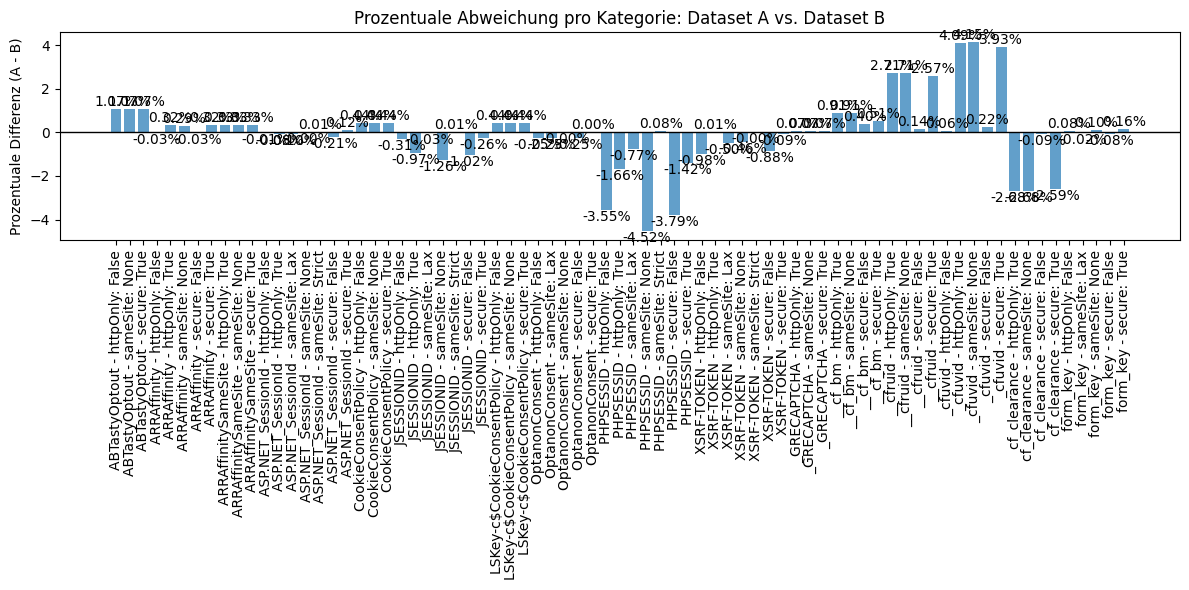

In [10]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter
import json
from scipy.stats import chi2_contingency
import re
import numpy as np
import matplotlib.pyplot as plt

def eval_cookies(source):
    print(f"[*] {source} - Evaluating cookies")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    important_cookies = [
        "PHPSESSID",
        "JSESSIONID",
        "ASP.NET_SessionId",
        "XSRF-TOKEN",
        "form_key",
        "__cf_bm",
        "cf_clearance",
        "_cfuvid",
        "__cfruid",
        "ABTastyOptout",
        "OptanonConsent",
        "ARRAffinity",
        "ARRAffinitySameSite",
        "CookieConsentPolicy",
        "LSKey-c$CookieConsentPolicy",
        "_GRECAPTCHA"
    ]
    
    cookie_counter = Counter()
    sess_cookie = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)
        for cookies_dict in df['cookies_formated']:
            for cookie in cookies_dict:
                if 'name' in cookie.keys():
                    if cookie['name'] in important_cookies:

                        if "httpOnly" in cookie.keys():
                            key = f"{cookie['name']} - httpOnly: {cookie['httpOnly']}"
                            sess_cookie[key] += 1

                        if "secure" in cookie.keys():
                            key = f"{cookie['name']} - secure: {cookie['secure']}"
                            sess_cookie[key] += 1

                        if "sameSite" in cookie.keys():
                            key = f"{cookie['name']} - sameSite: {cookie['sameSite']}"
                            sess_cookie[key] += 1

                    
                    cookie_counter[cookie['name']] += 1

    cookie_counter = sorted(cookie_counter.items(), key=lambda item: item[1], reverse=True)
    cookie_counter = cookie_counter[:100]
    for x, y in cookie_counter:
        print(f"  - {x}: {y}")

    print()
    print(f" [*] {source} - Security Settings on Session Cookies:")
    sess_cookie = sorted(sess_cookie.items(), key=lambda item: item[1], reverse=True)
    #for x, y in sess_cookie:
    #    print(f"  - {x}: {y}")

    return sess_cookie

bb_cookies = eval_cookies("BB")
print("---------")
crux_cookies = eval_cookies("CRUX")


# ----- Chi Test --------
dictA = dict(bb_cookies)
dictB = dict(crux_cookies)

# Normalize data -> all categories should be set
all_categories = sorted(set(dictA.keys()).union(dictB.keys()))

table = []
for cat in all_categories:
    # Falls eine Kategorie in A oder B fehlt, nimm Count=0
    countA = dictA.get(cat, 0)
    countB = dictB.get(cat, 0)
    table.append([countA, countB])

df_contingency = pd.DataFrame(table, index=all_categories, columns=["A", "B"])
chi2, pval, dof, expected = chi2_contingency(df_contingency)

print("Chi2-Statistik =", chi2)
print("p-Wert =", pval)
print("Freiheitsgrade =", dof)
#print("Erwartete Häufigkeiten:\n", expected)

alpha = 0.05
if pval < alpha:
    print("Signifikant unterschiedlich (p < 0.05).")
else:
    print("Kein statistisch signifikanter Unterschied (p >= 0.05).")


# -------- Visualization ------------
all_categories = sorted(set(dictA.keys()).union(dictB.keys()))
sumA = sum(dictA.values())
sumB = sum(dictB.values())

delta_perc = [
    ((dictA.get(cat, 0) / sumA) - (dictB.get(cat, 0) / sumB)) * 100
    for cat in all_categories
]

x = np.arange(len(all_categories))

plt.figure(figsize=(12, 6))
bars = plt.bar(x, delta_perc, alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.bar_label(bars, fmt='%.2f%%')
plt.xticks(x, all_categories, rotation=90)
plt.ylabel("Prozentuale Differenz (A - B)")
plt.title("Prozentuale Abweichung pro Kategorie: Dataset A vs. Dataset B")
plt.tight_layout()
plt.show()

In [22]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter
import json
import re

# Try to match the cookies
csv_file_path = "/home/Redacted_author/MasterThesis/code/data/open-cookie-database.csv"
df = pd.read_csv(csv_file_path)

def eval_cookies(source):
    print(f"[*] {source} - Evaluating cookies")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    important_cookies = [
    # Bereits vorhandene
    "PHPSESSID",
    "JSESSIONID",
    "ASP.NET_SessionId",
    "XSRF-TOKEN",
    "form_key",
    "__cf_bm",
    "cf_clearance",
    "_cfuvid",
    "__cfruid",
    "ABTastyOptout",
    "OptanonConsent",
    "ARRAffinity",
    "ARRAffinitySameSite",
    "CookieConsentPolicy",
    "LSKey-c$CookieConsentPolicy",
    "_GRECAPTCHA",
    "__eoi",                    # Security
    "test_cookie",              # Functional - potenziell sicherheitsrelevant
    "ak_bmsc",                  # Functional - Bot Management
    "AWSALB",                   # Load balancer session stickiness
    "AWSALBCORS",              # CORS-related session info
    "_abck",                    # Functional - Bot protection (Akamai)
    "bm_sv",                    # Bot mitigation
    "RT",                       # Akamai Real-Time Metrics
    "ts",                       # Payment/Security context
    "_pcid",                    # Functional - möglicherweise sessionbezogen
    "usprivacy",                # Datenschutz-Zustimmung
    "cart",                     # Session-/User-bezogene Funktionalität
]
    cookie_counter = Counter()
    sess_cookie = Counter()
    count = 0
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)
        for _, row in df.iterrows():
            if len(row['cookies_formated']) > 0:
                count += 1

            for cookie in row['cookies_formated']:
                if 'name' in cookie.keys():
                    if cookie['name'] in important_cookies:

                        if "httpOnly" in cookie.keys():
                            key = f"{cookie['name']} - httpOnly: {cookie['httpOnly']}"
                            sess_cookie[key] += 1

                        if "secure" in cookie.keys():
                            key = f"{cookie['name']} - secure: {cookie['secure']}"
                            sess_cookie[key] += 1

                        if "sameSite" in cookie.keys():
                            key = f"{cookie['name']} - sameSite: {cookie['sameSite']}"
                            sess_cookie[key] += 1

                    
                    cookie_counter[cookie['name']] += 1

    print(f'ANZAHL AN WEBSEITEN MIT COOKIES: {count}')
    cookie_counter_sorted = sorted(cookie_counter.items(), key=lambda item: item[1], reverse=True)
    cookie_percentage = {k: (v / count) * 100 for k, v in cookie_counter.items()}
    csv_file_path = "/home/Redacted_author/MasterThesis/code/data/open-cookie-database.csv"
    df = pd.read_csv(csv_file_path)

    cookie_counter = cookie_counter_sorted[:100]
    for x, y in cookie_counter:
        match = df[df['Cookie / Data Key name'].str.lower() == x.lower()]  # Match case-insensitively
        
        if not match.empty:
            print(f"  - {x}: {y/count * 100} - {match['Category'].to_string(index=False)}")
            #print(match['Description'].to_string(index=False))
        else:
            print(f"  - {x}: {y/count * 100} - No category")


    return cookie_percentage, cookie_counter_sorted

cookie_percentage_bb, bb_cookies = eval_cookies("BB")
print("---------")
cookie_percentage_crux, crux_cookies = eval_cookies("CRUX")

# Print overall statisitcs
cookies_stats_bb = dict(cookie_percentage_bb)
cookies_stats_crux = dict(cookie_percentage_crux)

overall_statistics = {
    key: (cookies_stats_bb.get(key, 0), cookies_stats_crux.get(key, 0))
    for key in set(cookies_stats_bb) | set(cookies_stats_crux)
}

cookie_counter_sorted = sorted(overall_statistics.items(), key=lambda item: item[1][0] + item[1][1], reverse=True)

print()
print("----OVERALL----")
for x, (bb, crux) in cookie_counter_sorted[:100]:
    print(f'{x} - BB: {bb:.2f}%, CrUX: {crux:.2f}%, Overall: {(bb + crux):.2f}%')

[*] BB - Evaluating cookies
ANZAHL AN WEBSEITEN MIT COOKIES: 12081
  - __cf_bm: 41.26314046850426 - Functional
  - _ga: 37.058190547140136 - Analytics
  - _cfuvid: 23.30932869795547 - Functional
  - _gid: 16.463868885026073 - Analytics
  - _gcl_au: 15.247082195182518 - Marketing
  - _fbp: 10.711033854813342 - Marketing
  - __cfruid: 9.734293518748448 - Functional
  - ak_bmsc: 7.830477609469415 - Functional
  - bcookie: 6.307424882046188 - Marketing
  - li_gc: 6.307424882046188 - Functional
  - lidc: 6.307424882046188 - Marketing
  - _ttp: 5.281019783130535 - Marketing
  - _gat: 5.247909941230031 - Analytics
  - demdex: 4.974753745550865 - Marketing
  - AWSALB: 4.9168115222249815 - Functional
  - AWSALBCORS: 4.784372154622962 - Functional
  - JSESSIONID: 4.544325800844301 - Functional
  - sid: 4.50293849846867 - Marketing
  - utag_main: 4.420163893717407 - No category
  - test_cookie: 4.387054051816903 - Functional
  - dwsid: 4.188395000413872 - No category
  - YSC: 4.097342935187485 - 

In [46]:
import sqlite3
import pandas as pd
import json
from collections import defaultdict

def eval_cookies(source):
    print(f"[*] {source} - Evaluating cookies flags...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    cookie_stats = defaultdict(lambda: defaultdict(int))
    count = 0

    # Zähler für ausschließlich gesetzte Flags
    domains_only_secure = 0
    domains_only_httpOnly = 0
    domains_only_sameSite = {"Strict": 0, "Lax": 0, "None": 0}

    # Zähler für mindestens einmal gesetzte Flags
    domains_with_secure = 0
    domains_with_httpOnly = 0
    domains_with_sameSite = {"Strict": 0, "Lax": 0, "None": 0}

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)

        for _, row in df.iterrows():
            cookies = row['cookies_formated']
            if not cookies:
                continue
            count += 1

            # Flags pro Domain initialisieren
            all_secure = True
            all_httpOnly = True
            all_sameSite_value = None  # Nur erlaubt, wenn alle Cookies gleichen sameSite-Wert haben

            seen_sameSite_values = set()
            sameSite_seen_any = set()

            secure_flagged = False
            httpOnly_flagged = False

            for cookie in cookies:
                name = cookie.get('name')
                if not name:
                    continue

                cookie_stats[name]['overall'] += 1

                # Secure
                if cookie.get("secure"):
                    cookie_stats[name]["secure"] += 1
                    secure_flagged = True
                else:
                    all_secure = False

                # HttpOnly
                if cookie.get("httpOnly"):
                    cookie_stats[name]["httpOnly"] += 1
                    httpOnly_flagged = True
                else:
                    all_httpOnly = False

                # SameSite
                same_site = cookie.get("sameSite")
                if same_site:
                    key = f"sameSite={same_site}"
                    cookie_stats[name][key] += 1
                    seen_sameSite_values.add(same_site)
                    sameSite_seen_any.add(same_site)
                else:
                    all_sameSite_value = False  # Mindestens ein Cookie ohne SameSite

            # Mindestens einmal
            if secure_flagged:
                domains_with_secure += 1
            if httpOnly_flagged:
                domains_with_httpOnly += 1
            for value in sameSite_seen_any:
                if value in domains_with_sameSite:
                    domains_with_sameSite[value] += 1

            # Ausschließlich
            if all_secure:
                domains_only_secure += 1
            if all_httpOnly:
                domains_only_httpOnly += 1
            if len(seen_sameSite_values) == 1:
                only_value = list(seen_sameSite_values)[0]
                if only_value in domains_only_sameSite:
                    domains_only_sameSite[only_value] += 1

    # Ausgabe
    print(f"\n📊 Flag Usage Summary for {source}:\n")
    print(f"Websites with cookies: {count}")
    print(f"↳ With at least one secure cookie: {domains_with_secure} ({domains_with_secure / count * 100:.2f}%)")
    print(f"↳ ONLY secure cookies: {domains_only_secure} ({domains_only_secure / count * 100:.2f}%)\n")

    print(f"↳ With at least one httpOnly cookie: {domains_with_httpOnly} ({domains_with_httpOnly / count * 100:.2f}%)")
    print(f"↳ ONLY httpOnly cookies: {domains_only_httpOnly} ({domains_only_httpOnly / count * 100:.2f}%)\n")

    print("SameSite (any cookie):")
    for k, v in domains_with_sameSite.items():
        print(f"  ↳ {k}: {v} ({v / count * 100:.2f}%)")

    print("\nSameSite (only that value across all cookies):")
    for k, v in domains_only_sameSite.items():
        print(f"  ↳ {k}: {v} ({v / count * 100:.2f}%)")

    # Optional: Top Cookies
    print("\n🔝 Top 10 most used cookies:\n")
    top_10 = sorted(cookie_stats.items(), key=lambda x: x[1]['overall'], reverse=True)[:50]

    for name, stats in top_10:
        print(f"Cookie Name: {name}")
        print(f"  ↳ Overall uses: {stats['overall']}")
        print(f"  ↳ Secure flag set: {stats.get('secure', 0)}")
        print(f"  ↳ HttpOnly flag set: {stats.get('httpOnly', 0)}")
        for key in stats:
            if key.startswith("sameSite="):
                print(f"  ↳ {key}: {stats[key]}")
        print()

    return cookie_stats

print("----------VDP--------")
cookie_stats_bb = eval_cookies("BB")
print("----------CRUX---------")
cookie_stats_crux = eval_cookies("CRUX")

----------VDP--------
[*] BB - Evaluating cookies flags...

📊 Flag Usage Summary for BB:

Websites with cookies: 12081
↳ With at least one secure cookie: 9388 (77.71%)
↳ ONLY secure cookies: 2723 (22.54%)

↳ With at least one httpOnly cookie: 8267 (68.43%)
↳ ONLY httpOnly cookies: 1975 (16.35%)

SameSite (any cookie):
  ↳ Strict: 2080 (17.22%)
  ↳ Lax: 4172 (34.53%)
  ↳ None: 10842 (89.74%)

SameSite (only that value across all cookies):
  ↳ Strict: 165 (1.37%)
  ↳ Lax: 465 (3.85%)
  ↳ None: 6353 (52.59%)

🔝 Top 10 most used cookies:

Cookie Name: __cf_bm
  ↳ Overall uses: 4985
  ↳ Secure flag set: 4625
  ↳ HttpOnly flag set: 4985
  ↳ sameSite=None: 4985

Cookie Name: _ga
  ↳ Overall uses: 4477
  ↳ Secure flag set: 241
  ↳ HttpOnly flag set: 0
  ↳ sameSite=None: 4387
  ↳ sameSite=Strict: 90

Cookie Name: _cfuvid
  ↳ Overall uses: 2816
  ↳ Secure flag set: 2629
  ↳ HttpOnly flag set: 2784
  ↳ sameSite=None: 2816

Cookie Name: _gid
  ↳ Overall uses: 1989
  ↳ Secure flag set: 15
  ↳ HttpO

----------VDP--------
[*] BB - Evaluating cookies flags...

📊 Flag Usage Summary for BB:

Websites with cookies: 12081
↳ With at least one secure cookie: 9388 (77.71%)
↳ ONLY secure cookies: 2723 (22.54%)

↳ With at least one httpOnly cookie: 8267 (68.43%)
↳ ONLY httpOnly cookies: 1975 (16.35%)

SameSite (any cookie):
  ↳ Strict: 2080 (17.22%)
  ↳ Lax: 4172 (34.53%)
  ↳ None: 10842 (89.74%)

SameSite (only that value across all cookies):
  ↳ Strict: 165 (1.37%)
  ↳ Lax: 465 (3.85%)
  ↳ None: 6353 (52.59%)

📦 Third-Party Cookie Stats:
↳ Domains with at least one third-party cookie: 5216
↳ Total third-party cookies observed: 28838
↳ Average third-party cookies per website: 2.39
↳ Percentage of all cookies that are third-party: 26.32%
----------CRUX---------
[*] CRUX - Evaluating cookies flags...

📊 Flag Usage Summary for CRUX:

Websites with cookies: 76039
↳ With at least one secure cookie: 59236 (77.90%)
↳ ONLY secure cookies: 9716 (12.78%)

↳ With at least one httpOnly cookie: 48249 (6

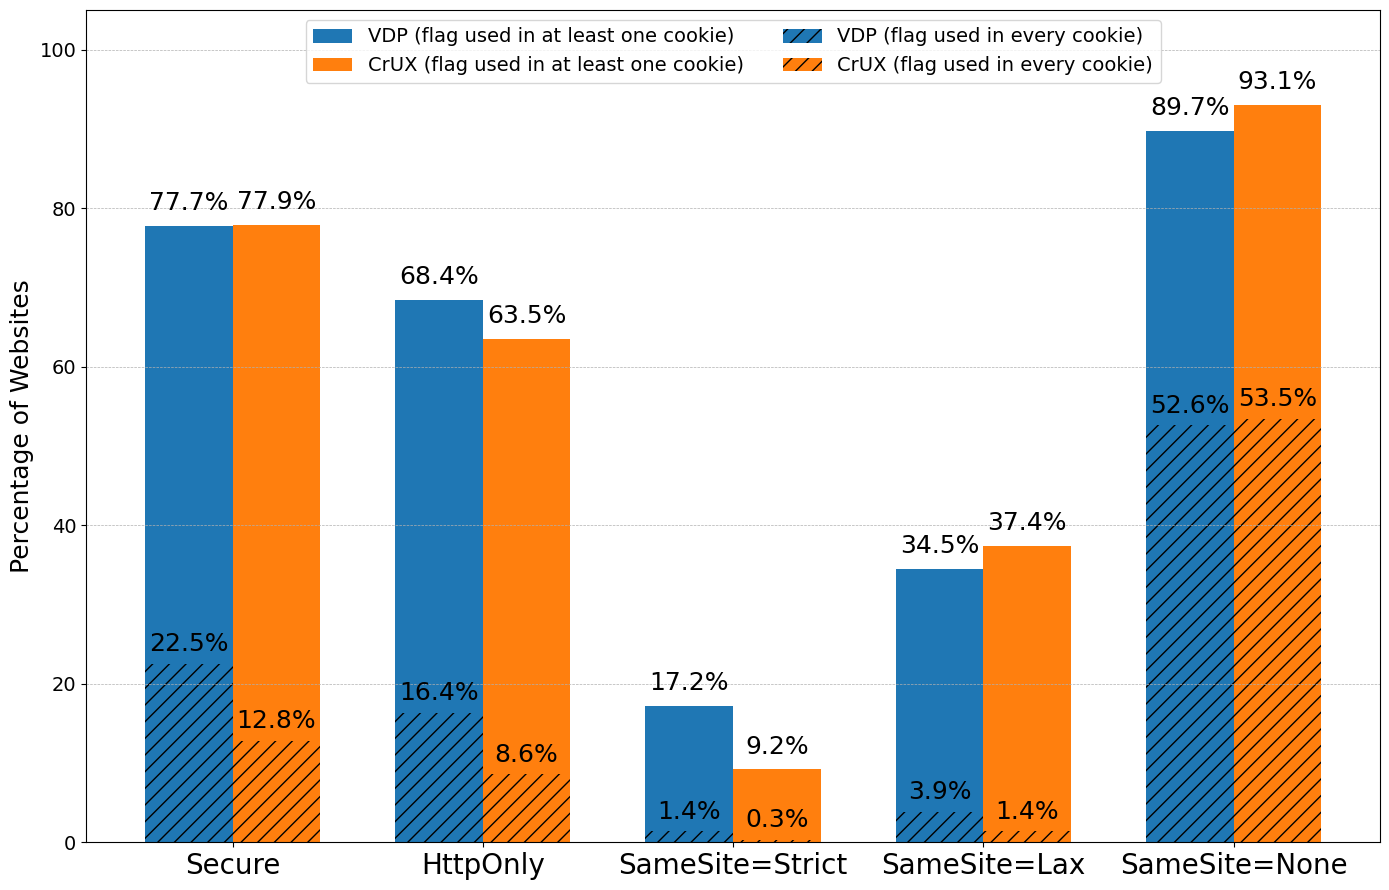

In [2]:
import sqlite3
import pandas as pd
import json
from collections import defaultdict
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import numpy as np

def eval_cookies(source):
    print(f"[*] {source} - Evaluating cookies flags...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    cookie_stats = defaultdict(lambda: defaultdict(int))
    count = 0
    domains_only_secure = 0
    domains_only_httpOnly = 0
    domains_only_sameSite = {"Strict": 0, "Lax": 0, "None": 0}
    domains_with_secure = 0
    domains_with_httpOnly = 0
    domains_with_sameSite = {"Strict": 0, "Lax": 0, "None": 0}

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)

        for _, row in df.iterrows():
            cookies = row['cookies_formated']
            total_cookies_on_page = 0
            if not cookies:
                continue
            count += 1

            all_secure = True
            all_httpOnly = True
            seen_sameSite_values = set()
            sameSite_seen_any = set()
            secure_flagged = False
            httpOnly_flagged = False

            url_host = urlparse(row["url"]).hostname or ""
            site_domain = ".".join(url_host.split(".")[-2:]) if url_host else ""
            third_party_count = 0

            for cookie in cookies:
                total_cookies_on_page += 1
                name = cookie.get('name')
                if not name:
                    continue

                cookie_stats[name]['overall'] += 1

                if cookie.get("secure"):
                    cookie_stats[name]["secure"] += 1
                    secure_flagged = True
                else:
                    all_secure = False

                if cookie.get("httpOnly"):
                    cookie_stats[name]["httpOnly"] += 1
                    httpOnly_flagged = True
                else:
                    all_httpOnly = False

                same_site = cookie.get("sameSite")
                if same_site:
                    key = f"sameSite={same_site}"
                    cookie_stats[name][key] += 1
                    seen_sameSite_values.add(same_site)
                    sameSite_seen_any.add(same_site)

                cookie_domain = cookie.get("domain")
                if cookie_domain and site_domain not in cookie_domain:
                    third_party_count += 1

            cookie_stats['__third_party__']['total_cookies'] += total_cookies_on_page

            if secure_flagged:
                domains_with_secure += 1
            if httpOnly_flagged:
                domains_with_httpOnly += 1
            for value in sameSite_seen_any:
                if value in domains_with_sameSite:
                    domains_with_sameSite[value] += 1

            if all_secure:
                domains_only_secure += 1
            if all_httpOnly:
                domains_only_httpOnly += 1
            if len(seen_sameSite_values) == 1:
                only_value = list(seen_sameSite_values)[0]
                if only_value in domains_only_sameSite:
                    domains_only_sameSite[only_value] += 1

            if third_party_count > 0:
                cookie_stats['__third_party__']['domains_with_any'] += 1
            cookie_stats['__third_party__']['total_third_party_cookies'] += third_party_count

    print(f"\n📊 Flag Usage Summary for {source}:\n")
    print(f"Websites with cookies: {count}")
    print(f"↳ With at least one secure cookie: {domains_with_secure} ({domains_with_secure / count * 100:.2f}%)")
    print(f"↳ ONLY secure cookies: {domains_only_secure} ({domains_only_secure / count * 100:.2f}%)\n")
    print(f"↳ With at least one httpOnly cookie: {domains_with_httpOnly} ({domains_with_httpOnly / count * 100:.2f}%)")
    print(f"↳ ONLY httpOnly cookies: {domains_only_httpOnly} ({domains_only_httpOnly / count * 100:.2f}%)\n")

    print("SameSite (any cookie):")
    for k, v in domains_with_sameSite.items():
        print(f"  ↳ {k}: {v} ({v / count * 100:.2f}%)")

    print("\nSameSite (only that value across all cookies):")
    for k, v in domains_only_sameSite.items():
        print(f"  ↳ {k}: {v} ({v / count * 100:.2f}%)")

    third_party_total = cookie_stats['__third_party__']['total_third_party_cookies']
    total_cookies = cookie_stats['__third_party__']['total_cookies']
    avg_third_party_per_page = third_party_total / count
    percent_third_party = (third_party_total / total_cookies) * 100 if total_cookies > 0 else 0

    print("\n📦 Third-Party Cookie Stats:")
    print(f"↳ Domains with at least one third-party cookie: {cookie_stats['__third_party__']['domains_with_any']}")
    print(f"↳ Total third-party cookies observed: {third_party_total}")
    print(f"↳ Average third-party cookies per website: {avg_third_party_per_page:.2f}")
    print(f"↳ Percentage of all cookies that are third-party: {percent_third_party:.2f}%")

    return cookie_stats

print("----------VDP--------")
cookie_stats_bb = eval_cookies("BB")
print("----------CRUX---------")
cookie_stats_crux = eval_cookies("CRUX")


# ------------- Manuelle Grafik daraus bauen -----------
import matplotlib.pyplot as plt
import numpy as np

# Daten
labels = ['Secure', 'HttpOnly', 'SameSite=Strict', 'SameSite=Lax', 'SameSite=None']
crux_any = [77.90, 63.45, 9.19, 37.42, 93.07]
bb_any = [77.71, 68.43, 17.22, 34.53, 89.74]
crux_only = [12.78, 8.58, 0.29, 1.37, 53.46]
bb_only = [22.54, 16.35, 1.37, 3.85, 52.59]

x = np.arange(len(labels))  # Kategorien
width = 0.35

fig, ax = plt.subplots(figsize=(14, 9))

# Balken: VDP links, CrUX rechts
bar_vdp_any = ax.bar(x - width/2, bb_any, width, label='VDP (flag used in at least one cookie)', color='C0')
bar_crux_any = ax.bar(x + width/2, crux_any, width, label='CrUX (flag used in at least one cookie)', color='C1')

bar_vdp_only = ax.bar(x - width/2, bb_only, width, label='VDP (flag used in every cookie)', color='C0', hatch='//')
bar_crux_only = ax.bar(x + width/2, crux_only, width, label='CrUX (flag used in every cookie)', color='C1', hatch='//')

# Labels oben drauf
for i, (vdp_val, crux_val) in enumerate(zip(bb_any, crux_any)):
    ax.text(x[i] - width/2, vdp_val + 2, f'{vdp_val:.1f}%', ha='center', fontsize=18)
    ax.text(x[i] + width/2, crux_val + 2, f'{crux_val:.1f}%', ha='center', fontsize=18)

# Labels für "only"
for i, (vdp_only, crux_only_val) in enumerate(zip(bb_only, crux_only)):
    ax.text(x[i] - width/2, vdp_only + 4, f'{vdp_only:.1f}%', ha='center', va='top', fontsize=18, color='black')
    ax.text(x[i] + width/2, crux_only_val + 4, f'{crux_only_val:.1f}%', ha='center', va='top', fontsize=18, color='black')

# Achsen & Layout
ax.set_ylabel('Percentage of Websites', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)
ax.set_ylim(0, 105)
ax.legend(loc='upper center', fontsize=14, title_fontsize=18, ncol=2)
ax.grid(axis='y', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=14)
plt.tight_layout()

# Export
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/cookie_flag_comp.pdf', format='pdf', bbox_inches='tight')
plt.show()


[*] BB - Evaluating cookies flags...
Total websites with cookies: 12081

BB - First Party:
secure: 32998 (40.88%)
httpOnly: 15855 (19.64%)
sameSite=Strict: 3150 (3.90%)
sameSite=Lax: 9840 (12.19%)
sameSite=None: 67159 (83.21%)

BB - Third Party:
secure: 26325 (91.26%)
httpOnly: 12529 (43.43%)
sameSite=Strict: 0 (0.00%)
sameSite=Lax: 7 (0.02%)
sameSite=None: 28840 (99.98%)
[*] CRUX - Evaluating cookies flags...
Total websites with cookies: 76039

CRUX - First Party:
secure: 202648 (30.63%)
httpOnly: 69529 (10.51%)
sameSite=Strict: 10765 (1.63%)
sameSite=Lax: 89616 (13.55%)
sameSite=None: 557191 (84.23%)

CRUX - Third Party:
secure: 341200 (90.07%)
httpOnly: 104159 (27.49%)
sameSite=Strict: 3 (0.00%)
sameSite=Lax: 259 (0.07%)
sameSite=None: 378575 (99.93%)


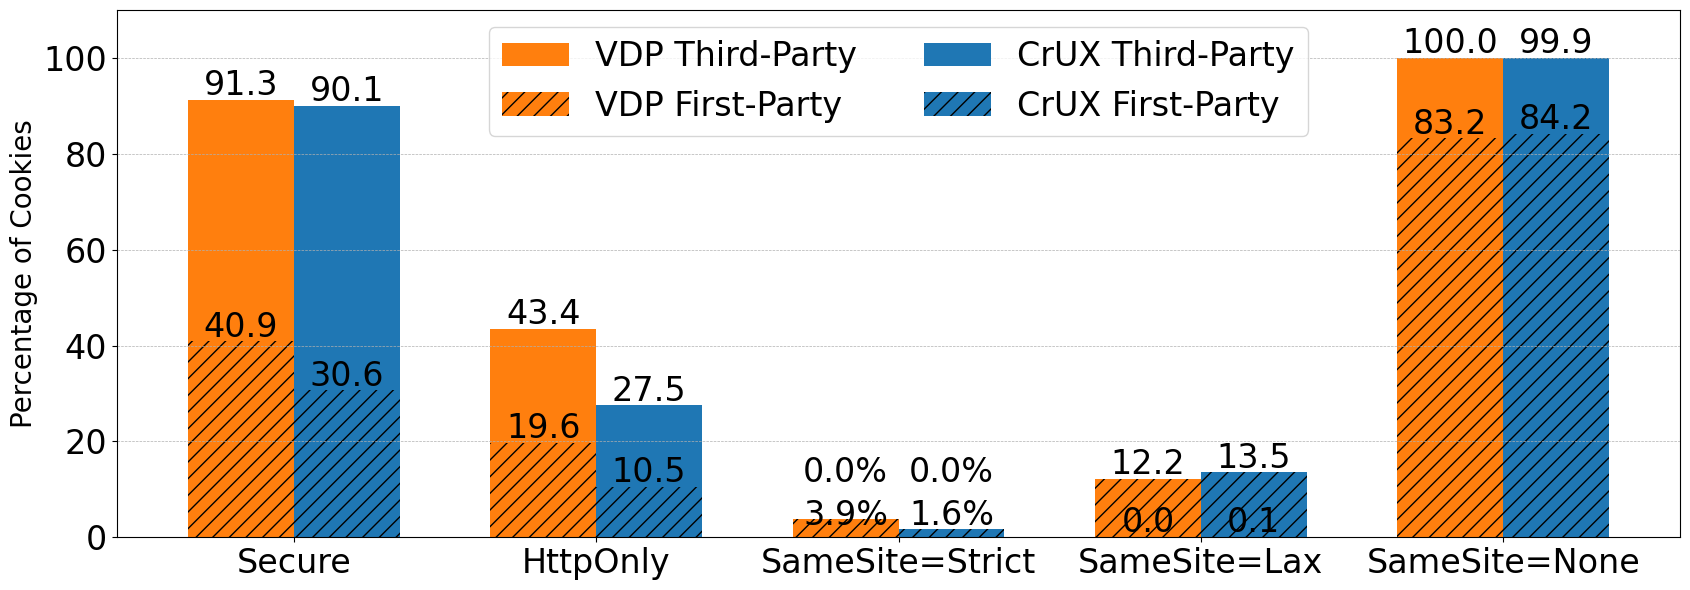

In [16]:
import sqlite3
import pandas as pd
import json
from collections import defaultdict
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import numpy as np

def eval_cookies(source, db_path):
    print(f"[*] {source} - Evaluating cookies flags...")
    query = f"SELECT * FROM urls WHERE cookies IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    flag_stats = {
        'first_party': defaultdict(int),
        'third_party': defaultdict(int),
        'total_first_party': 0,
        'total_third_party': 0
    }

    total_websites = 0

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['cookies_formated'] = df['cookies'].apply(json.loads)

        for _, row in df.iterrows():
            cookies = row['cookies_formated']
            if not cookies:
                continue
            total_websites += 1

            url_host = urlparse(row["url"]).hostname or ""
            site_domain = ".".join(url_host.split(".")[-2:]) if url_host else ""

            for cookie in cookies:
                cookie_domain = cookie.get("domain", "")
                same_site = cookie.get("sameSite", None)
                secure = cookie.get("secure", False)
                http_only = cookie.get("httpOnly", False)

                is_third_party = site_domain not in cookie_domain if cookie_domain else False
                party = 'third_party' if is_third_party else 'first_party'

                if secure:
                    flag_stats[party]['secure'] += 1
                if http_only:
                    flag_stats[party]['httpOnly'] += 1
                if same_site:
                    flag_stats[party][f'sameSite={same_site}'] += 1

                if is_third_party:
                    flag_stats['total_third_party'] += 1
                else:
                    flag_stats['total_first_party'] += 1

    conn.close()

    print(f"Total websites with cookies: {total_websites}")
    for party in ['first_party', 'third_party']:
        print(f"\n{source} - {party.replace('_', ' ').title()}:")
        total = flag_stats[f"total_{party}"]
        for flag in ['secure', 'httpOnly', 'sameSite=Strict', 'sameSite=Lax', 'sameSite=None']:
            value = flag_stats[party][flag]
            percent = (value / total * 100) if total else 0
            print(f"{flag}: {value} ({percent:.2f}%)")

    return {
        'source': source,
        'first_party': flag_stats['first_party'],
        'third_party': flag_stats['third_party'],
        'total_first_party': flag_stats['total_first_party'],
        'total_third_party': flag_stats['total_third_party'],
    }

# Evaluation
db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
cookie_stats_bb = eval_cookies("BB", db_path)
cookie_stats_crux = eval_cookies("CRUX", db_path)

# Plot preparation
labels = ['secure', 'httpOnly', 'sameSite=Strict', 'sameSite=Lax', 'sameSite=None']
x = np.arange(len(labels))
width = 0.35

def extract_percentages(stats, total_key):
    return [(stats.get(label, 0) / total_key * 100) if total_key else 0 for label in labels]

vdp_fp = extract_percentages(cookie_stats_bb['first_party'], cookie_stats_bb['total_first_party'])
vdp_tp = extract_percentages(cookie_stats_bb['third_party'], cookie_stats_bb['total_third_party'])
crux_fp = extract_percentages(cookie_stats_crux['first_party'], cookie_stats_crux['total_first_party'])
crux_tp = extract_percentages(cookie_stats_crux['third_party'], cookie_stats_crux['total_third_party'])

# Plotting
fig, ax = plt.subplots(figsize=(17, 6))
width = 0.35

# Balken für VDP (gleicher x-Wert, leicht versetzt)
bar_vdp_tp = ax.bar(x - width/2, vdp_tp, width, label='VDP Third-Party', color='C1')
bar_vdp_fp = ax.bar(x - width/2, vdp_fp, width, label='VDP First-Party', color='C1', hatch='//')

# Balken für CrUX
bar_crux_tp = ax.bar(x + width/2, crux_tp, width, label='CrUX Third-Party', color='C0')
bar_crux_fp = ax.bar(x + width/2, crux_fp, width, label='CrUX First-Party', color='C0', hatch='//')

# Prozentwerte für VDP
for i in range(len(x)):
    if i == 2:
        ax.text(x[i] - width/2, vdp_tp[i] + 10, f'{vdp_tp[i]:.1f}%', ha='center', va='bottom', fontsize=24, color='black')
        ax.text(x[i] - width/2, vdp_tp[i] + 1, f'{vdp_fp[i]:.1f}%', ha='center', va='bottom', fontsize=24, color='black')
    else:
        ax.text(x[i] - width/2, vdp_tp[i] + 1, f'{vdp_tp[i]:.1f}', ha='center', fontsize=24, color='black')
        ax.text(x[i] - width/2, vdp_fp[i] + 1, f'{vdp_fp[i]:.1f}', ha='center', fontsize=24, color='black')

# Prozentwerte für CrUX
for i in range(len(x)):
    if i == 2:
        ax.text(x[i] + width/2, crux_tp[i] + 10, f'{crux_tp[i]:.1f}%', ha='center', va='bottom', fontsize=24, color='black')
        ax.text(x[i] + width/2, crux_tp[i] + 1, f'{crux_fp[i]:.1f}%', ha='center', va='bottom', fontsize=24, color='black')
    else:
        ax.text(x[i] + width/2, crux_tp[i] + 1, f'{crux_tp[i]:.1f}', ha='center', fontsize=24, color='black')
        ax.text(x[i] + width/2, crux_fp[i] + 1, f'{crux_fp[i]:.1f}', ha='center', fontsize=24, color='black')

# Achsen & Design
ax.set_ylabel('Percentage of Cookies', fontsize=20)
ax.set_xticks(x)
plt.xticks(fontsize=36)
ax.set_xticklabels(['Secure', 'HttpOnly', 'SameSite=Strict', 'SameSite=Lax', 'SameSite=None'], fontsize=24)
ax.set_ylim(0, 110)
ax.legend(loc='upper center', fontsize=24, title_fontsize=26, ncol=2)
ax.grid(axis='y', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/cookie_flag_comp_3rd.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Results - Included Third-Party Libraries

In [ ]:
import statistics
import sqlite3
import pandas as pd
from collections import Counter
import json
import re

# Analysis of Included Scripts

def eval_includedScripts(source):
    print(f"[*] {source} Analysis of Included Scripts...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE included_scripts IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    count_succ = 0
    count_fail = 0

    error_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['included_scripts_formated'] = df['included_scripts'].apply(json.loads)
        for includes_website in df["included_scripts_formated"]:
            try:

                if len(includes_website) == 1:
                    if isinstance(includes_website[0], str):
                        count_succ += 1
                        continue

                    err = includes_website[0]['error']
                    if "Execution context was destroyed" in err:
                            error_counter["Invalid Certificate"] += 1
                            count_fail += 1

                    elif "Timeout" in err:
                        error_counter["Timeout"] += 1
                        count_fail += 1

                    elif "Execution context was destroyed" in err:
                            error_counter["ERR_CERT_DATE_INVALID"] += 1

                    elif "Timeout" in err:
                        error_counter["Timeout"] += 1

                    elif "Seemingly Unwanted Redirection occurend" in err:
                        error_counter["Redirection"] += 1

                    elif 'Redirection' in err:
                        error_counter["Redirection"] += 1

                    elif "Download is starting" in err:
                        error_counter["Downloading File"] += 1
                        
                    elif True:
                        print(err)

                else:
                    count_succ += 1

                            
            except Exception as e:
                print(e)
                count_succ += 1


    print(f" [!] {source} - ERRORS:")    
    for key, num in error_counter.items():
        print(f"  - {key} : {num}")

    print(f"[*] {source} - Webpages for which at least one included script was stored:' - {count_succ}")
    print(f"[*] {source} - Webpages for which no included script was stored:' - {count_fail}")
    print(f' [*]  --> Error Rate: {count_fail/(count_succ + count_fail)*100}%')
    print()

eval_includedScripts("BB")
print("---------")
eval_includedScripts("CRUX")

[*] BB Analysis of Included Scripts...
Exception: Page.goto: NS_ERROR_REDIRECT_LOOP
Call log:
navigating to "http://www.squareup.com/", waiting until "load"

Exception: Page.goto: NS_ERROR_NET_TIMEOUT
Call log:
navigating to "https://www.starbucks.com.cn/help/", waiting until "load"

Exception: Page.goto: NS_ERROR_PROXY_BAD_GATEWAY
Call log:
navigating to "https://playwonderbox.com.br/hct-privacy-policy", waiting until "load"

Exception: Page.goto: NS_ERROR_PROXY_BAD_GATEWAY
Call log:
navigating to "https://playwonderbox.com.br/en-us", waiting until "load"

Exception: Page.goto: NS_ERROR_PROXY_BAD_GATEWAY
Call log:
navigating to "https://playwonderbox.com.br/general-privacy-policy", waiting until "load"

Exception: Page.goto: NS_ERROR_PROXY_BAD_GATEWAY
Call log:
navigating to "https://playwonderbox.com.br/privacy-policy", waiting until "load"

Exception: Page.goto: NS_ERROR_PROXY_BAD_GATEWAY
Call log:
navigating to "https://euleioparaumacrianca.com.br/", waiting until "load"

Exception

In [ ]:
# Based on Disconnetme list

import tldextract
import statistics
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas as pd
from collections import Counter
import json

def load_tracking_services(filename):
    """Load and parse the services JSON, returning a domain-to-service mapping."""
    try:
        with open(filename, 'r') as f:
            data = json.load(f)  # Load JSON data into a dict
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return None
    except json.JSONDecodeError:
        print(f"Error: File '{filename}' contains invalid JSON.")
        return None

    if 'categories' not in data or not isinstance(data['categories'], dict):
        print("Error: JSON format is incorrect (missing 'categories').")
        return None

    services_map = {}
    
    # Traverse each category and its list of services
    for category, services in data['categories'].items():
        if not isinstance(services, list):
            continue  # skip if category value is not a list as expected
        for service_entry in services:
            if not isinstance(service_entry, dict):
                continue  # skip malformed service entries
            for service_name, site_info in service_entry.items():
                if not isinstance(site_info, dict):
                    continue
                # Each site_info has an official URL as key and a list of domains as value
                for site, domains in site_info.items():
                    if not isinstance(domains, list):
                        continue
                    for domain in domains:
                        key = domain.lower()

                        # Ensure each domain maps to a list of categories/services
                        if key not in services_map:
                            services_map[key] = {
                                "category": [category],
                                "service": [service_name]
                            }
                        else:
                            services_map[key]['category'].append(category)
                            services_map[key]['service'].append(service_name)
    
    return services_map

def externalScriptsSources(source):
    services_map = load_tracking_services(f'{BASE_DIR}/data/services.json')
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE included_scripts IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500
    number_inclusions = []
    number_external_inclusions = []
    included_domains = Counter()
    overall_count = 0
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['included_scripts_formated'] = df['included_scripts'].apply(json.loads)
        for _, row in df.iterrows():
            external_includes = []
            inclusions = row['included_scripts_formated']
            if len(inclusions) == 1:
                if not isinstance(inclusions[0], str):
                    external_includes = None
                    continue
            # Number of inclusions
            number_inclusions.append(len(inclusions))
            overall_count += 1
            # Extract domains from inclusions
            base_domain = tldextract.extract(row['url']).domain
            for included_url in inclusions:
                if isinstance(included_url, str): 
                    extracted_domain = tldextract.extract(included_url).domain
                    extracted_domain_suffix = tldextract.extract(included_url).suffix
                    extracted_domain = f'{extracted_domain}.{extracted_domain_suffix}' 
                else:
                    # Error
                    continue
                
                if base_domain != extracted_domain and extracted_domain is not None:
                    external_includes.append(extracted_domain)
                    
            if external_includes is not None and "error" not in external_includes:
                number_external_inclusions.append(len(external_includes))

            for domain in set(external_includes):
                included_domains[domain] += 1



    included_domains_overall = sorted(included_domains.items(), key=lambda item: item[1], reverse=True)
    included_domains = included_domains_overall[:15]
    print(f" [*] {source} - External Domains Included:")
    for x, y in included_domains:
        if x in services_map:
            info = services_map[x]
            category = info["category"]
            print(f"    -{ x}: {y}  -- {category}")

        else:
            print(f"    -{ x}: {y}")

    '''
    # Print the domains included
    domains = [x for x, y in included_domains]
    counts = [y for x, y in included_domains]
    plt.figure(figsize=(10, 6))
    plt.barh(domains, counts, color='skyblue')
    plt.xlabel('Count')
    plt.ylabel('Domains')
    plt.title(f'{source} - Top 15 Included Domains by Count')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    '''
    
    average_count_ov = sum(number_inclusions) / len(number_inclusions) if number_inclusions else 0 
    median_count_ov = statistics.median(number_inclusions) if number_inclusions else 0
    print(f" [*] {source} - Average Number of Loaded scripts: {average_count_ov}")
    print(f" [*] {source} - Median Number of Loaded scripts: {median_count_ov}")

    average_count_ext = sum(number_external_inclusions) / len(number_external_inclusions) if number_external_inclusions else 0 
    median_count_ext = statistics.median(number_external_inclusions) if number_external_inclusions else 0
    print(f" [*] {source} - Average Number of External Loaded scripts: {average_count_ext}")
    print(f" [*] {source} - Median Number of External Loaded scripts: {median_count_ext}")

    categories = ["Overall", "External"]
    average_values = [average_count_ov, average_count_ext]
    median_values = [median_count_ov, median_count_ext]

    '''
    x = np.arange(len(categories)) 
    width = 0.4 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width / 2, average_values, width, label="Average", color="blue")
    ax.bar(x + width / 2, median_values, width, label="Median", color="orange")
    ax.set_title(f"{source} - Script Inclusion Metrics (Overall vs External)")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    plt.show()
    '''

    return included_domains_overall, overall_count


bb_data = externalScriptsSources("BB")
print("---------")
crux_data = externalScriptsSources("CRUX")


overall_percentages = {
    "BB": {},
    "CRUX": {}
}

for source, count in bb_data[0]:
    # calculate persecntages 
    overall_percentages["BB"][source] = count / bb_data[1] * 100

for source, count in crux_data[0]:
    # calculate persecntages 
    overall_percentages["CRUX"][source] = count / crux_data[1] * 100

all_sources = set(overall_percentages["BB"].keys()).union(set(overall_percentages["CRUX"].keys()))

# Sort sources by total percentage (sum of both datasets)
sorted_sources = sorted(
    all_sources, 
    key=lambda x: overall_percentages["BB"].get(x, 0) + overall_percentages["CRUX"].get(x, 0), 
    reverse=True
)

sorted_sources = sorted_sources[:25]

# Extract data for plotting
values_BB = [overall_percentages["BB"].get(src, 0) for src in sorted_sources]
values_CRUX = [overall_percentages["CRUX"].get(src, 0) for src in sorted_sources]

 [*] BB - External Domains Included:
    -googletagmanager.com: 7113
    -cookielaw.org: 3117  -- ['ConsentManagers']
    -google-analytics.com: 2304  -- ['Email', 'Analytics', 'FingerprintingGeneral']
    -facebook.net: 1875  -- ['FingerprintingGeneral', 'Social']
    -google.com: 1690  -- ['Content']
    -gstatic.com: 1219  -- ['Content']
    -jsdelivr.net: 1173
    -cloudflare.com: 900  -- ['Content']
    -licdn.com: 891  -- ['Social']
    -googleapis.com: 871  -- ['Content']
    -bing.com: 858  -- ['Content']
    -adobedtm.com: 852
    -doubleclick.net: 767  -- ['Email', 'Advertising', 'FingerprintingGeneral']
    -cloudfront.net: 752  -- ['Content']
    -newrelic.com: 703  -- ['Analytics']
 [*] BB - Average Number of Loaded scripts: 11.961608641704984
 [*] BB - Median Number of Loaded scripts: 6
 [*] BB - Average Number of External Loaded scripts: 11.961608641704984
 [*] BB - Median Number of External Loaded scripts: 6
---------
 [*] CRUX - External Domains Included:
    -googleta

Top 25 BB Sources:
googletagmanager.com: 51.92%
cookielaw.org: 22.75% -- ['ConsentManagers']
google-analytics.com: 16.82% -- ['Email', 'Analytics', 'FingerprintingGeneral']
facebook.net: 13.69% -- ['FingerprintingGeneral', 'Social']
google.com: 12.33% -- ['Content']
gstatic.com: 8.90% -- ['Content']
jsdelivr.net: 8.56%
cloudflare.com: 6.57% -- ['Content']
licdn.com: 6.50% -- ['Social']
googleapis.com: 6.36% -- ['Content']
bing.com: 6.26% -- ['Content']
adobedtm.com: 6.22%
doubleclick.net: 5.60% -- ['Email', 'Advertising', 'FingerprintingGeneral']
cloudfront.net: 5.49% -- ['Content']
newrelic.com: 5.13% -- ['Analytics']
hotjar.com: 4.47% -- ['Analytics']
jquery.com: 3.82%
clarity.ms: 3.65% -- ['Analytics']
tiqcdn.com: 3.55%
ads-twitter.com: 3.48% -- ['Advertising']
youtube.com: 3.46% -- ['Content']
cquotient.com: 3.36% -- ['Analytics']
igodigital.com: 3.21% -- ['Analytics']
srovname.cz: 3.12%
kk-resources.com: 3.12%

Top 25 CRUX Sources:
google.com: 27.17% -- ['Content']
doubleclick.net

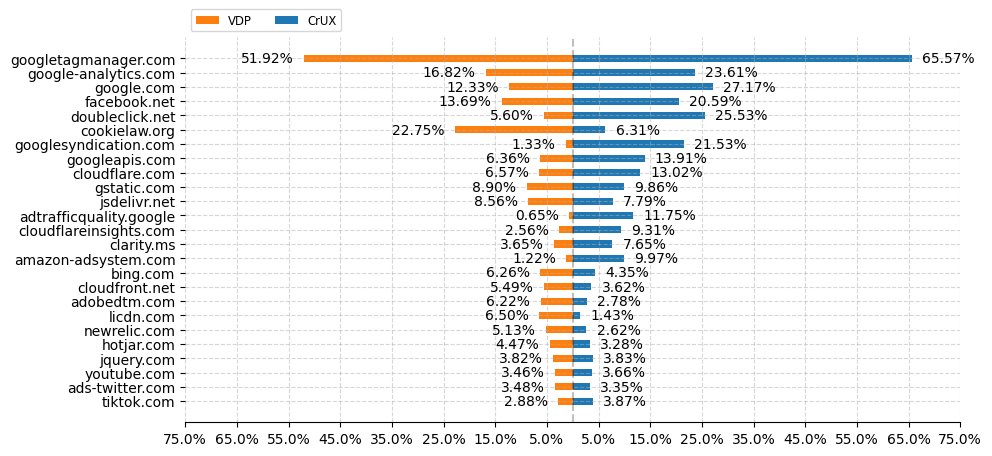

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PERCENTAGES CALCULATED

services_map = load_tracking_services(f'{BASE_DIR}/data/services.json')

top_10_bb = sorted(overall_percentages["BB"].items(), key=lambda x: x[1], reverse=True)[:25]
print("Top 25 BB Sources:")
for source, percentage in top_10_bb:
    if source in services_map:
            info = services_map[source]
            category = info["category"]
            print(f"{source}: {percentage:.2f}% -- {category}")
    else:
        print(f"{source}: {percentage:.2f}%")

# Sort and print the top 10 sources by percentage for CRUX
top_10_crux = sorted(overall_percentages["CRUX"].items(), key=lambda x: x[1], reverse=True)[:25]
print("\nTop 25 CRUX Sources:")
for source, percentage in top_10_crux:
    if source in services_map:
                info = services_map[source]
                category = info["category"]
                print(f"{source}: {percentage:.2f}% -- {category}")
                
def create_plot(results, category_names):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*. The order is assumed
        to be from 'Vulnerability Disclosure Programs' to 'CrUX'.
    category_names : list of str
        The category labels.
    """
    
    labels = list(results.keys())  # Extract question labels
    data = np.array(list(results.values()))  # Convert answers into a numpy array
     
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot Bars for Vulnerability Disclosure Programs (left side, negative)
    ax.barh(labels, -data[:, 0], height=0.5, label=category_names[0], color='C1')
    
    # Plot Bars for CrUX (right side, positive)
    ax.barh(labels, data[:, 1], height=0.5, label=category_names[1], color='C0')
    
    # Add Zero Reference Line
    ax.axvline(0, linestyle='--', color='black', alpha=.25)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # X Axis Configuration
    ax.set_xlim(-75, 75)  # Set the x-axis limits
    ax.set_xticks(np.arange(-75, 76, 10))  # Set ticks at 10% intervals
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{abs(x):.1f}%" if x != 0 else "0%"))
    
    # Y Axis Configuration
    ax.invert_yaxis()  # Invert y-axis so the topmost label is at the top
    
    # Remove unnecessary spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add Legend
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
              loc='lower left', fontsize='small')
    
    # Set Background Color
    fig.set_facecolor('#FFFFFF')

    # Add Percentages Before and After the Bars (Floating-point)
    for i, label in enumerate(labels):
        # Calculate the percentage for BB (negative side)
        bb_percentage = data[i, 0]
        crux_percentage = data[i, 1]
        
        # Adding the text before and after the bars with float formatting
        ax.text(-bb_percentage - 2, i, f'{bb_percentage:.2f}%', va='center', ha='right', fontsize=10, color='black')
        ax.text(crux_percentage + 2, i, f'{crux_percentage:.2f}%', va='center', ha='left', fontsize=10, color='black')


    return fig, ax


# Prepare the survey data
grouped_array = {}
cats = []

# Assuming `overall_percentages` and `sorted_sources` are already defined
values_BB = [overall_percentages["BB"].get(src, 0) for src in sorted_sources]
values_CRUX = [overall_percentages["CRUX"].get(src, 0) for src in sorted_sources]

# Loop through each source and its corresponding values in BB and CRUX
for src, bb_value, crux_value in zip(sorted_sources, values_BB, values_CRUX):
    grouped_array[src] = [bb_value, crux_value]
    cats.append(src)

# Generate the plot
fig, ax = create_plot(grouped_array, ['VDP', 'CrUX'])
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/inlcudes_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
import re
import sqlite3
import pandas as pd
import json
from collections import defaultdict, Counter
from urllib.parse import urlparse
import tldextract
from concurrent.futures import ThreadPoolExecutor
from adblockparser import AdblockRules


# Easylist -> Mainly advertisments 
ad_list_path = f'{BASE_DIR}/data/easylist.txt'
ad_list = []
rules_easy = [] 
with open(ad_list_path, 'r') as file:
    for line in file:
        rules_easy.append(line)
        cleaned_line = line.strip()
        if cleaned_line:
            ad_list.append(cleaned_line)

print(f'[*] Read {len(ad_list)} paths from Easylist!')
rules_easy_test = AdblockRules(rules_easy)

# EasyPrivacy -> Mainly trackers
tracker_list_path = f'{BASE_DIR}/data/easyprivacy.txt'
tracker_list = []
rules_privacy = []
with open(tracker_list_path, 'r') as file:
    for line in file:
        rules_privacy.append(line)
        cleaned_line = line.strip()
        if cleaned_line:
            tracker_list.append(cleaned_line)
print(f'[*] Read {len(tracker_list)} paths from EasyPrivacy!')
rules_easy_test_privacy = AdblockRules(rules_privacy)

def check_url_match(url, rules):
    """Check a given URL against a list of patterns."""
    return rules.should_block(url)

def externalScriptsSourcesEasyList(current_list, list_type, source):
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE included_scripts IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500
    number_inclusions = []
    number_external_inclusions = []
    included_urls = Counter()
    overall_count = 0
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['included_scripts_formated'] = df['included_scripts'].apply(json.loads)
        for _, row in df.iterrows():
            external_includes = []
            inclusions = row['included_scripts_formated']
            if len(inclusions) == 1:
                if not isinstance(inclusions[0], str):
                    external_includes = None
                    continue
            # Number of inclusions
            number_inclusions.append(len(inclusions))
            overall_count += 1
            # Extract domains from inclusions
            base_domain = tldextract.extract(row['url']).domain
            for included_url in inclusions:
                if isinstance(included_url, str): 
                    external_includes.append(included_url)
                else:
                    # Error
                    continue
                
            if external_includes is not None and "error" not in external_includes:
                number_external_inclusions.append(len(external_includes))

            for url in set(external_includes):
                included_urls[url] += 1



    included_urls_overall = sorted(included_urls.items(), key=lambda item: item[1], reverse=True)
    included_urls = included_urls_overall[:25]

    print(f" [*] {source} - External Domains Included:")
    for x, y in included_urls:
        block = False
        if list_type == "Advertisment":
            block = rules_easy_test.should_block(x)
        if list_type == "Tracking": 
            block = rules_easy_test_privacy.should_block(x)
        
        if block:
            print(f"    -{ x}: {y} - {list_type} - {block}")
        else:
            print(f"    -{ x}: {y} - No match")
            pass


print("-------BB------")
externalScriptsSourcesEasyList(ad_list, "Advertisment",  "BB")
externalScriptsSourcesEasyList(tracker_list, "Tracking", "BB")
print()
print()
print("-------CRUX------")
externalScriptsSourcesEasyList(ad_list, "Advertisment", "CRUX")
externalScriptsSourcesEasyList(tracker_list, "Tracking", "CRUX")

[*] Read 63379 paths from Easylist!
[*] Read 53856 paths from EasyPrivacy!
-------BB------
 [*] BB - External Domains Included:
    -https://cdn.cookielaw.org/scripttemplates/otSDKStub.js: 2879 - No match
    -https://www.google-analytics.com/analytics.js: 2140 - No match
    -https://connect.facebook.net/en_US/fbevents.js: 1658 - No match
    -https://www.gstatic.com/recaptcha/releases/J79K9xgfxwT6Syzx-UyWdD89/recaptcha__en.js: 1094 - No match
    -https://snap.licdn.com/li.lms-analytics/insight.min.js: 880 - No match
    -https://bat.bing.com/bat.js: 827 - No match
    -https://script.hotjar.com/modules.ef5986d046c68a8c77c1.js: 565 - No match
    -https://www.clarity.ms/s/0.8.0/clarity.js: 474 - No match
    -https://cdn.cquotient.com/js/v2/gretel.min.js: 461 - No match
    -https://s.kk-resources.com/leadtag.js: 428 - No match
    -https://tracking.srovname.cz/srovnamepixel-gtm.js: 428 - No match
    -https://cdn.jsdelivr.net/gh/TimeOne-Group/isdk@latest/dist/isdk.min.js: 428 - No m

## Results - Third-Party Libraries Vulnerabilities

In [4]:
import tldextract
from scipy.stats import chi2_contingency

def extract_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.subdomain}.{ext.domain}.{ext.suffix}" if ext.subdomain else f"{ext.domain}.{ext.suffix}"

def analyze_3rd_Vuln(source):
    print(f"[*] Starting Analysis of Retire.js results for {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE retirejs IS NOT NULL and source='{source}'" 
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    severity_rank = {
        'low': 1,
        'medium': 2,
        'high': 3,
        'critical': 4
    }

    count_fail = 0

    vuln_code = Counter()
    vuln_code_vers = Counter()
    error_counter = Counter()
    websites_with_vulns = set()
    domains_with_vulns = set()
    overall_websites_set = set()
    overall_domains_set = set()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_retire'] = df['retirejs'].apply(json.loads)
        df['domain'] = df['url'].apply(extract_domain)
        for _, row in df.iterrows():
            skip = False
            for entry in row['formatted_retire']:
                if 'error' in entry.keys():
                    count_fail = count_fail + 1
                    skip = True
            
            if skip:
                continue

            overall_websites_set.add(row['url'])
            overall_domains_set.add(row['domain'])

            for entry in row['formatted_retire']:
                cves = []
                if "scanned" in entry.keys():
                    # just the scan timestamp
                    continue
                else:
                    websites_with_vulns.add(row['url'])
                    domains_with_vulns.add(row['domain'])
                    # these are the libs with known vulns
                    key = list(entry.keys())[0]
                    lib = key.split(" - ")[0]
                    vuln_code[lib] += 1

                    # individual vulns
                    severities = []
                    for vuln in entry[key]:
                        severities.append(vuln['severity'])
                        if 'CVE' in vuln['identifiers'].keys():
                            cves.append(vuln['identifiers']['CVE'])
                        

                    max_sev = max(severities, key=lambda x: severity_rank[x])
                    vuln_code_vers[f'{key}-{max_sev}-{cves}'] += 1
    

    sorted_vuln_code = sorted(vuln_code.items(), key=lambda item: item[1], reverse=True)
    lib = [] 
    count = []
    print("Most often observed vulnerable libararies:")
    for key, num in sorted_vuln_code[:20]:
        print(f"  - {key} : {num}")
        lib.append(key)
        count.append(num)

    sorted_vuln_code_vers = sorted(vuln_code_vers.items(), key=lambda item: item[1], reverse=True)
    lib2 = [] 
    count2 = []
    print("Most often observed vulnerable libarary-versions:")
    for key, num in sorted_vuln_code_vers[:20]:
        print(f"  - {key} : {num}")
        lib2.append(key)
        count2.append(num)

    
        
    print(f'[*] {source} - RetireJS reported at least one known vulnerability on {len(websites_with_vulns)}/{len(overall_websites_set)} webpages - {len(websites_with_vulns) / len(overall_websites_set) * 100}%')
    print(f'[*] {source} - RetireJS reported at least one known vulnerability on {len(domains_with_vulns)}/{len(overall_domains_set)} domains - {len(domains_with_vulns) / len(overall_domains_set) * 100}%')

    return [{'lib': lib, 'count': count}, {'lib': lib2, 'count': count2}, vuln_code, vuln_code_vers]


data_bb = analyze_3rd_Vuln("BB")
data_crux = analyze_3rd_Vuln("CRUX")

# 0 -> lib only , 1 -> lib and version (and max vuln)
df_bb = pd.DataFrame(data_bb[0])
df_crux = pd.DataFrame(data_crux[0])

contingency_table = pd.DataFrame({
    'BB': df_bb.set_index('lib')['count'],
    'CRUX': df_crux.set_index('lib')['count']
}).fillna(0)  # Fülle fehlende Werte mit 0

# Führe den Chi-Quadrat-Test durch
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Chi2-Statistik: {chi2}")
print(f"P-Wert: {p}")
print(f"Freiheitsgrade: {dof}")
print("Erwartete Häufigkeiten:")
print(ex)

[*] Starting Analysis of Retire.js results for BB...
Most often observed vulnerable libararies:
  - jquery : 464
  - DOMPurify : 300
  - bootstrap : 141
  - jquery-ui : 120
  - axios : 117
  - nextjs : 93
  - jquery-validation : 92
  - ua-parser-js : 91
  - vue : 86
  - moment.js : 84
  - angularjs : 25
  - jquery-migrate : 20
  - lodash : 14
  - handlebars : 13
  - YUI : 8
  - select2 : 7
  - easyXDM : 7
  - tinyMCE : 6
  - jquery-mobile : 6
  - underscore.js : 6
Most often observed vulnerable libarary-versions:
  - DOMPurify - 2.4.0-high-[['CVE-2024-48910'], ['CVE-2024-47875'], ['CVE-2024-45801']] : 165
  - jquery - 2.2.4-medium-[['CVE-2015-9251'], ['CVE-2019-11358'], ['CVE-2020-11023'], ['CVE-2020-11022']] : 70
  - jquery-ui - 1.12.1-medium-[['CVE-2021-41182'], ['CVE-2021-41184'], ['CVE-2021-41183'], ['CVE-2022-31160']] : 63
  - jquery - 1.12.4-medium-[['CVE-2015-9251'], ['CVE-2019-11358'], ['CVE-2020-11023'], ['CVE-2020-11022']] : 50
  - vue - 2.7.16-low-[['CVE-2024-9506']] : 46
  

[*] Starting Analysis of Retire.js results for BB...
Most often observed vulnerable libararies:
  - jquery : 464
  - DOMPurify : 300
  - bootstrap : 141
  - jquery-ui : 120
  - axios : 117
  - nextjs : 93
  - jquery-validation : 92
  - ua-parser-js : 91
  - vue : 86
  - moment.js : 84
  - angularjs : 25
  - jquery-migrate : 20
  - lodash : 14
  - handlebars : 13
  - YUI : 8
  - select2 : 7
  - easyXDM : 7
  - tinyMCE : 6
  - jquery-mobile : 6
  - underscore.js : 6
  - ember : 5
  - knockout : 5
  - dojo : 4
  - chart.js : 3
  - ckeditor : 3
  - jszip : 3
  - bootstrap-select : 2
  - jquery.datatables : 2
  - @angular/core : 2
  - ckeditor5 : 2
  - react : 1
  - prototypejs : 1
  - mustache.js : 1
Most often observed vulnerable libarary-versions:
  - DOMPurify - 2.4.0- high : 165
  - jquery - 2.2.4- medium : 70
  - jquery-ui - 1.12.1- medium : 63
  - jquery - 1.12.4- medium : 50
  - vue - 2.7.16- low : 46
  - ua-parser-js - 0.7.21- high : 37
  - jquery - 3.2.1- medium : 35
  - bootstrap

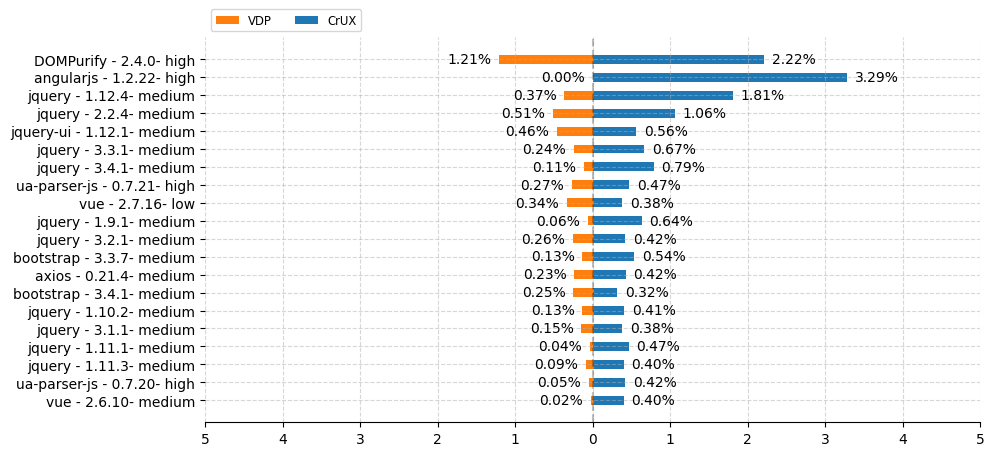

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import tldextract
import statistics
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas as pd
from collections import Counter
import json

def extract_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.subdomain}.{ext.domain}.{ext.suffix}" if ext.subdomain else f"{ext.domain}.{ext.suffix}"

def analyze_3rd_Vuln_for_plot(source):
    print(f"[*] Starting Analysis of Retire.js results for {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE retirejs IS NOT NULL and source='{source}'" 
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    severity_rank = {
        'low': 1,
        'medium': 2,
        'high': 3,
        'critical': 4
    }

    count_fail = 0

    vuln_code = Counter()
    vuln_code_vers = Counter()
    error_counter = Counter()
    websites_with_vulns = set()
    domains_with_vulns = set()
    overall_websites_set = set()
    overall_domains_set = set()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_retire'] = df['retirejs'].apply(json.loads)
        df['domain'] = df['url'].apply(extract_domain)
        for _, row in df.iterrows():
            skip = False
            for entry in row['formatted_retire']:
                if 'error' in entry.keys():
                    count_fail = count_fail + 1
                    skip = True
            
            if skip:
                continue

            overall_websites_set.add(row['url'])
            overall_domains_set.add(row['domain'])

            for entry in row['formatted_retire']:
                cves = []
                if "scanned" in entry.keys():
                    # just the scan timestamp
                    continue
                else:
                    websites_with_vulns.add(row['url'])
                    domains_with_vulns.add(row['domain'])
                    # these are the libs with known vulns
                    key = list(entry.keys())[0]
                    lib = key.split(" - ")[0]
                    vuln_code[lib] += 1

                    # individual vulns
                    severities = []
                    for vuln in entry[key]:
                        severities.append(vuln['severity'])
                        if 'CVE' in vuln['identifiers'].keys():
                            cves.append(vuln['identifiers']['CVE'])
                        

                    max_sev = max(severities, key=lambda x: severity_rank[x])
                    vuln_code_vers[f'{key}- {max_sev}'] += 1
    

    sorted_vuln_code = sorted(vuln_code.items(), key=lambda item: item[1], reverse=True)
    lib = [] 
    count = []
    print("Most often observed vulnerable libararies:")
    for key, num in sorted_vuln_code:
        print(f"  - {key} : {num}")
        lib.append(key)
        count.append(num)

    sorted_vuln_code_vers = sorted(vuln_code_vers.items(), key=lambda item: item[1], reverse=True)
    lib2 = [] 
    count2 = []
    print("Most often observed vulnerable libarary-versions:")
    for key, num in sorted_vuln_code_vers:
        print(f"  - {key} : {num}")
        lib2.append(key)
        count2.append(num)

    
        
    print(f'[*] {source} - RetireJS reported at least one known vulnerability on {len(websites_with_vulns)}/{len(overall_websites_set)} webpages - {len(websites_with_vulns) / len(overall_websites_set) * 100}%')
    print(f'[*] {source} - RetireJS reported at least one known vulnerability on {len(domains_with_vulns)}/{len(overall_domains_set)} domains - {len(domains_with_vulns) / len(overall_domains_set) * 100}%')

    return [{'lib': lib, 'count': count}, {'lib': lib2, 'count': count2}, vuln_code, vuln_code_vers]


def create_plot(results, category_names):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*. The order is assumed
        to be from 'Vulnerability Disclosure Programs' to 'CrUX'.
    category_names : list of str
        The category labels.
    """
    
    labels = list(results.keys())  # Extract question labels
    data = np.array(list(results.values()))  # Convert answers into a numpy array
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot Bars for Vulnerability Disclosure Programs (left side, negative)
    ax.barh(labels, -data[:, 0], height=0.5, label=category_names[0], color='C1')
    
    # Plot Bars for CrUX (right side, positive)
    ax.barh(labels, data[:, 1], height=0.5, label=category_names[1], color='C0')
    
    # Add Zero Reference Line
    ax.axvline(0, linestyle='--', color='black', alpha=.25)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # X Axis Configuration
    ax.set_xlim(-5, 5)  # Set the x-axis limits
    ax.set_xticks(np.arange(-5, 6, 1))  # Set ticks at 10% intervals
    ax.xaxis.set_major_formatter(lambda x, pos: str(abs(int(x))))  # Format x-axis as absolute values
    
    # Y Axis Configuration
    ax.invert_yaxis()  # Invert y-axis so the topmost label is at the top
    
    # Remove unnecessary spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add Legend
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
              loc='lower left', fontsize='small')
    
    # Set Background Color
    fig.set_facecolor('#FFFFFF')

    # Add Percentages Before and After the Bars (Floating-point)
    for i, label in enumerate(labels):
        # Calculate the percentage for BB (negative side)
        bb_percentage = data[i, 0]
        crux_percentage = data[i, 1]
        
        # Adding the text before and after the bars with float formatting
        ax.text(-bb_percentage - 0.1, i, f'{bb_percentage:.2f}%', va='center', ha='right', fontsize=10, color='black')
        ax.text(crux_percentage + 0.1, i, f'{crux_percentage:.2f}%', va='center', ha='left', fontsize=10, color='black')


    return fig, ax


# Normalize by dataset sizes
total_A = 13680
total_B = 77723

vulnerable_libraries_A = analyze_3rd_Vuln_for_plot("BB")[3]
vulnerable_libraries_B = analyze_3rd_Vuln_for_plot("CRUX")[3]

# Calculate percentages for each library
vulnerable_libraries_A = {k: v / total_A * 100 for k, v in vulnerable_libraries_A.items()}
vulnerable_libraries_B = {k: v / total_B * 100 for k, v in vulnerable_libraries_B.items()}

# Merge keys to ensure all libraries appear in both datasets
all_libraries = set(vulnerable_libraries_A.keys()).union(set(vulnerable_libraries_B.keys()))

# Create sorted lists based on the combined values
sorted_libraries = sorted(all_libraries, key=lambda x: (vulnerable_libraries_A.get(x, 0) + vulnerable_libraries_B.get(x, 0)), reverse=True)

# Get the top 20 libraries
sorted_libraries = sorted_libraries[:20]

# Prepare values for plotting
values_A = [vulnerable_libraries_A.get(lib, 0) for lib in sorted_libraries]
values_B = [vulnerable_libraries_B.get(lib, 0) for lib in sorted_libraries]

# Create a dictionary to store the data for plotting
grouped_array = {}
cats = sorted_libraries  # Category names are the library names

# Populate the grouped_array with values
for lib, a_value, b_value in zip(sorted_libraries, values_A, values_B):
    grouped_array[lib] = [a_value, b_value]

# Now call create_plot with the correct data
fig, ax = create_plot(grouped_array, ['VDP', 'CrUX'])
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/vulnerable_libraries_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

[*] Starting Analysis of Retire.js results for BB...
 BB - Webpages with at least one low vuln: 27/13680 - 0.20%
 BB - Webpages with at least one medium vuln: 459/13680 - 3.36%
 BB - Webpages with at least one high vuln: 622/13680 - 4.55%
 BB - Webpages with at least one critical vuln: 0/13680 - 0.00%
 BB - Domains with at least one low vuln: 14/3272 - 0.43%
 BB - Domains with at least one medium vuln: 230/3272 - 7.03%
 BB - Domains with at least one high vuln: 259/3272 - 7.92%
 BB - Domains with at least one critical vuln: 0/3272 - 0.00%


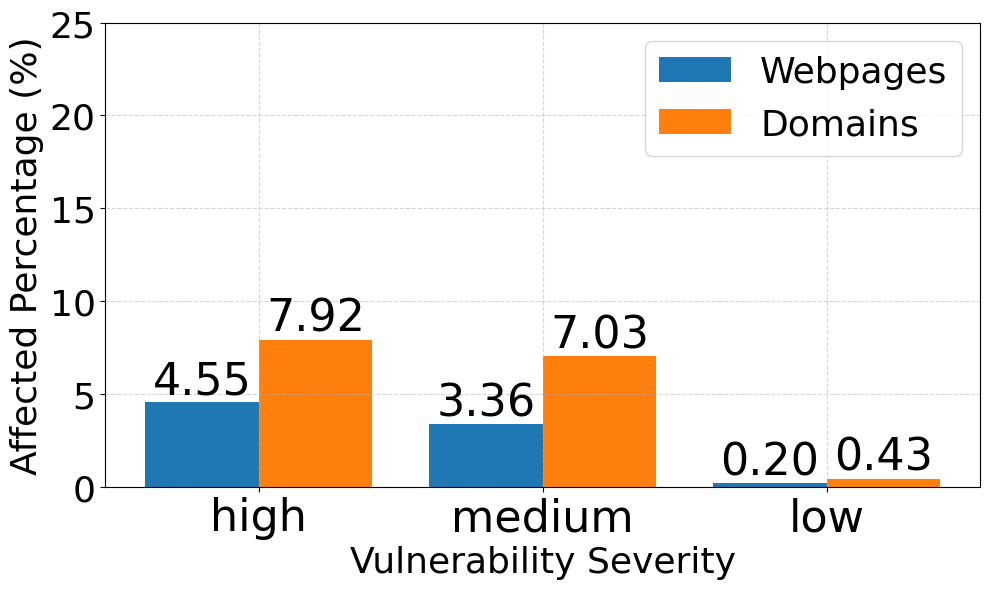


[*] Starting Analysis of Retire.js results for CRUX...
 CRUX - Webpages with at least one low vuln: 305/77723 - 0.39%
 CRUX - Webpages with at least one medium vuln: 6327/77723 - 8.14%
 CRUX - Webpages with at least one high vuln: 5737/77723 - 7.38%
 CRUX - Webpages with at least one critical vuln: 0/77723 - 0.00%
 CRUX - Domains with at least one low vuln: 75/9077 - 0.83%
 CRUX - Domains with at least one medium vuln: 1704/9077 - 18.77%
 CRUX - Domains with at least one high vuln: 1382/9077 - 15.23%
 CRUX - Domains with at least one critical vuln: 0/9077 - 0.00%


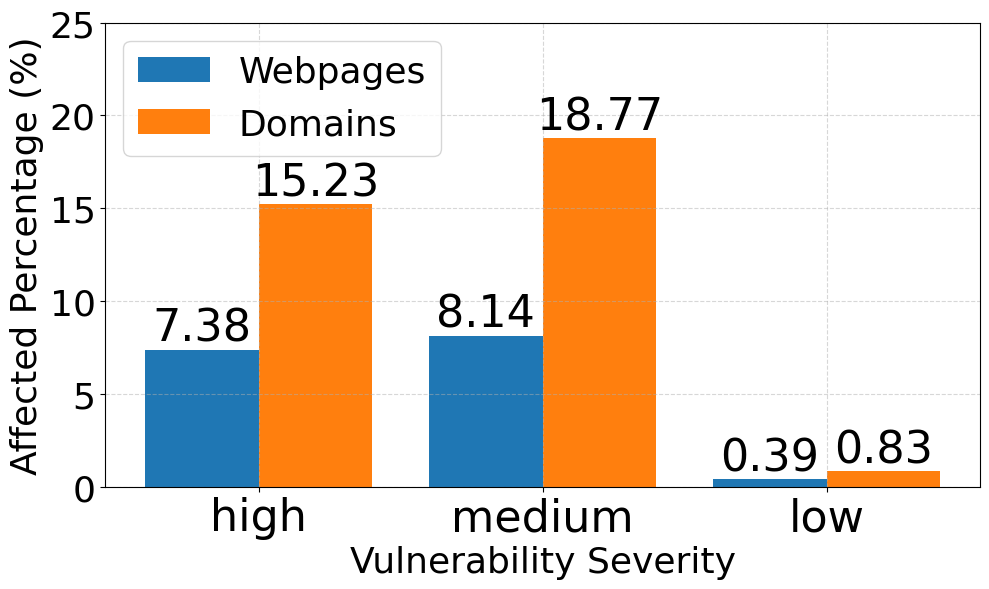

In [37]:
import tldextract
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import sqlite3

def extract_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.subdomain}.{ext.domain}.{ext.suffix}" if ext.subdomain else f"{ext.domain}.{ext.suffix}"

def analyze_3rd_high_vuln(source):
    print(f"[*] Starting Analysis of Retire.js results for {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE retirejs IS NOT NULL and source='{source}'" 
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    severity_rank = {
        None: -1,
        'low': 1,
        'medium': 2,
        'high': 3,
        'critical': 4
    }

    count_fail = 0
    max_sev_vuln_webpage = {
        "low": set(),
        "medium": set(),
        "high": set(),
        "critical": set(),
    }
    max_sev_vuln_domain = {
        "low": set(),
        "medium": set(),
        "high": set(),
        "critical": set(),
    }

    overall_websites_set = set()
    overall_domains_set = set()

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_retire'] = df['retirejs'].apply(json.loads)
        df['domain'] = df['url'].apply(extract_domain)
        
        for _, row in df.iterrows():
            skip = False
            for entry in row['formatted_retire']:
                if 'error' in entry.keys():
                    count_fail += 1
                    skip = True
            if skip:
                continue

            overall_websites_set.add(row['url'])
            overall_domains_set.add(row['domain'])

            max_severity_overall = None
            for entry in row['formatted_retire']:
                if "scanned" in entry.keys():
                    continue
                else:
                    key = list(entry.keys())[0]
                    severities = [vuln['severity'] for vuln in entry[key]]
                    max_sev = max(severities, key=lambda x: severity_rank[x])
                    max_severity_overall = max([max_sev, max_severity_overall], key=lambda x: severity_rank[x])

            if max_severity_overall is not None:
                max_sev_vuln_webpage[max_severity_overall].add(row['url'])

                found_sev = None
                for severity, domains in max_sev_vuln_domain.items():
                    if row['domain'] in domains:
                        found_sev = severity
                        break

                if max([found_sev, max_severity_overall], key=lambda x: severity_rank[x]) != found_sev:
                    if found_sev is not None:
                        max_sev_vuln_domain[found_sev].remove(row['domain'])
                    max_sev_vuln_domain[max_severity_overall].add(row['domain'])

    for x, y in max_sev_vuln_webpage.items():
        print(f" {source} - Webpages with at least one {x} vuln: {len(y)}/{len(overall_websites_set)} - {len(y)/len(overall_websites_set) * 100:.2f}%")

    for x, y in max_sev_vuln_domain.items():
        print(f" {source} - Domains with at least one {x} vuln: {len(y)}/{len(overall_domains_set)} - {len(y)/len(overall_domains_set) * 100:.2f}%")

    desired_order = ['high', 'medium', 'low']
    severity_data = [
        (s, len(max_sev_vuln_webpage[s]) / len(overall_websites_set) * 100,
         len(max_sev_vuln_domain[s]) / len(overall_domains_set) * 100)
        for s in desired_order if len(max_sev_vuln_webpage[s]) > 0
    ]

    sorted_severities = [x[0] for x in severity_data]
    webpage_percentages = [x[1] for x in severity_data]
    domain_percentages = [x[2] for x in severity_data]

    x = np.arange(len(sorted_severities))
    width = 0.4

    plt.figure(figsize=(10, 6))
    bars_webpages = plt.bar(x - width/2, webpage_percentages, width, label='Webpages', color='C0')
    bars_domains = plt.bar(x + width/2, domain_percentages, width, label='Domains', color='C1')

    for bars in [bars_webpages, bars_domains]:
        for bar in bars:
            height = bar.get_height()
            plt.annotate(f'{height:.2f}',
                         (bar.get_x() + bar.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=32)

    plt.xlabel("Vulnerability Severity", fontsize=26)
    plt.ylabel("Affected Percentage (%)", fontsize=26)
    plt.xticks(ticks=x, labels=sorted_severities, rotation=0, fontsize=32)
    plt.yticks(fontsize=26)
    plt.ylim(0, 25)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title_fontsize=28, fontsize=26)
    plt.tight_layout()

    plt.savefig(f'/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/{source}-vulnerable_websites_domains.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run for both datasets
analyze_3rd_high_vuln("BB")
print()
analyze_3rd_high_vuln("CRUX")


[*] Analyzing CVE age distribution per webpage for BB...
0


2500
5000
7500
10000
12500
[*] Analyzing CVE age distribution per webpage for CRUX...
0
2500
5000
7500
10000
12500
15000
17500
20000
22500
25000
27500
30000
32500
35000
37500
40000
42500
45000
47500
50000
52500
55000
57500
60000
62500
65000
67500
70000
72500
75000
77500
80000


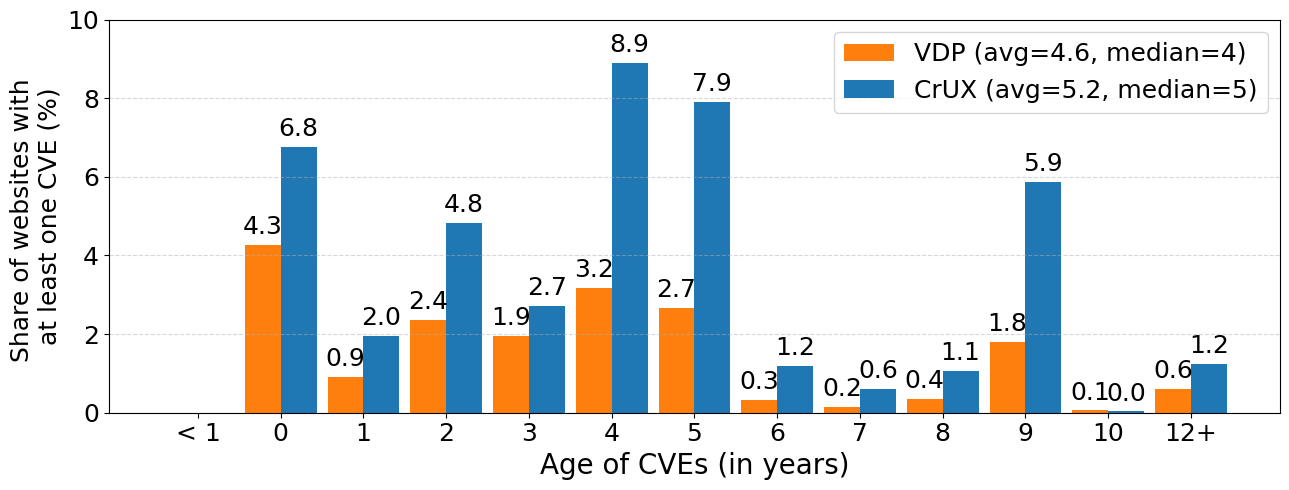

{'VDP': {'average': 4.580290537887711, 'median': 4},
 'CrUX': {'average': 5.215183824627423, 'median': 5}}

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import tldextract
import sqlite3
import pandas as pd
import json
from collections import Counter

def analyze_cve_age_per_webpage(source):
    print(f"[*] Analyzing CVE age distribution per webpage for {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE retirejs IS NOT NULL and source='{source}'" 
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    current_year = 2025
    age_to_webpages = {i: set() for i in range(13)}  # Altersbuckets: 0–12+, 12 = 12+
    all_urls = set()

    i = 0
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        print(i)
        i += 2500
        df['formatted_retire'] = df['retirejs'].apply(json.loads)
        for _, row in df.iterrows():
            skip = False
            for entry in row['formatted_retire']:
                if 'error' in entry:
                    skip = True
            if skip:
                continue

            url = row['url']
            all_urls.add(url)
            cve_years = set()

            for entry in row['formatted_retire']:
                if 'scanned' in entry:
                    continue

                key = list(entry.keys())[0]
                for vuln in entry[key]:
                    if 'CVE' in vuln['identifiers']:
                        for cve_id in vuln['identifiers']['CVE']:
                            parts = cve_id.split('-')
                            if len(parts) >= 3 and parts[1].isdigit():
                                cve_year = int(parts[1])
                                cve_age = current_year - cve_year
                                cve_age_bucket = min(cve_age, 12)
                                age_to_webpages[cve_age_bucket].add(url)

    return age_to_webpages, len(all_urls)


import statistics

def plot_cve_age_distribution_by_webpages(age_to_webpages_A, total_A, age_to_webpages_B, total_B):
    labels = ["< 1"] + [str(i) for i in range(11)] + ['12+']
    x = np.arange(len(labels)) * 1.5
    width = 0.65

    # Werte berechnen
    values_A = [len(age_to_webpages_A[i]) / total_A * 100 for i in range(13)]
    values_B = [len(age_to_webpages_B[i]) / total_B * 100 for i in range(13)]

    # Alterslisten für statistische Auswertung
    cve_ages_per_website_A = []
    cve_ages_per_website_B = []

    for age in range(13):
        cve_ages_per_website_A.extend([age] * len(age_to_webpages_A[age]))
        cve_ages_per_website_B.extend([age] * len(age_to_webpages_B[age]))

    # Statistik berechnen
    avg_age_A = statistics.mean(cve_ages_per_website_A)
    median_age_A = statistics.median(cve_ages_per_website_A)

    avg_age_B = statistics.mean(cve_ages_per_website_B)
    median_age_B = statistics.median(cve_ages_per_website_B)

    # Plot
    fig, ax = plt.subplots(figsize=(13, 5))
    bars_A = ax.bar(x - width/2, values_A, width, label=f'VDP (avg={avg_age_A:.1f}, median={median_age_A:.0f})', color='C1')
    bars_B = ax.bar(x + width/2, values_B, width, label=f'CrUX (avg={avg_age_B:.1f}, median={median_age_B:.0f})', color='C0')

    ax.set_xlabel('Age of CVEs (in years)', fontsize=20)
    ax.set_ylabel('Share of websites with \nat least one CVE (%)', fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 10)
    ax.legend(fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Prozentwerte über den Balken anzeigen
    for rect in bars_A + bars_B:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width()/2., height + 0.15,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=18)

    plt.tight_layout()
    plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/vulnerable_libraries_age_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    return {
        "VDP": {"average": avg_age_A, "median": median_age_A},
        "CrUX": {"average": avg_age_B, "median": median_age_B}
    }


# --- Main Execution ---
age_to_urls_A, total_urls_A = analyze_cve_age_per_webpage("BB")
age_to_urls_B, total_urls_B = analyze_cve_age_per_webpage("CRUX")

plot_cve_age_distribution_by_webpages(age_to_urls_A, total_urls_A, age_to_urls_B, total_urls_B)

In [3]:
import tldextract
import statistics
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas as pd
from collections import Counter
import json


# Try check how many domain have a vulneability with at least mid and high vulnerabilities
def analyze_3rd_Vuln_domains(source):
    print(f"[*] Starting Analysis of Retire.js results for {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE retirejs IS NOT NULL and source='{source}'" 
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    severity_rank = {
        'low': 1,
        'medium': 2,
        'high': 3,
        'critical': 4
    }

    count_fail = 0

    vuln_code_vers = set()
    domains_with_vulns_high = set()
    domains_with_vulns_medium = set()
    overall_domains_set = set()

    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_retire'] = df['retirejs'].apply(json.loads)
        for _, row in df.iterrows():
            subdomain = tldextract.extract(row['url']).subdomain
            domain = tldextract.extract(row['url']).domain
            suffix = tldextract.extract(row['url']).suffix
            domain = f'{subdomain}.{domain}.{suffix}'

            skip = False
            for entry in row['formatted_retire']:
                if 'error' in entry.keys():
                    count_fail = count_fail + 1
                    skip = True
            
            if skip:
                continue

            overall_domains_set.add(domain)
            for entry in row['formatted_retire']:
                if "scanned" in entry.keys():
                    # just the scan timestamp
                    continue
                else:
                    # these are the libs with known vulns
                    key = list(entry.keys())[0]
                    lib = key.split(" - ")[0]

                    # individual vulns
                    severities = []
                    for vuln in entry[key]:
                        severities.append(vuln['severity'])

                    max_sev = max(severities, key=lambda x: severity_rank[x])

                    if max_sev == "high" or max_sev == "critical":
                        domains_with_vulns_high.add(domain)

                    if max_sev == "high" or max_sev == "medium" or max_sev == "critical":
                        domains_with_vulns_medium.add(domain)

    

    print(f'[*] {source} - Domains with at least one high or higher vulnerability: {len(domains_with_vulns_high)}/{len(overall_domains_set)} - {len(domains_with_vulns_high)/len(overall_domains_set) * 100}')
    print(f'[*] {source} - Domains with at least one medium or higher vulnerability: {len(domains_with_vulns_medium)}/{len(overall_domains_set)} - {len(domains_with_vulns_medium)/len(overall_domains_set) * 100}')


print("----------VDP----------")
analyze_3rd_Vuln_domains("BB")
print()
print()
print("----------CRUX----------")
analyze_3rd_Vuln_domains("CRUX")



----------VDP----------
[*] Starting Analysis of Retire.js results for BB...


[*] BB - Domains with at least one high or higher vulnerability: 259/3272 - 7.915647921760391
[*] BB - Domains with at least one medium or higher vulnerability: 489/3272 - 14.944987775061126


----------CRUX----------
[*] Starting Analysis of Retire.js results for CRUX...
[*] CRUX - Domains with at least one high or higher vulnerability: 1382/9077 - 15.225294700892366
[*] CRUX - Domains with at least one medium or higher vulnerability: 3086/9077 - 33.998016965957916


## Results - SSL Scan

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas as pd
from collections import Counter
import json

# Analysis of Certificate Data - SSL Scan
print("[*] Starting SSLScan/Certificate Analysis...")

def analyze_cert_errors(source):
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE sslscan IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    count_succ = 0
    count_fail = 0

    error_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_sslscan'] = df['sslscan'].apply(json.loads)
        for sslscan_result in df["formatted_sslscan"]:
            if "error" in sslscan_result:
                count_fail += 1
                if "Invalid target specified" in sslscan_result['error']:
                    error_counter["Invalid target specified"] += 1
                else:
                    if "timed out after 90 seconds" in sslscan_result['error']:
                        error_counter['Timed out'] += 1
                    else:
                        error_counter['Exception - No further information'] += 1
                        print(sslscan_result['error'])
            else:
                if "ssltest" in sslscan_result['sslscan']['document'].keys():
                    count_succ += 1
                    pass
                else:
                    count_fail += 1
                    err = sslscan_result['sslscan']['document']['error']

                    if isinstance(err, list):
                        err = err[0]

                    if "Could not resolve hostname" in err:
                        error_counter['Could not resolve hostname'] += 1

                    elif "Timed out" in err:
                        error_counter['Timed out'] += 1

                    elif "Connection refused" in err:
                        error_counter["Connection refused"] += 1

                    elif "No route to host" in err:
                        error_counter['No route to host'] =+ 1

                    elif True:
                        print(err)
                        

    print(f" [!] {source} - ERRORS:")    
    for key, num in error_counter.items():
        print(f"  - {key} : {num}")
        
    print(f" [*] {source} - Number of SSLScans encountering errors - {count_fail}")
    print(f" [*] {source} - Number of SSLScans done wihtout error - {count_succ}")
    print(f' [*] --> Error Rate: {count_fail/(count_succ + count_fail)*100}%')
    print()

print()
analyze_cert_errors("BB")
print()
print()
analyze_cert_errors("CRUX")
print


[*] Starting SSLScan/Certificate Analysis...

Exception: b'' - b''
Exception: b'' - b''
Exception: b'Version: \x1b2.1.2\x1b\nOpenSSL 3.0.13 30 Jan 2024\n\x1b\n\x1bConnected to 44.208.245.183\x1b\n\nTesting SSL server \x1bprocessaccess.kkr.com\x1b on port \x1b443\x1b using SNI name \x1bprocessaccess.kkr.com\x1b\n\n  \x1bSSL/TLS Protocols:\x1b\nSSLv2     \x1bdisabled\x1b\nSSLv3     \x1bdisabled\x1b\nTLSv1.0   \x1benabled\x1b\nTLSv1.1   \x1benabled\x1b\nTLSv1.2   enabled\nTLSv1.3   \x1bdisabled\x1b\n\n  \x1bTLS Fallback SCSV:\x1b\nServer \x1bsupports\x1b TLS Fallback SCSV\n\n  \x1bTLS renegotiation:\x1b\n\x1bSecure\x1b session renegotiation supported\n\n  \x1bTLS Compression:\x1b\n\x1bOpenSSL version does not support compression\x1b\n\x1bRebuild with zlib1g-dev package for zlib support\x1b\n\n  \x1bHeartbleed:\x1b\nTLSv1.2 \x1bnot vulnerable\x1b to heartbleed\nTLSv1.1 \x1bnot vulnerable\x1b to heartbleed\nTLSv1.0 dying' - b'\x1bERROR: Could not open a connection to host processaccess.kkr.

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

[*] Checking results of SSLScan - BB...
  [!] Expired Certificate found - *.rapide.co.uk - http://survey.ovoenergy.com
 [*] Vulnerable to heartbleed TLSv1.2 - 0 - *.deezer.com
  [!] Expired Certificate found - *.ext.tripadvisor.com - http://marlo.ext.tripadvisor.commarlo.ext.tripadvisor.com
  [!] Expired Certificate found - smsdsli.s01.gxsonline.net - http://b2bsas2.dell.com
  [!] Self-Signed Certificate found - smsdsli.s01.gxsonline.net - http://b2bsas2.dell.com
  [!] Expired Certificate found - *.institutounibanco.org.br - http://institutounibanco.org.br
  [!] Expired Certificate found - *.sylvaniamobile.com - http://royalcaninfoodfinder.com
  [!] Expired Certificate found - assets.citymesh.com - http://antwerpfreewifi.be
[*] BB - Statistics by Renegotiation
   Supported: 0 - Secure: 0: 2536 occurrences
   Supported: 1 - Secure: 1: 296 occurrences
[*] BB - Cert Strength
  RSA-4096-strong: 134 occurrences
  EC-128-weak: 939 occurrences
  RSA-2048-medium: 1722 occurrences
  RSA-3072-st

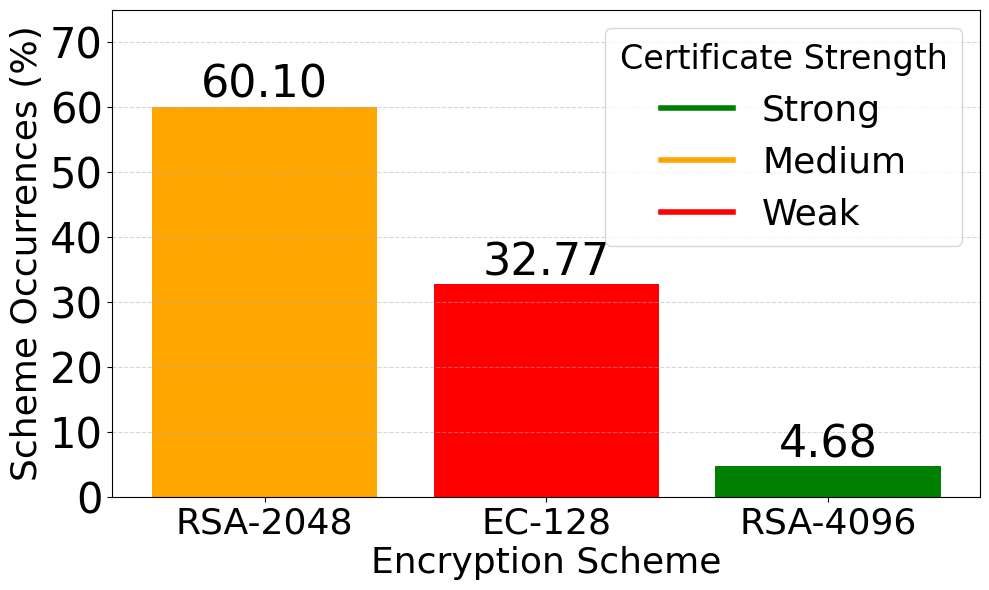

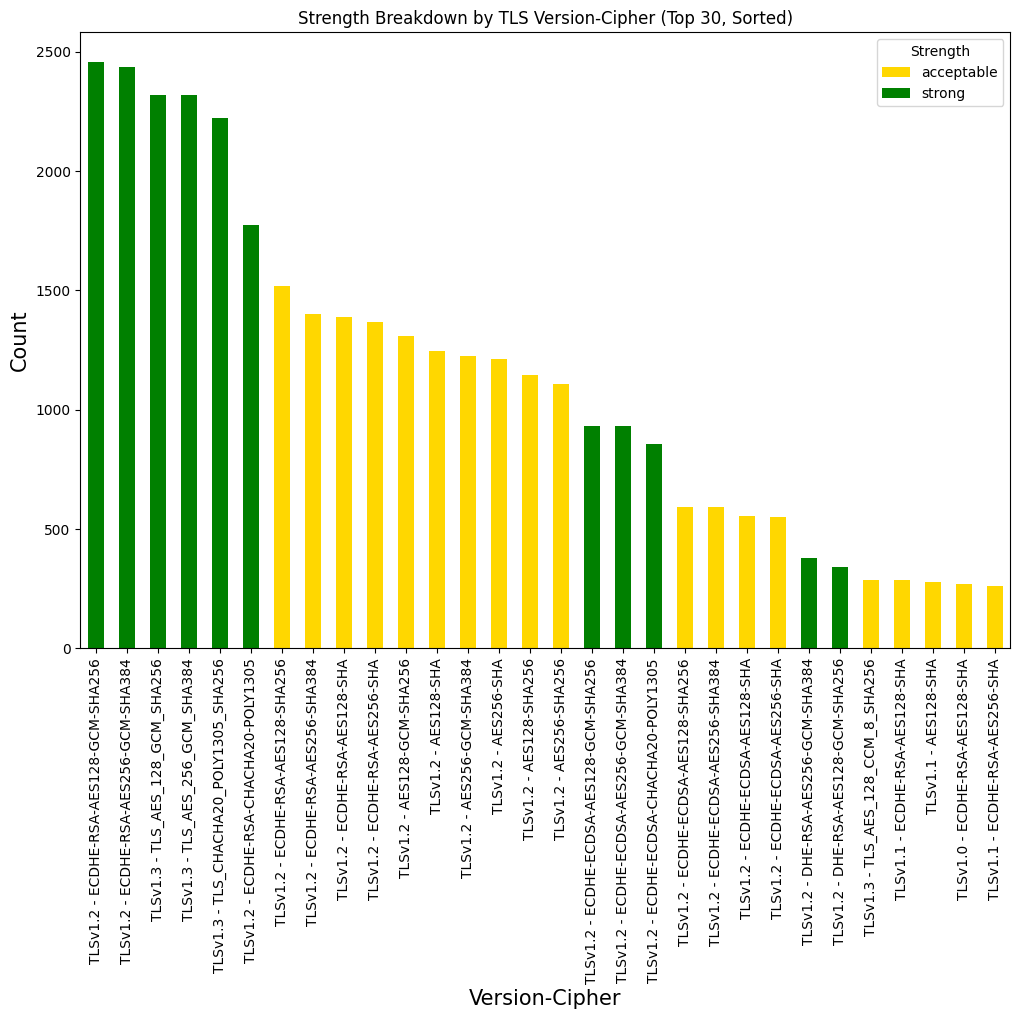

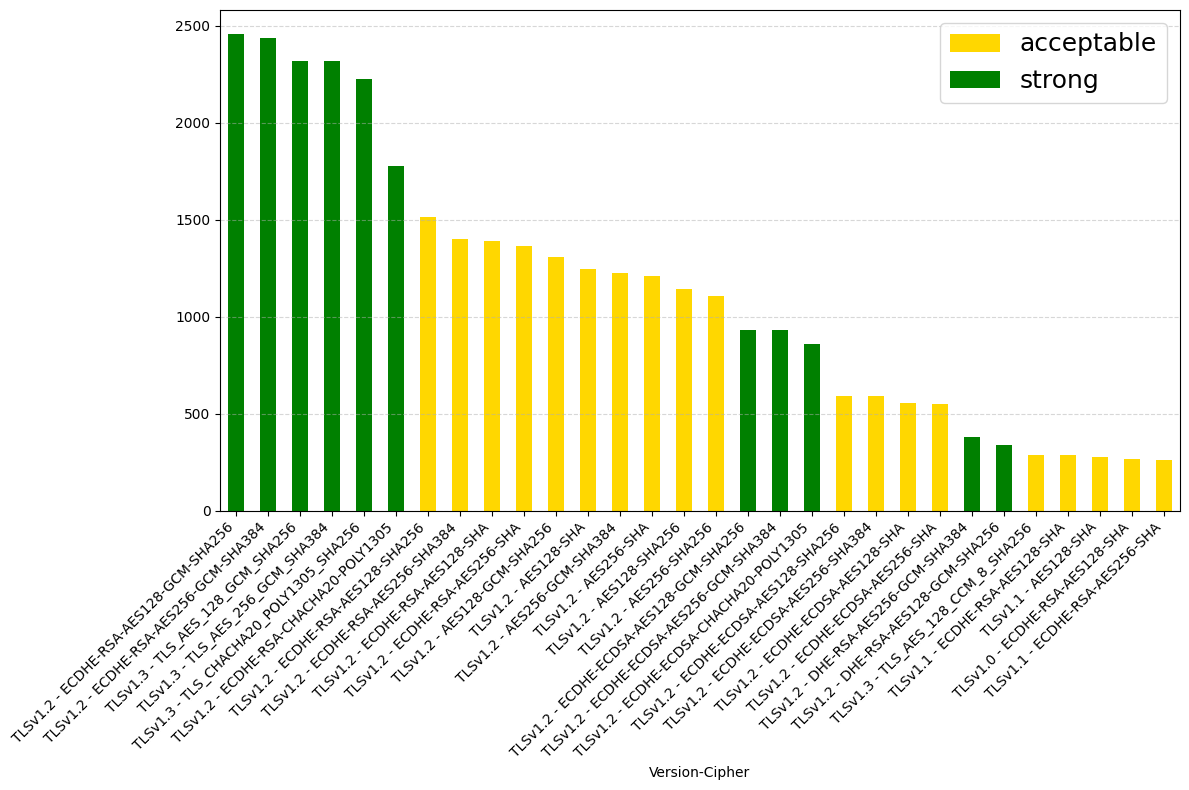

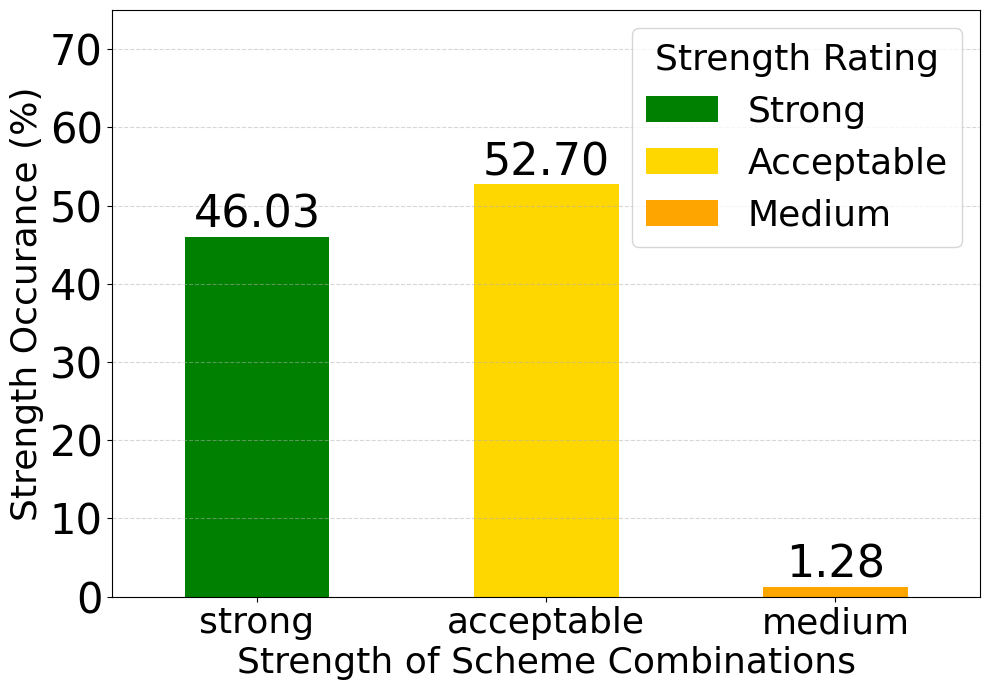

Overall unqiue domain rows: 3412
---------
[*] Checking results of SSLScan - CRUX...
  [!] Expired Certificate found - localhost.localdomain - http://himasoku.com
  [!] Self-Signed Certificate found - localhost.localdomain - http://himasoku.com
  [!] Expired Certificate found - localhost.localdomain - http://blog.livedoor.jp
  [!] Self-Signed Certificate found - localhost.localdomain - http://blog.livedoor.jp
  [!] Expired Certificate found - sedatez.gob.ve - http://timbre.sedatez.gob.ve
  [!] Expired Certificate found - www.brandshop.mk - http://www.femina.mk
  [!] Expired Certificate found - localhost.localdomain - http://jin115.com
  [!] Self-Signed Certificate found - localhost.localdomain - http://jin115.com
  [!] Expired Certificate found - localhost.localdomain - http://blog.esuteru.com
  [!] Self-Signed Certificate found - localhost.localdomain - http://blog.esuteru.com
  [!] Expired Certificate found - hometownwastenj.com - http://www4.xemtuong.net
 [*] Vulnerable to heartblee

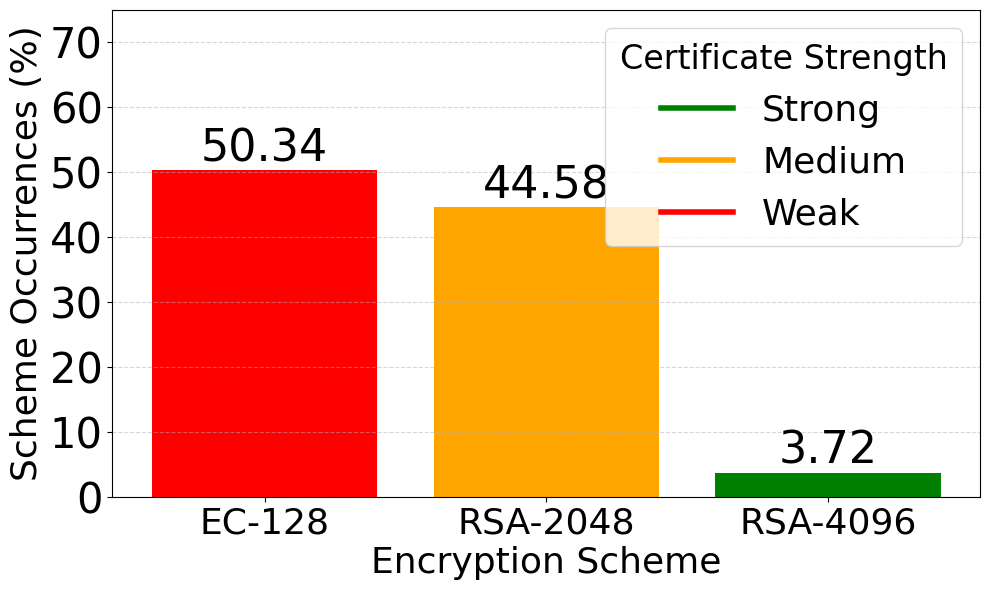

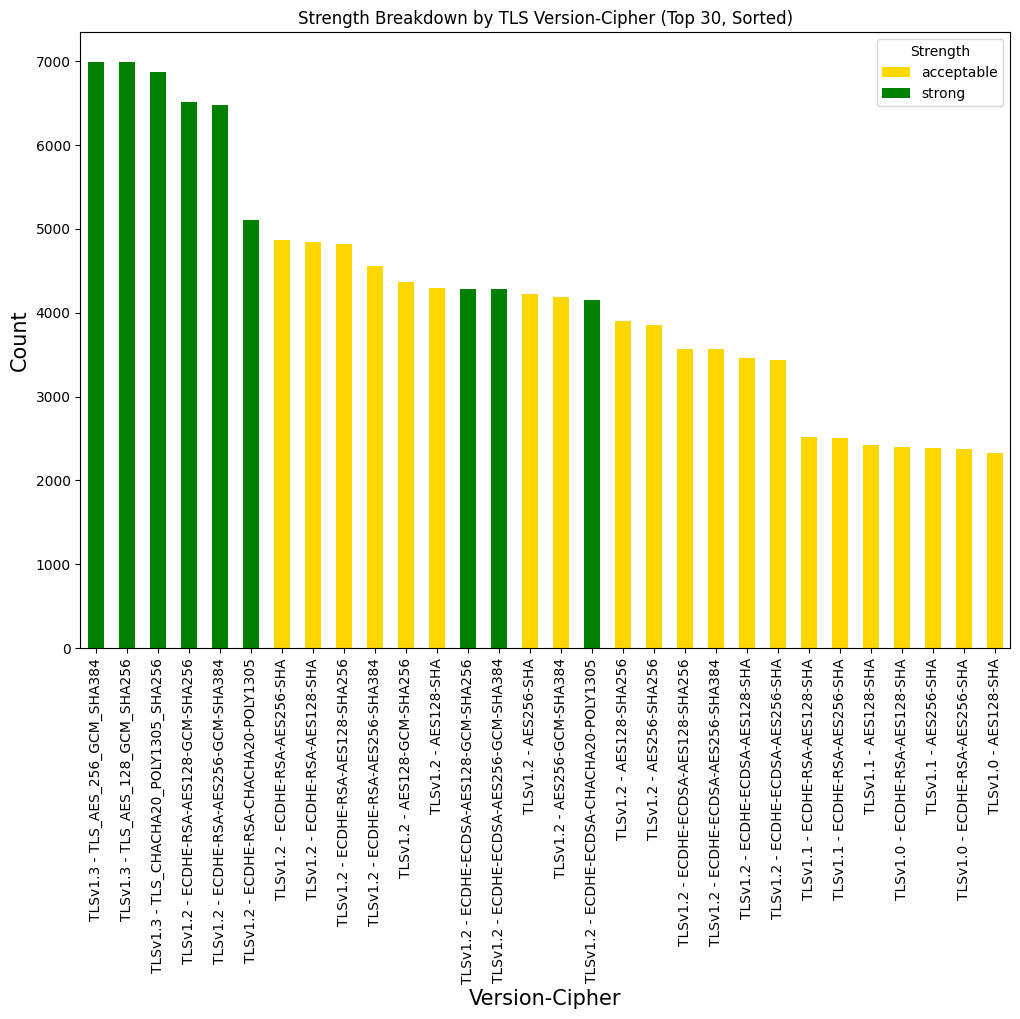

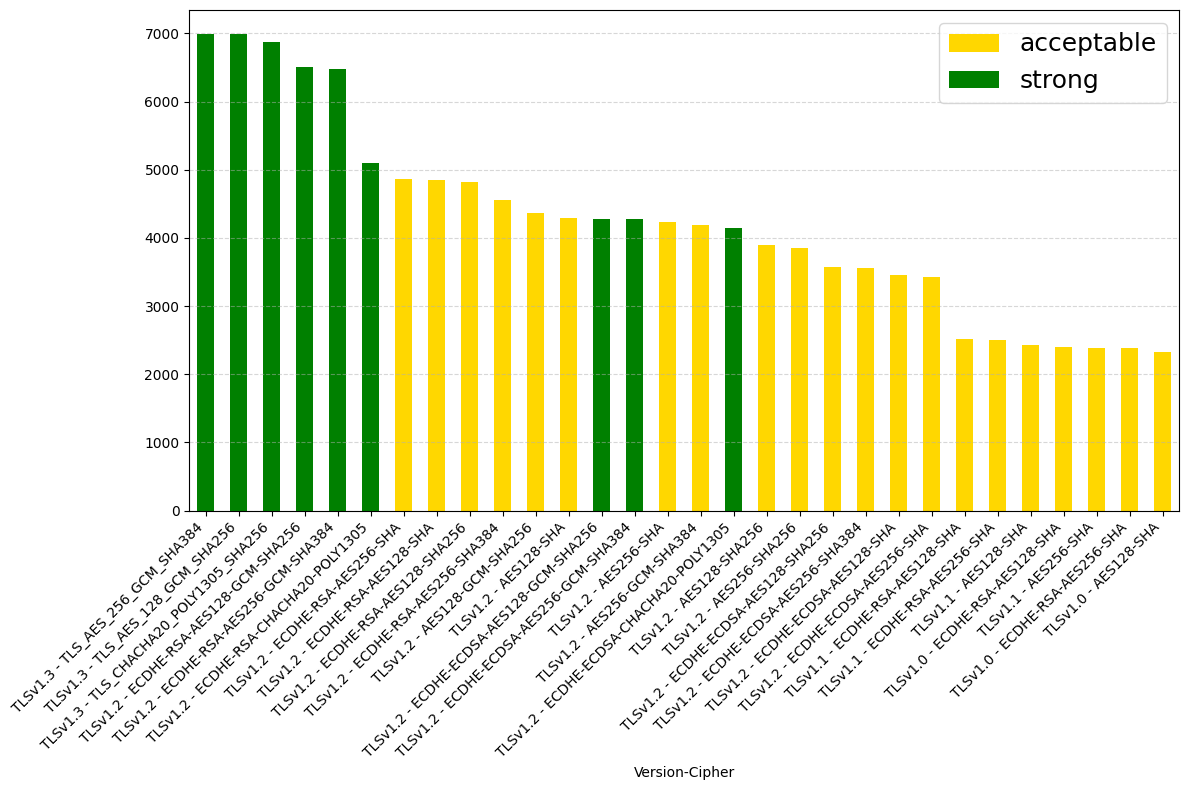

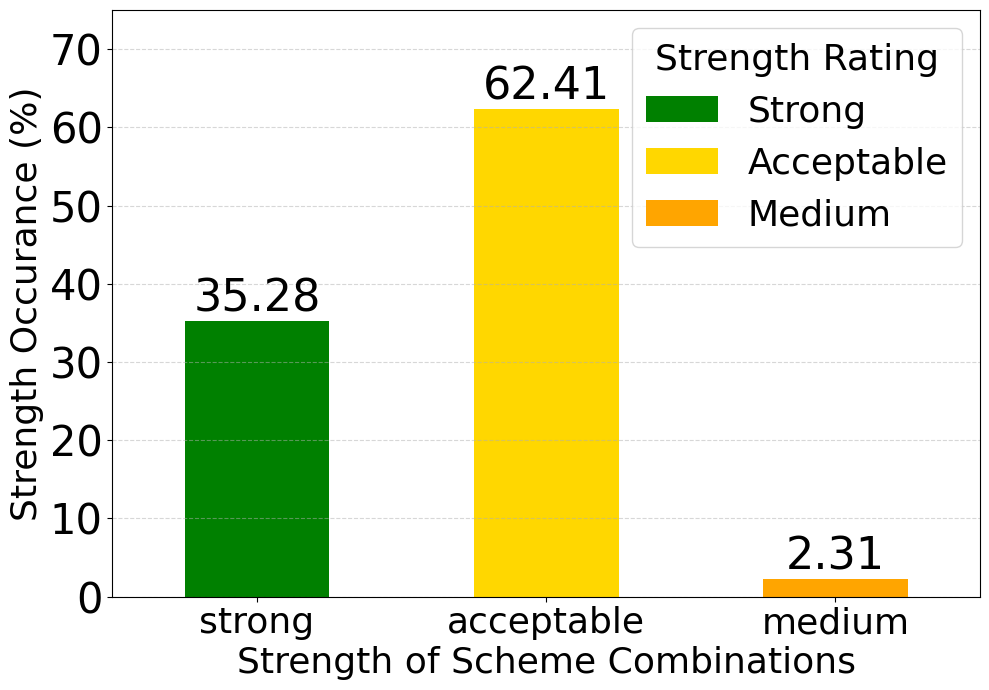

Overall unqiue domain rows: 9403


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas as pd
from collections import Counter
import json
import tldextract
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


def get_strength(category):
    if 'strong' in category:
        return 'strong'
    elif 'medium' in category:
        return 'medium'
    elif 'weak' in category:
        return 'weak'
    else:
        return 'anonymous'

def eval_cert(source, top_x):
    print(f"[*] Checking results of SSLScan - {source}...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE sslscan IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    count_succ = 0
    count_fail = 0
    CERT_ENC_LEVEL = {
        "RSA": {
            "1024": "weak",
            "2048": "medium",
            "3072": "strong",
            "4096": "strong",
            "8192": "overkill"
        },
        "DSA": {
            "1024": "weak",
            "2048": "medium",
            "3072": "strong"
        },
        "ECC": {  # Elliptic Curve Cryptography
            "160": "weak",
            "224": "medium",
            "256": "strong",
            "384": "strong",
            "521": "strong"
        },
        "EC": {  
            "128": "weak", 
            "160": "weak",
            "192": "medium",
            "224": "medium",
            "256": "strong",
            "384": "strong",
            "521": "strong"
        },
        "EdDSA": {  
            "Ed25519": "strong",
            "Ed448": "strong"
        },
        "DH": {  # Diffie-Hellman
            "1024": "weak",
            "2048": "medium",
            "3072": "strong",
            "4096": "strong"
        },
        "ECDH": {  # Elliptic Curve Diffie-Hellman
            "256": "strong",
            "384": "strong",
            "521": "strong"
        }
    }


    renegotiation_counter = Counter()
    cert_issuer_counter = Counter()
    cipher_counter = Counter()
    strength_counter = Counter()
    error_counter = Counter()
    fallback_counter = Counter()
    protocol_counter = Counter()
    group_counter = Counter()
    overall_domains = set()
    cert_enc_rating_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['formatted_sslscan'] = df['sslscan'].apply(json.loads)
        for _, row in df.iterrows():
            overall_domains.add(row['url'])
            sslscan_result = row["formatted_sslscan"]
            if "error" in sslscan_result:
                count_fail += 1
                if "Invalid target specified" in sslscan_result['error']:
                    error_counter["Invalid target specified"] += 1
                
                else:
                    error_counter['Exception - No further information'] += 1
                    # print(sslscan_result['error'])
            else:
                count_succ += 1
                if "ssltest" in sslscan_result['sslscan']['document'].keys():
                    ssltest = sslscan_result['sslscan']['document']['ssltest']
                    # normally:
                    # dict_keys(['@host', '@sniname', '@port', 'protocol', 'fallback', 'renegotiation', 'heartbleed', 'cipher', 'group', 'certificates'])

                    # HEARTBLEED
                    if 'heartbleed' in ssltest.keys():
                        # array -> multtiple results
                        if isinstance(ssltest['heartbleed'],list):
                            for heartbleed_test in ssltest['heartbleed']:
                                if heartbleed_test['@vulnerable'] != "0":
                                    print(f" [*] Vulnerable to heartbleed {heartbleed_test['@sslversion']} - {heartbleed_test['@vulnerable']} - {cert_data['subject']}")

                        # no array -> only one result            
                        else:
                            if ssltest['heartbleed']['@vulnerable'] != "0":
                                print(f" [*] Vulnerable to heartbleed {heartbleed_test['@sslversion']} - {heartbleed_test['@vulnerable']} - {cert_data['subject']}")
                        
                    # CIPHER
                    if 'cipher' in ssltest.keys():
                        cipher_data = ssltest['cipher']
                        if isinstance(cipher_data, list):
                            for entry in cipher_data:
                                version_cipher = f"{entry['@sslversion']} - {entry['@cipher']}"
                                strength = entry['@strength']
                            
                                # Count occurrences
                                cipher_counter[version_cipher] += 1
                                strength_counter[(version_cipher, strength)] += 1

                    # Certificates
                    if 'certificates' in ssltest.keys():
                        cert_data = ssltest['certificates']
                        if isinstance(cert_data, dict):
                            if len(cert_data) != 1:
                                print(f'LÄNGE CERTIFICATES: {len(cert_data)}')
                            
                            if 'certificate' in cert_data.keys():
                                cert_data = cert_data['certificate']
                                if 'expired' in cert_data.keys():
                                    if cert_data['expired'] == 'true':
                                        print(f"  [!] Expired Certificate found - {cert_data['subject']} - {row['url']}")

                                if 'not-yet-valid' in cert_data.keys():
                                    if cert_data['not-yet-valid'] == 'true':
                                        print(f"  [!] Not-Yet-Valid Certificate found - {cert_data['subject']} - {row['url']}")

                                if 'issuer' in cert_data.keys():
                                    cert_issuer_counter[cert_data['issuer']] += 1

                                if 'self-signed' in cert_data.keys():
                                    if cert_data['self-signed'] == "true":
                                        print(f"  [!] Self-Signed Certificate found - {cert_data['subject']} - {row['url']}")

                                if 'pk' in cert_data.keys():
                                    cert_type = cert_data['pk'].get('@type')
                                    cert_bits = cert_data['pk'].get('@bits')

                                    if cert_type in CERT_ENC_LEVEL and cert_bits in CERT_ENC_LEVEL[cert_type]:
                                        cert_enc_rating = CERT_ENC_LEVEL[cert_type][cert_bits]
                                        cert_enc_rating_counter[f'{cert_type}-{cert_bits}-{cert_enc_rating}'] += 1
                                    else:
                                        print(f"  [!] Missing rating for combination: {cert_type} with {cert_bits} bits")

                                    if cert_data['pk'].get('@error') != "false":
                                        print(f"  [!] Error in Certificate found - {cert_data['pk']['@error']}")

                    # Renegotiation
                    if 'renegotiation' in ssltest.keys():
                        renegotiation_counter[f" Supported: {ssltest['renegotiation']['@supported']} - Secure: {ssltest['renegotiation']['@secure']}"] += 1

                    # Fallback -> Idk what this is
                    if 'fallback' in ssltest.keys():
                        fallback_counter[ssltest['fallback']['@supported']] += 1

                    # Protocol - List supported SSL/TLS versions
                    if 'protocol' in ssltest.keys():
                        for entry in ssltest['protocol']:
                            key = f"{entry['@type'].upper()} {entry['@version']}"
                            status = "Enabled" if entry['@enabled'] == '1' else "Disabled"
                            protocol_counter[(key, status)] += 1
        

                    # Group -> The ciphers used in corresponding allowed SSL/TLS versions + bits  ----> But equally to cipher???
                    if 'group' in ssltest.keys():
                        if isinstance(ssltest['group'], list):
                            for entry in ssltest['group']:
                                    key = f"{entry['@sslversion'].upper()} {entry['@name']} {entry['@bits']}"   
                                    group_counter[key] += 1
                        else:
                            key = f"{ssltest['group']['@sslversion'].upper()} {ssltest['group']['@name']} {ssltest['group']['@bits']}"   
                            group_counter[key] += 1

    strength_colors = {
        'strong': 'green',
        'acceptable': 'gold',
        'medium': 'orange',
        'anonymous': 'grey',
        'weak': 'red'
    }

    print(f"[*] {source} - Statistics by Renegotiation")
    for vc, count in renegotiation_counter.items():
        print(f"  {vc}: {count} occurrences")

    print(f"[*] {source} - Cert Strength")
    for vc, count in cert_enc_rating_counter.items():
        print(f"  {vc}: {count} occurrences")


    # Bar Plot for cert strenght
    sorted_cert_enc_rating = sorted(cert_enc_rating_counter.items(), key=lambda x: x[1], reverse=True)[:3]
    labels = [x[0].rsplit("-", 1)[0] for x in sorted_cert_enc_rating]
    values = [x[1] / count_succ * 100 for x in sorted_cert_enc_rating]
    colors = [strength_colors[get_strength(x[0]).strip().lower()] for x in sorted_cert_enc_rating]
    
    plt.figure(figsize=(10, 6))  # Größe des Plots
    ax = plt.bar(labels, values, color=colors)

    # Add percentage labels above bars
    for p in ax:
        height = p.get_height()
        plt.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=32) 

    # Plot-Details
    #plt.title(f'Certificate Strength Distribution ({source})', fontsize=16)
    plt.xlabel('Encryption Scheme', fontsize=26)
    plt.ylabel('Scheme Occurrences (%)', fontsize=26)
    plt.xticks(rotation=0, fontsize=18)
    plt.ylim(0, 75)
    plt.xticks(rotation=0, fontsize=26)
    plt.yticks(rotation=0, fontsize=30)
    plt.legend(
        handles=[
            plt.Line2D([0], [0], color=strength_colors['strong'], lw=4),
            plt.Line2D([0], [0], color=strength_colors['medium'], lw=4),
            plt.Line2D([0], [0], color=strength_colors['weak'], lw=4)
        ],
        labels=['Strong', 'Medium', 'Weak'],
        title="Certificate Strength",
        title_fontsize=24,
        fontsize=26 
    )
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/{source}-certificate_enc_strength_plot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    '''
    # Output statistics
    print(f"[*] {source} - Statistics by Version-Cipher:")
    for vc, count in cipher_counter.items():
        print(f"  {vc}: {count} occurrences")

    print(f"\n[*] {source} - Breakdown by Strength:")
    for (vc, strength), count in strength_counter.items():
        print(f"  {vc} ({strength}): {count} occurrences")

    print(f"\n[*] {source} - Proportion of Strengths by Cipher:")
    for vc in cipher_counter:
        total = sum(count for (v, s), count in strength_counter.items() if v == vc)
        strengths = {s: c for (v, s), c in strength_counter.items() if v == vc}
        proportions = {s: c / total for s, c in strengths.items()}
        print(f"  {vc}: {proportions}")
    '''

    cipher_data = pd.DataFrame.from_dict(cipher_counter, orient='index', columns=['Count']).reset_index()
    cipher_data.rename(columns={'index': 'Version-Cipher'}, inplace=True)

    strength_data = pd.DataFrame([{'Version-Cipher': vc, 'Strength': strength, 'Count': count}
                                for (vc, strength), count in strength_counter.items()])
    cipher_data  = cipher_data.nlargest(top_x, 'Count')

    # Stacked Bar Chart: Breakdown by strength
    top_strength_data = strength_data[strength_data['Version-Cipher'].isin(cipher_data['Version-Cipher'])]
    strength_pivot = top_strength_data.pivot(index='Version-Cipher', columns='Strength', values='Count').fillna(0)
    strength_pivot['Total'] = strength_pivot.sum(axis=1)
    strength_pivot = strength_pivot.sort_values(by='Total', ascending=False)
    strength_pivot.drop(columns='Total', inplace=True)

    # Plot Stacked Bar Chart
    strength_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), color=[strength_colors.get(col, 'gray') for col in strength_pivot.columns])
    plt.title(f"Strength Breakdown by TLS Version-Cipher (Top {top_x}, Sorted)")
    plt.xlabel("Version-Cipher", fontsize=15)
    plt.ylabel("Count", fontsize=15)
    ax = strength_pivot.plot(kind='bar', stacked=True, figsize=(12, 8),rot=45,
                            color=[strength_colors.get(col, 'gray') for col in strength_pivot.columns])

    ax.set_xticks(range(len(strength_pivot.index)))  # Explizit: Positionen
    ax.set_xticklabels(strength_pivot.index, rotation=45, ha='right', fontsize=10) 
    ax.grid(axis='y', linestyle='--', alpha=0.5)   
    plt.tight_layout()
    plt.legend(
        title_fontsize=20,
        fontsize=18
    )
    plt.savefig(f'/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/{source}-https_protocol_cipher_plot_expanded.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    # Bar Chart: Overall proportion of strengths
    desired_order = ['strong', 'acceptable', 'medium']  # 👈 anonymous raus
    strength_total = (
        strength_data.groupby('Strength')['Count']
        .sum()
        .drop('anonymous', errors='ignore')  # 👈 sicher entfernen, falls vorhanden
    )
    strength_total = strength_total.reindex(desired_order)
    strength_percentage = (strength_total / strength_total.sum()) * 100
    colors = [strength_colors.get(strength, 'gray') for strength in strength_percentage.index]
    ax = strength_percentage.plot(
        kind='bar',
        figsize=(10, 7),
        color=colors,
    )
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    #ax.yaxis.set_major_formatter(PercentFormatter())
    plt.ylabel("Strength Occurance (%)", fontsize=26)
    plt.xlabel("Strength of Scheme Combinations", fontsize=26)
    plt.ylim(0, 75)
    plt.xticks(rotation=0, fontsize=26)
    plt.yticks(rotation=0, fontsize=30)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=32)
    legend_elements = [
        Patch(facecolor=strength_colors.get(key, 'gray'), label=key.capitalize())
        for key in strength_percentage.index
    ]
    ax.legend(handles=legend_elements, title="Strength Rating", title_fontsize=26, fontsize=26)
    plt.tight_layout()
    plt.savefig(f'/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/{source}-https_protocol_cipher_plot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    print(f"Overall unqiue domain rows: {len(overall_domains)}")
    

                     
eval_cert("BB", 30)
print("---------")
eval_cert("CRUX", 30)

## Results - Lighthouse Audit

In [ ]:
import sqlalchemy
import sqlite3
import json
import pandas as pd
import re
from collections import Counter
from sqlalchemy import create_engine
import pandas as pd
from urllib.parse import urlparse


# Analysis of Lighthouse Data
def eval_lighthouse(source):
    print("[*] Analysis of Lighthouse data...")
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE lighthouse IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2000

    count_succ = 0
    count_fail = 0
    error = ""
    error_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['lighthouse_formated'] = df['lighthouse'].apply(json.loads)
        for _, row in df.iterrows():
            ligthouse = row['lighthouse_formated']

            if "error" in ligthouse.keys():
                # Extract the reportet error
                pattern = r"Runtime error encountered: (.*)"
                match = re.search(pattern, ligthouse['error'], re.DOTALL)
                if match:
                    extracted_text = match.group(1) 

                    # Now check for specific Response Codes
                    pattern = r"Status code: /((.*)/)"
                    match = re.search(pattern, ligthouse['error'], re.DOTALL)
                    if match:
                        status_code = match.group(1) 
                        error_counter[f"Status Code {status_code}"] += 1
                        count_fail += 1
                    else:
                        error_counter[extracted_text] += 1
                        count_fail += 1
                else:
                    if 'timed out after' in ligthouse['error']:
                        error_counter['ProcessTimeout'] += 1

                    if 'Read timed out' in ligthouse['error']:
                        error_counter['PageReadTimeout'] += 1

                    elif 'StatusCode' in ligthouse['error']:
                        error_counter[ligthouse['error']] += 1

                    else:
                        error_counter['Exception - No further information'] += 1
                        #print(ligthouse['error'])
                    count_fail += 1
                continue

            else:
                fail =  False
                error = ligthouse['runWarnings']
                if 'was redirected to' in error:
                    error_counter['Redirection'] += 1
                    fail = True

                if 'slower CPU than  Lighthouse expects' in error:
                    error_counter['SlowCPU'] += 1
                    fail = True

                if 'The page loaded too slowly to finish within the time limit. Results may be incomplete.' in ligthouse['runWarnings']:
                    error_counter['LoadNotCompleted'] += 1
                    fail = True
                
                if fail:
                    count_fail  += 1
                else:
                    count_succ += 1
            


        '''

        for lighthouse_entry in df['lighthouse_formated']:
            print(lighthouse_entry.keys())
            print(lighthouse_entry[''])
            if "error" in lighthouse_entry.keys():
                # Extract the reportet error
                pattern = r"Runtime error encountered: (.*)"
                match = re.search(pattern, lighthouse_entry['error'], re.DOTALL)
                if match:
                    extracted_text = match.group(1) 

                    # Now check for specific Response Codes
                    pattern = r"Status code: /((.*)/)"
                    match = re.search(pattern, lighthouse_entry['error'], re.DOTALL)
                    if match:
                        status_code = match.group(1) 
                        error_counter[f"Status Code {status_code}"] += 1
                        count_fail += 1
                    else:
                        error_counter[extracted_text] += 1
                        count_fail += 1
                else:
                    if 'timed out after 120 seconds' in lighthouse_entry['error']:
                        error_counter['ProcessTimeout'] += 1
                    else:
                        error_counter['Exception - No further information'] += 1
                        #print(lighthouse_entry['error'])
                    count_fail += 1
                continue

            elif "runtimeError" in lighthouse_entry['runwa'].keys():
                count_fail += 1


            elif True:
                count_succ += 1

        '''
            
    print()
    print(f" [!] {source} - ERRORS:")    
    for key, num in error_counter.items():
        print(f"  - {key} : {num}")
    print(f" [*] {source} - Webpages for which Lighthouse ran: {count_succ}")
    print(f" [*] {source} - Webpages for which Lighthouse failed: {count_fail}")
    print(f'  --> Error Rate: {count_fail/(count_succ + count_fail)*100}%')
    print()

eval_lighthouse("BB")
eval_lighthouse("CRUX")

[*] Analysis of Lighthouse data...

 [!] BB - ERRORS:
  - LoadNotCompleted : 493
  - The page did not paint any content. Please ensure you keep the browser window in the foreground during the load and try again. (NO_FCP)
 : 156
  - PageReadTimeout : 77
  - Lighthouse was unable to reliably load the page you requested. Make sure you are testing the correct URL and that the server is properly responding to all requests. (Status code: 429)
 : 57
  - The page provided is not HTML (served as MIME type text/plain).
 : 75
  - Chrome prevented page load with an interstitial. Make sure you are testing the correct URL and that the server is properly responding to all requests.
 : 70
  - The page provided is not HTML (served as MIME type application/json).
 : 28
  - Lighthouse was unable to reliably load the page you requested. Make sure you are testing the correct URL and that the server is properly responding to all requests. (Status code: 403)
 : 88
  - Redirection or Error - StatusCode: 302 :

[*] Scores for BB:
  [*] Performance:
    - Average: 0.46
    - Median: 0.39
  [*] Accessibility:
    - Average: 0.86
    - Median: 0.89
  [*] Best-practices:
    - Average: 0.67
    - Median: 0.69
  [*] Seo:
    - Average: 0.83
    - Median: 0.85
[*] Scores for CRUX:
  [*] Performance:
    - Average: 0.47
    - Median: 0.42
  [*] Accessibility:
    - Average: 0.82
    - Median: 0.83
  [*] Best-practices:
    - Average: 0.62
    - Median: 0.62
  [*] Seo:
    - Average: 0.90
    - Median: 0.92
['performance', 'accessibility', 'best-practices', 'seo']


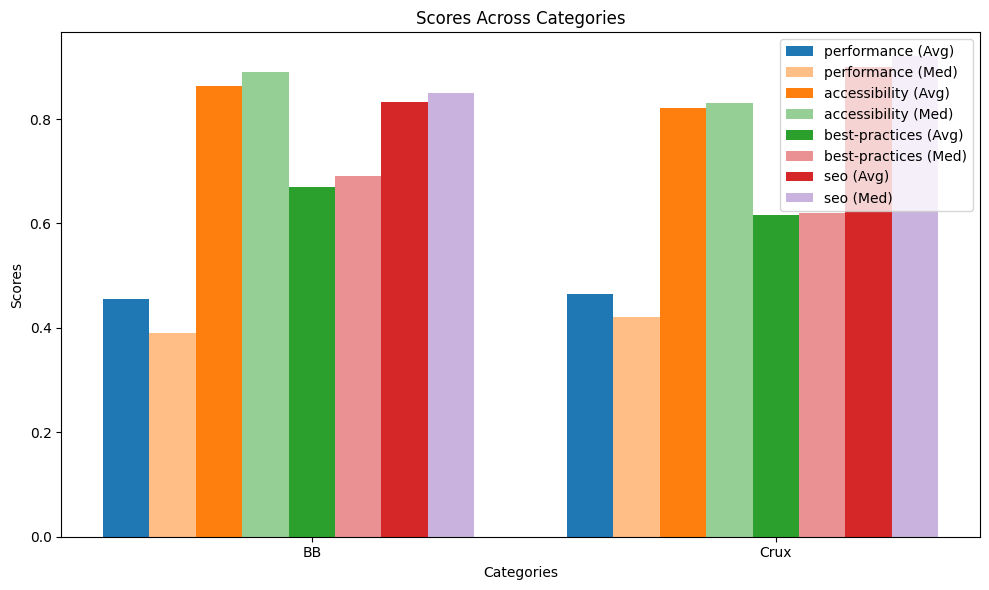


Comparison Table (BB vs CRUX for each category):
| Category       |   BB Avg |   CRUX Avg |   Δ Total (Avg) | Δ % (Avg)   |   BB Med |   CRUX Med |   Δ Total (Med) | Δ % (Med)   |
|----------------|----------|------------|-----------------|-------------|----------|------------|-----------------|-------------|
| performance    |     0.46 |       0.47 |           -0.01 | -1.94%      |     0.39 |       0.42 |           -0.03 | -7.14%      |
| accessibility  |     0.86 |       0.82 |            0.04 | 5.25%       |     0.89 |       0.83 |            0.06 | 7.23%       |
| best-practices |     0.67 |       0.62 |            0.05 | 8.75%       |     0.69 |       0.62 |            0.07 | 11.29%      |
| seo            |     0.83 |       0.9  |           -0.07 | -7.45%      |     0.85 |       0.92 |           -0.07 | -7.61%      |


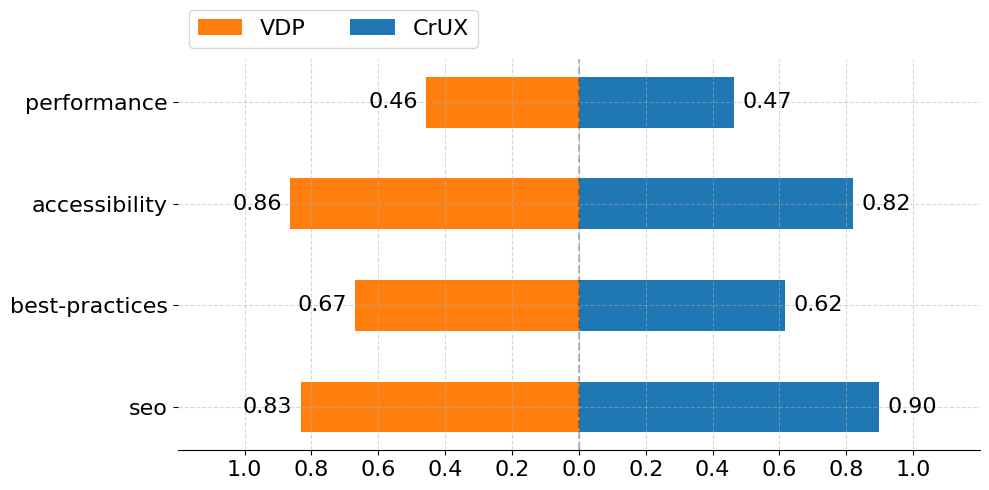

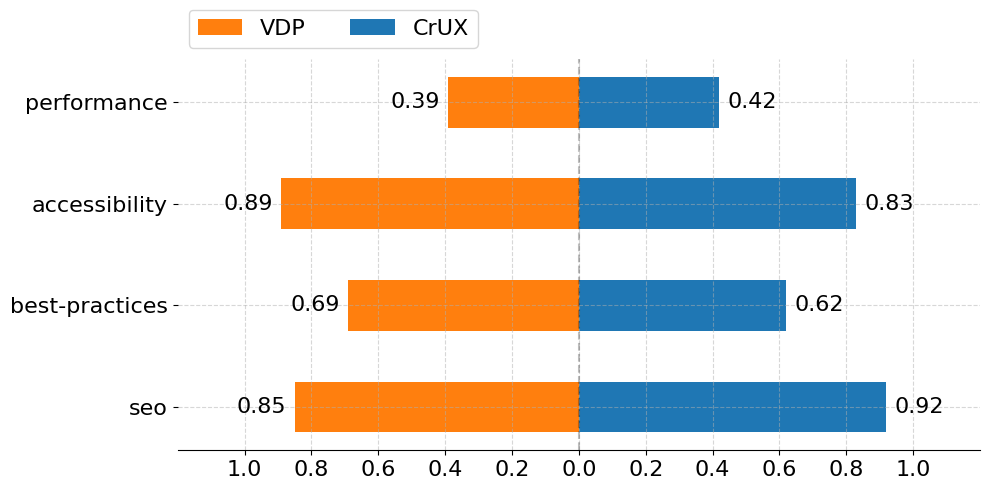

In [48]:
import sqlalchemy
import sqlite3
import json
import pandas as pd
import re
from collections import Counter
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
from urllib.parse import urlparse
import matplotlib.pyplot as plt
from tabulate import tabulate
import statistics



db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
query = "SELECT * FROM urls WHERE lighthouse IS NOT NULL"
conn = sqlite3.connect(db_path)
chunksize = 1500

count_succ = 0
count_fail = 0

lh_data = {
    "performance": [],
    "accessibility": [],
    "best-practices": [],
    "seo": []
}
overall_data = {}

'''
error_counter = Counter()
for df in pd.read_sql_query(query, conn, chunksize=chunksize):
    df['lighthouse_formated'] = df['lighthouse'].apply(json.loads)

    for _, row in df.iterrows():
        if 'error' in row['lighthouse_formated'].keys():
            continue
        
        # print(row['lighthouse_formated']['lighthouse'].keys())
        ## dict_keys(['lighthouseVersion', 'requestedUrl', 'mainDocumentUrl', 'finalDisplayedUrl', 'finalUrl', 'fetchTime', 'gatherMode', 'runWarnings', 'userAgent', 'environment', 'audits', 'configSettings', 'categories', 'categoryGroups', 'stackPacks', 'entities', 'fullPageScreenshot', 'timing', 'i18n'])

        #print(row['lighthouse_formated']['lighthouse']['categories']['performance']['score'])
        lh_data['performance'].append(row['lighthouse_formated']['categories']['performance']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['accessibility']['score'])
        lh_data['accessibility'].append(row['lighthouse_formated']['categories']['accessibility']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['best-practices']['score'])
        lh_data['best-practices'].append(row['lighthouse_formated']['categories']['best-practices']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['seo']['score'])
        lh_data['seo'].append(row['lighthouse_formated']['categories']['seo']['score'])

# Average/median scores
overall_data["Overall"] = {}
print("[*] Scores for Overall:")
for key, values in lh_data.items():
    clean_values = [v for v in values if v is not None]
    if clean_values: 
        average = sum(clean_values) / len(clean_values) 
        median = statistics.median(clean_values)  
        print(f"  [*] {key.capitalize()}:")
        print(f"    - Average: {average:.2f}")
        print(f"    - Median: {median:.2f}")
        overall_data['Overall'][key]= {"average": average, "median": median}
    else:
        print(f"{key.capitalize()}: No data available")
'''
##########################
# BB
db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
query = "SELECT * FROM urls WHERE lighthouse IS NOT NULL and source='BB'"
conn = sqlite3.connect(db_path)
chunksize = 2500

count_succ = 0
count_fail = 0

lh_data = {
    "performance": [],
    "accessibility": [],
    "best-practices": [],
    "seo": []
}

error_counter = Counter()
for df in pd.read_sql_query(query, conn, chunksize=chunksize):
    df['lighthouse_formated'] = df['lighthouse'].apply(json.loads)

    for _, row in df.iterrows():
        if 'error' in row['lighthouse_formated'].keys():
            continue
        
        # print(row['lighthouse_formated']['lighthouse'].keys())
        ## dict_keys(['lighthouseVersion', 'requestedUrl', 'mainDocumentUrl', 'finalDisplayedUrl', 'finalUrl', 'fetchTime', 'gatherMode', 'runWarnings', 'userAgent', 'environment', 'audits', 'configSettings', 'categories', 'categoryGroups', 'stackPacks', 'entities', 'fullPageScreenshot', 'timing', 'i18n'])

        #print(row['lighthouse_formated']['lighthouse']['categories']['performance']['score'])
        lh_data['performance'].append(row['lighthouse_formated']['categories']['performance']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['accessibility']['score'])
        lh_data['accessibility'].append(row['lighthouse_formated']['categories']['accessibility']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['best-practices']['score'])
        lh_data['best-practices'].append(row['lighthouse_formated']['categories']['best-practices']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['seo']['score'])
        lh_data['seo'].append(row['lighthouse_formated']['categories']['seo']['score'])
    break

# Average/median scores
print("[*] Scores for BB:")
overall_data["BB"] = {}
for key, values in lh_data.items():
    clean_values = [v for v in values if v is not None]
    if clean_values: 
        average = sum(clean_values) / len(clean_values) 
        median = statistics.median(clean_values)  
        print(f"  [*] {key.capitalize()}:")
        print(f"    - Average: {average:.2f}")
        print(f"    - Median: {median:.2f}")
        overall_data['BB'][key]= {"average": average, "median": median}
    else:
        print(f"{key.capitalize()}: No data available")


##############################
# CRUX

db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
query = "SELECT * FROM urls WHERE lighthouse IS NOT NULL and source='CRUX'"
conn = sqlite3.connect(db_path)
chunksize = 2500

count_succ = 0
count_fail = 0

lh_data = {
    "performance": [],
    "accessibility": [],
    "best-practices": [],
    "seo": []
}

error_counter = Counter()
for df in pd.read_sql_query(query, conn, chunksize=chunksize):
    df['lighthouse_formated'] = df['lighthouse'].apply(json.loads)

    for _, row in df.iterrows():
        if 'error' in row['lighthouse_formated'].keys():
            continue
        
        # print(row['lighthouse_formated']['lighthouse'].keys())
        ## dict_keys(['lighthouseVersion', 'requestedUrl', 'mainDocumentUrl', 'finalDisplayedUrl', 'finalUrl', 'fetchTime', 'gatherMode', 'runWarnings', 'userAgent', 'environment', 'audits', 'configSettings', 'categories', 'categoryGroups', 'stackPacks', 'entities', 'fullPageScreenshot', 'timing', 'i18n'])

        #print(row['lighthouse_formated']['lighthouse']['categories']['performance']['score'])
        lh_data['performance'].append(row['lighthouse_formated']['categories']['performance']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['accessibility']['score'])
        lh_data['accessibility'].append(row['lighthouse_formated']['categories']['accessibility']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['best-practices']['score'])
        lh_data['best-practices'].append(row['lighthouse_formated']['categories']['best-practices']['score'])
        #print(row['lighthouse_formated']['lighthouse']['categories']['seo']['score'])
        lh_data['seo'].append(row['lighthouse_formated']['categories']['seo']['score'])
    break


# Average/median scores
overall_data["Crux"] = {}
print("[*] Scores for CRUX:")
for key, values in lh_data.items():
    clean_values = [v for v in values if v is not None]
    if clean_values: 
        average = sum(clean_values) / len(clean_values) 
        median = statistics.median(clean_values)  
        print(f"  [*] {key.capitalize()}:")
        print(f"    - Average: {average:.2f}")
        print(f"    - Median: {median:.2f}")
        overall_data['Crux'][key]= {"average": average, "median": median}
    else:
        print(f"{key.capitalize()}: No data available")


#################

categories = list(overall_data.keys())
metrics = list(overall_data["BB"].keys())
print(metrics)

average_scores = {
    metric: [overall_data[cat][metric]["average"] for cat in categories] for metric in metrics
}
median_scores = {
    metric: [overall_data[cat][metric]["median"] for cat in categories] for metric in metrics
}

x = np.arange(len(categories))
group_width = 0.8
bar_width = group_width / (2 * len(metrics))


fig, ax = plt.subplots(figsize=(10, 6))
for i, metric in enumerate(metrics):
    # Adjust positions for average and median bars
    avg_positions = x - group_width / 2 + i * 2 * bar_width
    med_positions = avg_positions + bar_width

    # Plot bars for average and median scores
    ax.bar(avg_positions, average_scores[metric], bar_width, label=f"{metric} (Avg)")
    ax.bar(med_positions, median_scores[metric], bar_width, label=f"{metric} (Med)", alpha=0.5, color=f"C{i+1}")

# Customize the plot
ax.set_title("Scores Across Categories")
ax.set_xlabel("Categories")
ax.set_ylabel("Scores")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Show the plot
plt.tight_layout()
plt.savefig(f'/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/comparison-lighthouse_scores.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Add a table -> maybe better visibility
metrics = list(average_scores.keys())

# Table headers
headers = ["Category", 
           "BB Avg", "CRUX Avg", "Δ Total (Avg)", "Δ % (Avg)", 
           "BB Med", "CRUX Med", "Δ Total (Med)", "Δ % (Med)"]

# Prepare data rows
import numpy as np
from tabulate import tabulate

# Define categories (excluding "Overall" if needed)
categories = [cat for cat in categories if cat != "Overall"]  # Optional: remove "Overall"

# Extract metrics (same for both BB and CRUX)
metrics = list(average_scores.keys())

# Table headers
headers = ["Category", 
           "BB Avg", "CRUX Avg", "Δ Total (Avg)", "Δ % (Avg)", 
           "BB Med", "CRUX Med", "Δ Total (Med)", "Δ % (Med)"]

# Prepare data rows
table_data = []

for metric in metrics:  # Process each metric
    # Extract average values
    bb_avg = overall_data["BB"][metric]["average"]
    crux_avg = overall_data["Crux"][metric]["average"]
    delta_avg_total = bb_avg - crux_avg
    delta_avg_perc = (delta_avg_total / crux_avg) * 100 if crux_avg != 0 else 0

    # Extract median values
    bb_med = overall_data["BB"][metric]["median"]
    crux_med = overall_data["Crux"][metric]["median"]
    delta_med_total = bb_med - crux_med
    delta_med_perc = (delta_med_total / crux_med) * 100 if crux_med != 0 else 0

    # Format row
    row = [f"{metric}", 
            f"{bb_avg:.2f}", f"{crux_avg:.2f}", f"{delta_avg_total:.2f}", f"{delta_avg_perc:.2f}%",
            f"{bb_med:.2f}", f"{crux_med:.2f}", f"{delta_med_total:.2f}", f"{delta_med_perc:.2f}%"]
    
    table_data.append(row)

# Print table
print("\nComparison Table (BB vs CRUX for each category):")
print(tabulate(table_data, headers=headers, tablefmt="github"))

from matplotlib.ticker import FuncFormatter

def create_plot(results, category_names):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*. The order is assumed
        to be from 'Vulnerability Disclosure Programs' to 'CrUX'.
    category_names : list of str
        The category labels.
    """
    
    labels = list(results.keys())  # Extract question labels
    data = np.array(list(results.values()))  # Convert answers into a numpy array
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot Bars for Vulnerability Disclosure Programs (left side, negative)
    ax.barh(labels, -data[:, 0], height=0.5, label=category_names[0], color='C1')
    
    # Plot Bars for CrUX (right side, positive)
    ax.barh(labels, data[:, 1], height=0.5, label=category_names[1], color='C0')
    
    # Add Zero Reference Line
    ax.axvline(0, linestyle='--', color='black', alpha=.25)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # X Axis Configuration
    ax.set_xlim(-1.2, 1.2)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.1f}"))
    ax.set_xticks(np.linspace(-1.0, 1.0, 11))  # -1.0 bis 1.0 in 0.2er Schritten    # Y Axis Configuration
    ax.invert_yaxis()  # Invert y-axis so the topmost label is at the top
    
    # Remove unnecessary spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='x', labelsize=16)  # X-Achse Tick-Größe
    ax.tick_params(axis='y', labelsize=16)
    
    # Add Legend
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
              loc='lower left', title_fontsize=18, fontsize=16)
    
    # Set Background Color
    fig.set_facecolor('#FFFFFF')

    # Add Percentages Before and After the Bars (Floating-point)
    for i, label in enumerate(labels):
        # Calculate the percentage for BB (negative side)
        bb_percentage = data[i, 0]
        crux_percentage = data[i, 1]
        
        # Adding the text before and after the bars with float formatting
        ax.text(-bb_percentage - 0.025, i, f'{bb_percentage:.2f}', va='center', ha='right', fontsize=16, color='black')
        ax.text(crux_percentage + 0.025, i, f'{crux_percentage:.2f}', va='center', ha='left', fontsize=16, color='black')


    return fig, ax


# Ergebnisse berechnen
results_avg = {}
results_med = {}
for metric in metrics:  # Process each metric
    # Extract average values
    bb_avg = overall_data["BB"][metric]["average"]
    crux_avg = overall_data["Crux"][metric]["average"]
    results_avg[metric] = [bb_avg, crux_avg]

    # Extract median values
    bb_med = overall_data["BB"][metric]["median"]
    crux_med = overall_data["Crux"][metric]["median"]
    results_med[metric] = [bb_med, crux_med]

    
    table_data.append(row)

categories = ['VDP', 'CrUX']
fig, ax = create_plot(results_avg, categories)
#plt.title("Average Scores for Categories")
plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/lighthouse_cats_average.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig, ax = create_plot(results_med, categories)
#plt.title("Median Scores for Categories")
plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/lighthouse_cats_median.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [15]:
# Single audits of interest

import sqlalchemy
import sqlite3
import json
import pandas as pd
import re
from collections import Counter, defaultdict
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
from urllib.parse import urlparse
import matplotlib.pyplot as plt
from tabulate import tabulate
import statistics
import tldextract

# row['lighthouse_formated']['audits']['is-on-https']
# row['lighthouse_formated']['audits']['redirects-http']
# row['lighthouse_formated']['audits']['errors-in-console']
# row['lighthouse_formated']['audits']['critical-request-chains']
# row['lighthouse_formated']['audits']['redirects] # -> dont redirect multiple times (slow)
# row['lighthouse_formated']['audits']['deprecations'] # -> deprecated APIs in browsers
# row['lighthouse_formated']['audits']['third-party-cookies'] # -> No 3rd party cookies
# row['lighthouse_formated']['audits']['network-requests'] # -> all loaded content vie network
# row['lighthouse_formated']['audits']['third-party-summary'] # -> simply try to minimize
#row['lighthouse_formated']['audits']['third-party-facades']
#row['lighthouse_formated']['audits']['csp-xss']
#row['lighthouse_formated']['audits']['unused-javascript'] #-> why include then
#row['lighthouse_formated']['audits']['duplicated-javascript'] # -> remove duplicates modules in JS bundles
#row['lighthouse_formated']['audits']['legacy-javascript'] # avoid legacy JS
#row['lighthouse_formated']['audits']['no-document-write'] # slow and security dangerous
#row['lighthouse_formated']['audits']['js-libraries'] # all detected js libraries
#row['lighthouse_formated']['audits']['uses-http2']



def check_audits(source):
    db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
    query = f"SELECT * FROM urls WHERE lighthouse IS NOT NULL and source='{source}'"
    conn = sqlite3.connect(db_path)
    chunksize = 2500

    count_succ = 0
    count_fail = 0
    domain_set = set()
    deprecations_domains = defaultdict(set)
    deprecations_domains_overall = set()
    deprecations_websites = defaultdict(set)

    docwrite_domains_overall = set()
    overall_domains = set()

    error_counter = Counter()
    for df in pd.read_sql_query(query, conn, chunksize=chunksize):
        df['lighthouse_formated'] = df['lighthouse'].apply(json.loads)

        for _, row in df.iterrows():
            extract = tldextract.extract(row['url'])
            domain = f'{extract.domain}.{extract.suffix}'
            overall_domains.add(domain)
            if 'error' in row['lighthouse_formated'].keys():
                continue
            else:
                deprecations = row.get('lighthouse_formated', {}).get('audits', {}).get('deprecations', {})
                if deprecations.get('score') == 0 and 'details' in deprecations:
                    for item in deprecations['details'].get('items', []):
                        deprecations_domains[item['value']].add(domain)
                        deprecations_websites[item['value']].add(row['url'])
                        deprecations_domains_overall.add(domain)
                
                docwrite = row.get('lighthouse_formated', {}).get('audits', {}).get('no-document-write', {})
                if docwrite.get('score') != 1:
                    docwrite_domains_overall.add(domain)


    print(f'Overall {len(docwrite_domains_overall)} ({len(docwrite_domains_overall)/len(overall_domains) * 100}) domains use a document.write() ')

    print(f'Overall {len(deprecations_domains_overall)} ({len(deprecations_domains_overall)/len(overall_domains) * 100}) domains use a deprecated API ')

    for x, y in sorted(deprecations_domains.items(), key=lambda item: len(item[1]), reverse=True):
        print(f"- {x} - Found in {len(y)} ({len(y) / len(overall_domains) * 100:.2f}%) domains")

print("===========BB============")
check_audits("BB")

print("===========CRUX============")
check_audits("CRUX")

===========BB============
Overall 171 (9.12486659551761) domains use a document.write() 
Overall 585 (31.21664887940235) domains use a deprecated API 
- UnloadHandler - Found in 422 (22.52%) domains
- `StorageType.persistent` is deprecated. Please use standardized `navigator.storage` instead. - Found in 115 (6.14%) domains
- Synchronous `XMLHttpRequest` on the main thread is deprecated because of its detrimental effects to the end user's experience. For more help, check https://xhr.spec.whatwg.org/. - Found in 83 (4.43%) domains
- Specifying `overflow: visible` on img, video and canvas tags may cause them to produce visual content outside of the element bounds. See https://github.com/WICG/shared-element-transitions/blob/main/debugging_overflow_on_images.md. - Found in 35 (1.87%) domains
- `<source src>` with a `<picture>` parent is invalid and therefore ignored. Please use `<source srcset>` instead. - Found in 10 (0.53%) domains
- CSSCustomStateDeprecatedSyntax - Found in 8 (0.43%) dom

## Results - Basic Cross-Site-Scripting

# Other

In [ ]:
import json
from collections import defaultdict

overall_matching_cats_oos = {}
with open(f"/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_os_final_dict.json", "r") as file:
    overall_matching_cats_oos = json.load(file)


# iterate through everything and look for specific keywords..
new_list = defaultdict(set)
for key, data in overall_matching_cats_oos.items():
    for entry in data:
        if "csrf" in entry:
            print(f'{entry} - {key}')
            new_list[key].add(str(entry))


for key, entries in new_list.items():
    print(f"-------{key}-------")
    new_list = [f"{text}" for text in entries]
    print(new_list)

csrf - Uncategorized
low/no impact csrf attacks. - Uncategorized
unauthenticated / logout / login and other low-severity csrf - minor issues with limited security implications. - Uncategorized
social-engineering attacks (csrf, xss) - Social Engineering
logout csrf - Misc
forced login/logout csrf - Misc
login/logout csrf/xsrf - Misc
logout csrf (unless chained to show an impactful exploit) - Misc
csrf: cross-site request forgery on unauthenticated forms. - Misc
logout and low-severity csrf instances - Misc
low impact csrf - cross-site request forgery with minimal or no potential impact is not considered. - Misc
low impact or low-severity cross-site request forgery (csrf) attacks - Misc
csrf attacks: unauthenticated/logout/login csrf vulnerabilities. - csrf
low-severity csrf issues - non-critical exploitation attempts. - csrf
csrf with minimal impact - csrf
csrf without impact - csrf
csrf: cross-site request forgery attacks on unauthenticated forms or those with no sensitive actions. - c

In [ ]:
import json
from collections import defaultdict

# Load the original file
with open("/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_is_final_dict.json", "r") as file:
    overall_matching_cats_oos = json.load(file)

# Convert lists to sets for easier manipulation
for key in overall_matching_cats_oos:
    overall_matching_cats_oos[key] = set(overall_matching_cats_oos[key])

# Define keywords and their correct categories
keyword_to_target_category = {
    "csrf": "CSRF",
    "third-party": "Vulnerable Components",
    "outdated": "Vulnerable Components",
    "clickjacking": "Clickjacking",
    "tabnabbing": "Tabnabbing",
    "mitm": "MitM",
    "physical": "Physical Access Needed",
    "disclosure": "Information Disclosure",
    "exposed": "Information Disclosure",
    "leaked": "Information Disclosure",
    "leakage": "Information Disclosure",
    "unauthorized access": "Information Disclosure",
    "exposure": "Information Disclosure",
    "accessing": "Access Control",
    "enumeration": "Information Disclosure",
    "content": "Content Spoofing/Injection",
    "csv injection": "CSV Injection",
    "rate limit": "Automated Vulnerabilities",
    "disrupt": "Automated Vulnerabilities",
    "automated": "Automated Vulnerabilities",
    "redirect": "Redirects",
    "zero-day": "Zero-Day",
    "0-day": "Zero-Day",
    "best practices": "Security Best Practices",
    "ssrf": "SSRF",
    "low impact": "Low Impact Vulnearbilties",
    "misconfig": "Configuration Issues",
    "missing": "Configuration Issues",
    "subdomain takeover": "Subdomain Takeover",
    "theoretical": "Theoretical Issues",
    "xss": "XSS",
    "phishing": "Phishing",
    "file upload": "File Upload Vulnerabilities",
    "code execution": "RCE",
    "rate-limiting": "DoS",
    "dos": "DoS",
    "ddos": "DoS",
    "denial of service": "DoS",
    "xml external": "XXE",
    "xxe": "XXE",
    "authentication": "Authentication",
    "login":  "Authentication",
    "access": "Access Control"
}

# Step 1: Find and collect matching entries for each keyword
moved_entries = defaultdict(set)
for keyword, target_category in keyword_to_target_category.items():
    for key, entries in overall_matching_cats_oos.items():
        for entry in list(entries):
            if keyword in entry.lower() and key.lower() != target_category.lower():
                entries.remove(entry)
                moved_entries[target_category].add(entry)
            elif keyword in entry.lower() and key.lower() == target_category.lower():
                moved_entries[target_category].add(entry)

# Step 2: Assign collected entries to their correct category
for category, entries in moved_entries.items():
    if category not in overall_matching_cats_oos:
        overall_matching_cats_oos[category] = set()
    overall_matching_cats_oos[category].update(entries)

uncategorized = ["Misc", "Vulnerabilities", "Miscellaneous Issues", "Uncategorized"]
uncategorized_entries = []
for key, entries in overall_matching_cats_oos.items():
    if key in uncategorized:
        uncategorized_entries.extend(entries)


overall_matching_cats_oos["Uncategorized"] = uncategorized_entries
final_output = {k: sorted(list(v)) for k, v in overall_matching_cats_oos.items()}

# Step 4: Save cleaned JSON
with open("/home/Redacted_author/MasterThesis/code/data/extractor/vulnTypesSummarized_is_final_dict_cleaned.json", "w") as out_file:
    json.dump(final_output, out_file, indent=2)


print(list(final_output.keys()))

['RCE', 'Access Control', 'Others', 'XSS', 'ThirdPartyVulns', 'Data Leakage', 'SQLi', 'API Vulnerabilities', 'File Inclusion/Uploads', 'DoS', 'Privilege Escalation', 'CSRF', 'Data Leaks', 'Information Disclosure', 'Tampering', 'Injection', 'Subdomain Takeover', 'Server-Side Vulnerabilities', 'File Read', 'null', 'CORS', 'Business Logic', 'Open Redirect', 'Path Traversal', 'Account Takeover', 'Exploit Techniques', 'Cryptography', 'Email Injection', 'IoT Vulnerabilities', 'Network Privacy', 'PrivEsc', 'Vulnerable Components', 'Clickjacking', 'Content Spoofing/Injection', 'CSV Injection', 'Automated Vulnerabilities', 'Redirects', 'Zero-Day', 'SSRF', 'Low Impact Vulnearbilties', 'Configuration Issues', 'Theoretical Issues', 'File Upload Vulnerabilities', 'XXE', 'Authentication', 'Uncategorized']


In [3]:
import sqlite3
import pandas as pd
import random

db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
source = "BB"
query = f"SELECT * FROM urls WHERE source='{source}'"
conn = sqlite3.connect(db_path)
chunksize = 2500

# --- 1. Base-Webpages extrahieren ---
base_webpages = set()
for df in pd.read_sql_query(query, conn, chunksize=chunksize):
    df = df[df['base'] == 1]
    base_webpages |= set(df['url'])

# --- 2. Alle Referenzen als base_url (von Subpages) sammeln ---
used_as_base = set()
for df in pd.read_sql_query(query, conn, chunksize=chunksize):
    df = df[df['base'] == 0]
    used_as_base |= set(df['base_url'])

# --- 3. Aufteilen ---
with_subpages = list(base_webpages & used_as_base)
without_subpages = list(base_webpages - used_as_base)

# --- 4. Zufällige Auswahl ---
sample_with = random.sample(with_subpages, min(25, len(with_subpages)))
sample_without = random.sample(without_subpages, min(25, len(without_subpages)))

# --- 5. Ausgabe ---
print("\n🔗 25 Base-URLs MIT Subpages:")
for url in sample_with:
    print(f" - {url}")

print("\n🧩 25 Base-URLs OHNE Subpages:")
for url in sample_without:
    print(f" - {url}")



🔗 25 Base-URLs MIT Subpages:
 - http://www.perf.xfinity.com
 - http://jira.omgeving.vlaanderen.be
 - http://business.linkedin.com
 - http://www.compass.com
 - http://www.lansweeper.com
 - http://myroyalcanin.bg
 - http://login.teamviewer.com
 - http://www.visa.co.th
 - http://equatorialguinea-evisa.com
 - http://tco16.topcoder.com
 - http://www.vidaxl.at
 - http://decodefintech.com
 - http://fulfillment.wolt.com
 - http://community.companyofheroes.com
 - http://bitsociety.bitdefender.com
 - http://partnerhelp.viator.com
 - http://securitytxt.org
 - http://cloud.gov
 - http://www.vidaxl.ro
 - http://responds.xfinity.com
 - http://citymesh.recruitee.com
 - http://www.digitalocean.com
 - http://www.cheaptickets.com
 - http://myroyalcanin.hu
 - http://partner.tiktokshop.com

🧩 25 Base-URLs OHNE Subpages:
 - http://fallguys.com
 - http://hilolife.com
 - http://tikkie.me
 - http://venture.innv.apps.northwesternmutual.com
 - http://splus-dock2.pnimedia.com
 - http://gis.water-link.be
 - http